In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import scipy
import seaborn as sns
import sklearn
import pysindy as ps 
from sklearn.linear_model import Lasso
import sys
from pathlib import Path

REPO_ROOT = None
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / 'tools' / 'tools.py').exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError('Could not locate repository root containing tools/tools.py')
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from IPython.display import display

from tools.tools import (
    get_positive_contributions,
    compute_entropy,
    print_equations,
)
import warnings
from sklearn.exceptions import ConvergenceWarning
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, fixed
import ipywidgets as widgets
# 仅忽略收敛警告
warnings.filterwarnings("ignore", category=ConvergenceWarning)
from sympy import symbols, Matrix, sqrt, simplify, solve, Eq, Abs, expand
from matplotlib.colors import hsv_to_rgb

from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap
from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path
import matplotlib.patches as patches

# 解析动力学分析示例

这个 notebook 按照同一个动力学系统的四种分析视角重新组织为四个部分：

1. 研究模型参数变化时奇异值如何变化。
2. 假设解析 Koopman 矩阵 $K$ 已知，直接进行 SVD 和粗粒化。
3. 先生成时间序列数据，再从数据中拟合近似的 $K$，随后进行 SVD 和粗粒化。
4. 对比奇异值和特征值，并说明它们各自的分析作用。

现在的结构尽量保持“解释块在前，代码块在后”，方便阅读、复现和后续扩展。


## 1. 参数实验：观察参数变化对奇异值的影响

这一部分直接使用动力学系统对应的解析矩阵，考察当 $\lambda$ 和 $\mu$ 变化时，奇异值谱会如何变化。

主要关注下面几个问题：
- 某些参数范围内，奇异值是否会出现明显分离。
- 哪些参数设置更有利于低维粗粒化。
- 当比值 $\lambda / \mu$ 改变时，主导尺度是否会发生变化。

由于这里不涉及数据拟合，所以这一部分主要是在分析系统本身的谱结构。


In [2]:
# 推导奇异值的解析表达式
lambda_, mu = symbols('lambda mu', real=True)

A = Matrix([
    [lambda_, 0, 0],
    [0, mu, lambda_**2 - mu],
    [0, 0, lambda_**2]
])

A_T_A = A.T * A
Eig_vals = A_T_A.eigenvals(multiple=True)
Eig_vals = [simplify(val) for val in Eig_vals]

sv = [sqrt(val) for val in Eig_vals]
sv = [simplify(v) for v in sv]
print("奇异值的解析表达式：")
for i, s in enumerate(sv, 1):
    print(f"sigma_{i} = {s}")


奇异值的解析表达式：
sigma_1 = Abs(lambda)
sigma_2 = sqrt(lambda**4 - lambda**2*mu + mu**2 + (lambda**2 - mu)*sqrt(lambda**4 + mu**2))
sigma_3 = sqrt(lambda**4 - lambda**2*mu + mu**2 - (lambda**2 - mu)*sqrt(lambda**4 + mu**2))


In [3]:
def compute_singular_values(lam, miu):
    """
    计算给定λ和μ时的奇异值
    """
    A = np.array([
        [lam, 0, 0],
        [0, miu, lam**2 - miu],
        [0, 0, lam**2]
    ])
    sv = np.linalg.svd(A, compute_uv=False)  
    sv = np.sort(sv)[::-1]
    return sv[0], sv[1], sv[2], A

In [4]:
def generate_data_and_analyze(lam_values=None, log_min=-4, log_max=4, n_points=200):
    """
    使用lam:mu比值作为横轴
    """
    if lam_values is None:
        # 默认使用10个λ值，覆盖小、中、大值
        lam_values = [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0]

    print(f"λ值列表: {lam_values}")
    print(f"lam:mu比值范围: [10^{log_min}, 10^{log_max}]")
    print(f"采样点数: {n_points}")

    # 生成 lam:mu 比值（对数均匀分布）
    log_ratios = np.linspace(log_min, log_max, n_points)
    ratios = 10 ** log_ratios

    results = {}
    for lam in lam_values:
        results[lam] = {
            'ratios': ratios,           # lam:mu比值
            'sv1': [],                  # 最大奇异值
            'sv2': [],                  # 中间奇异值
            'sv3': [],                  # 最小奇异值
            'sv_diffs': [],             # 奇异值差异
            'entropy': []               # 奇异值熵
        }

        for ratio in ratios:
            miu = lam / ratio  # lam:mu = ratio:1
            
            sv1, sv2, sv3,_ = compute_singular_values(lam, miu)
            
            results[lam]['sv1'].append(sv1)
            results[lam]['sv2'].append(sv2)
            results[lam]['sv3'].append(sv3)
            results[lam]['sv_diffs'].append([sv1 - sv2, sv2 - sv3, sv3 - 0])

    return results, lam_values, ratios

In [5]:
def plot_singular_values_boxplot(results, lam_values, ratios):
    """
    为奇异值生成科研风格的箱型图。

    参数:
    results: generate_data_and_analyze 函数返回的字典
    lam_values: 使用的 lambda 值列表
    ratios: 使用的 lam:mu 比例列表
    """

    # --- 1. 数据重构 (Data Reshaping) ---
    # 为了使用 seaborn，我们需要将嵌套字典转换为“长格式”数据框 (Tidy Data)
    data_list = []

    for lam in lam_values:
        res = results[lam]
        for i, ratio in enumerate(ratios):
            # 将三个奇异值分别作为独立条目放入列表
            data_list.append(
                {'Ratio': f"$10^{{{np.log10(ratio):.0f}}}$", 'Singular Value': res['sv1'][i], 'Type': '$\sigma_1$'})
            data_list.append(
                {'Ratio': f"$10^{{{np.log10(ratio):.0f}}}$", 'Singular Value': res['sv2'][i], 'Type': '$\sigma_2$'})
            data_list.append(
                {'Ratio': f"$10^{{{np.log10(ratio):.0f}}}$", 'Singular Value': res['sv3'][i], 'Type': '$\sigma_3$'})

    df = pd.DataFrame(data_list)

    # --- 2. 绘图设置 (Styling) ---
    # 设置绘图风格：白底、带刻度线
    sns.set_style("ticks")
    plt.figure(figsize=(7, 6), dpi=600)

    # 使用科研常用的调色板 (例如 'Set2' 或 'colorblind')
    palette = sns.color_palette("Set2")[:3]

    # --- 3. 绘制箱型图 ---
    # x轴是比例，y轴是奇异值，hue按照奇异值顺序分组
    ax = sns.boxplot(
        data=df,
        x='Ratio',
        y='Singular Value',
        hue='Type',
        palette=palette,
        width=0.8, 
        gap=0, 
        linewidth=1.2,
        fliersize=4,
        whis=1.5
    )

    # --- 4. 细节微调 (Refinement) ---
    # 设置标题和标签，指定字体大小
    #plt.title('Distribution of Singular Values across $\lambda/\mu$ Ratios', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('$\lambda/\mu$ Ratio', fontsize=18)
    plt.ylabel('Singular Value Magnitude', fontsize=18)

    # 设置坐标轴刻度字体大小
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)

    # 优化图例：放置在合适位置并去边框
    plt.legend(title='Singular Value', title_fontsize='18', fontsize='18', frameon=True, loc='upper right',framealpha=0.5)

    plt.yscale('log')
    # 自动调整布局防止重叠
    plt.tight_layout()

    # 展示图片
    plt.show()


λ值列表: [0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]
lam:mu比值范围: [10^-4, 10^4]
采样点数: 10


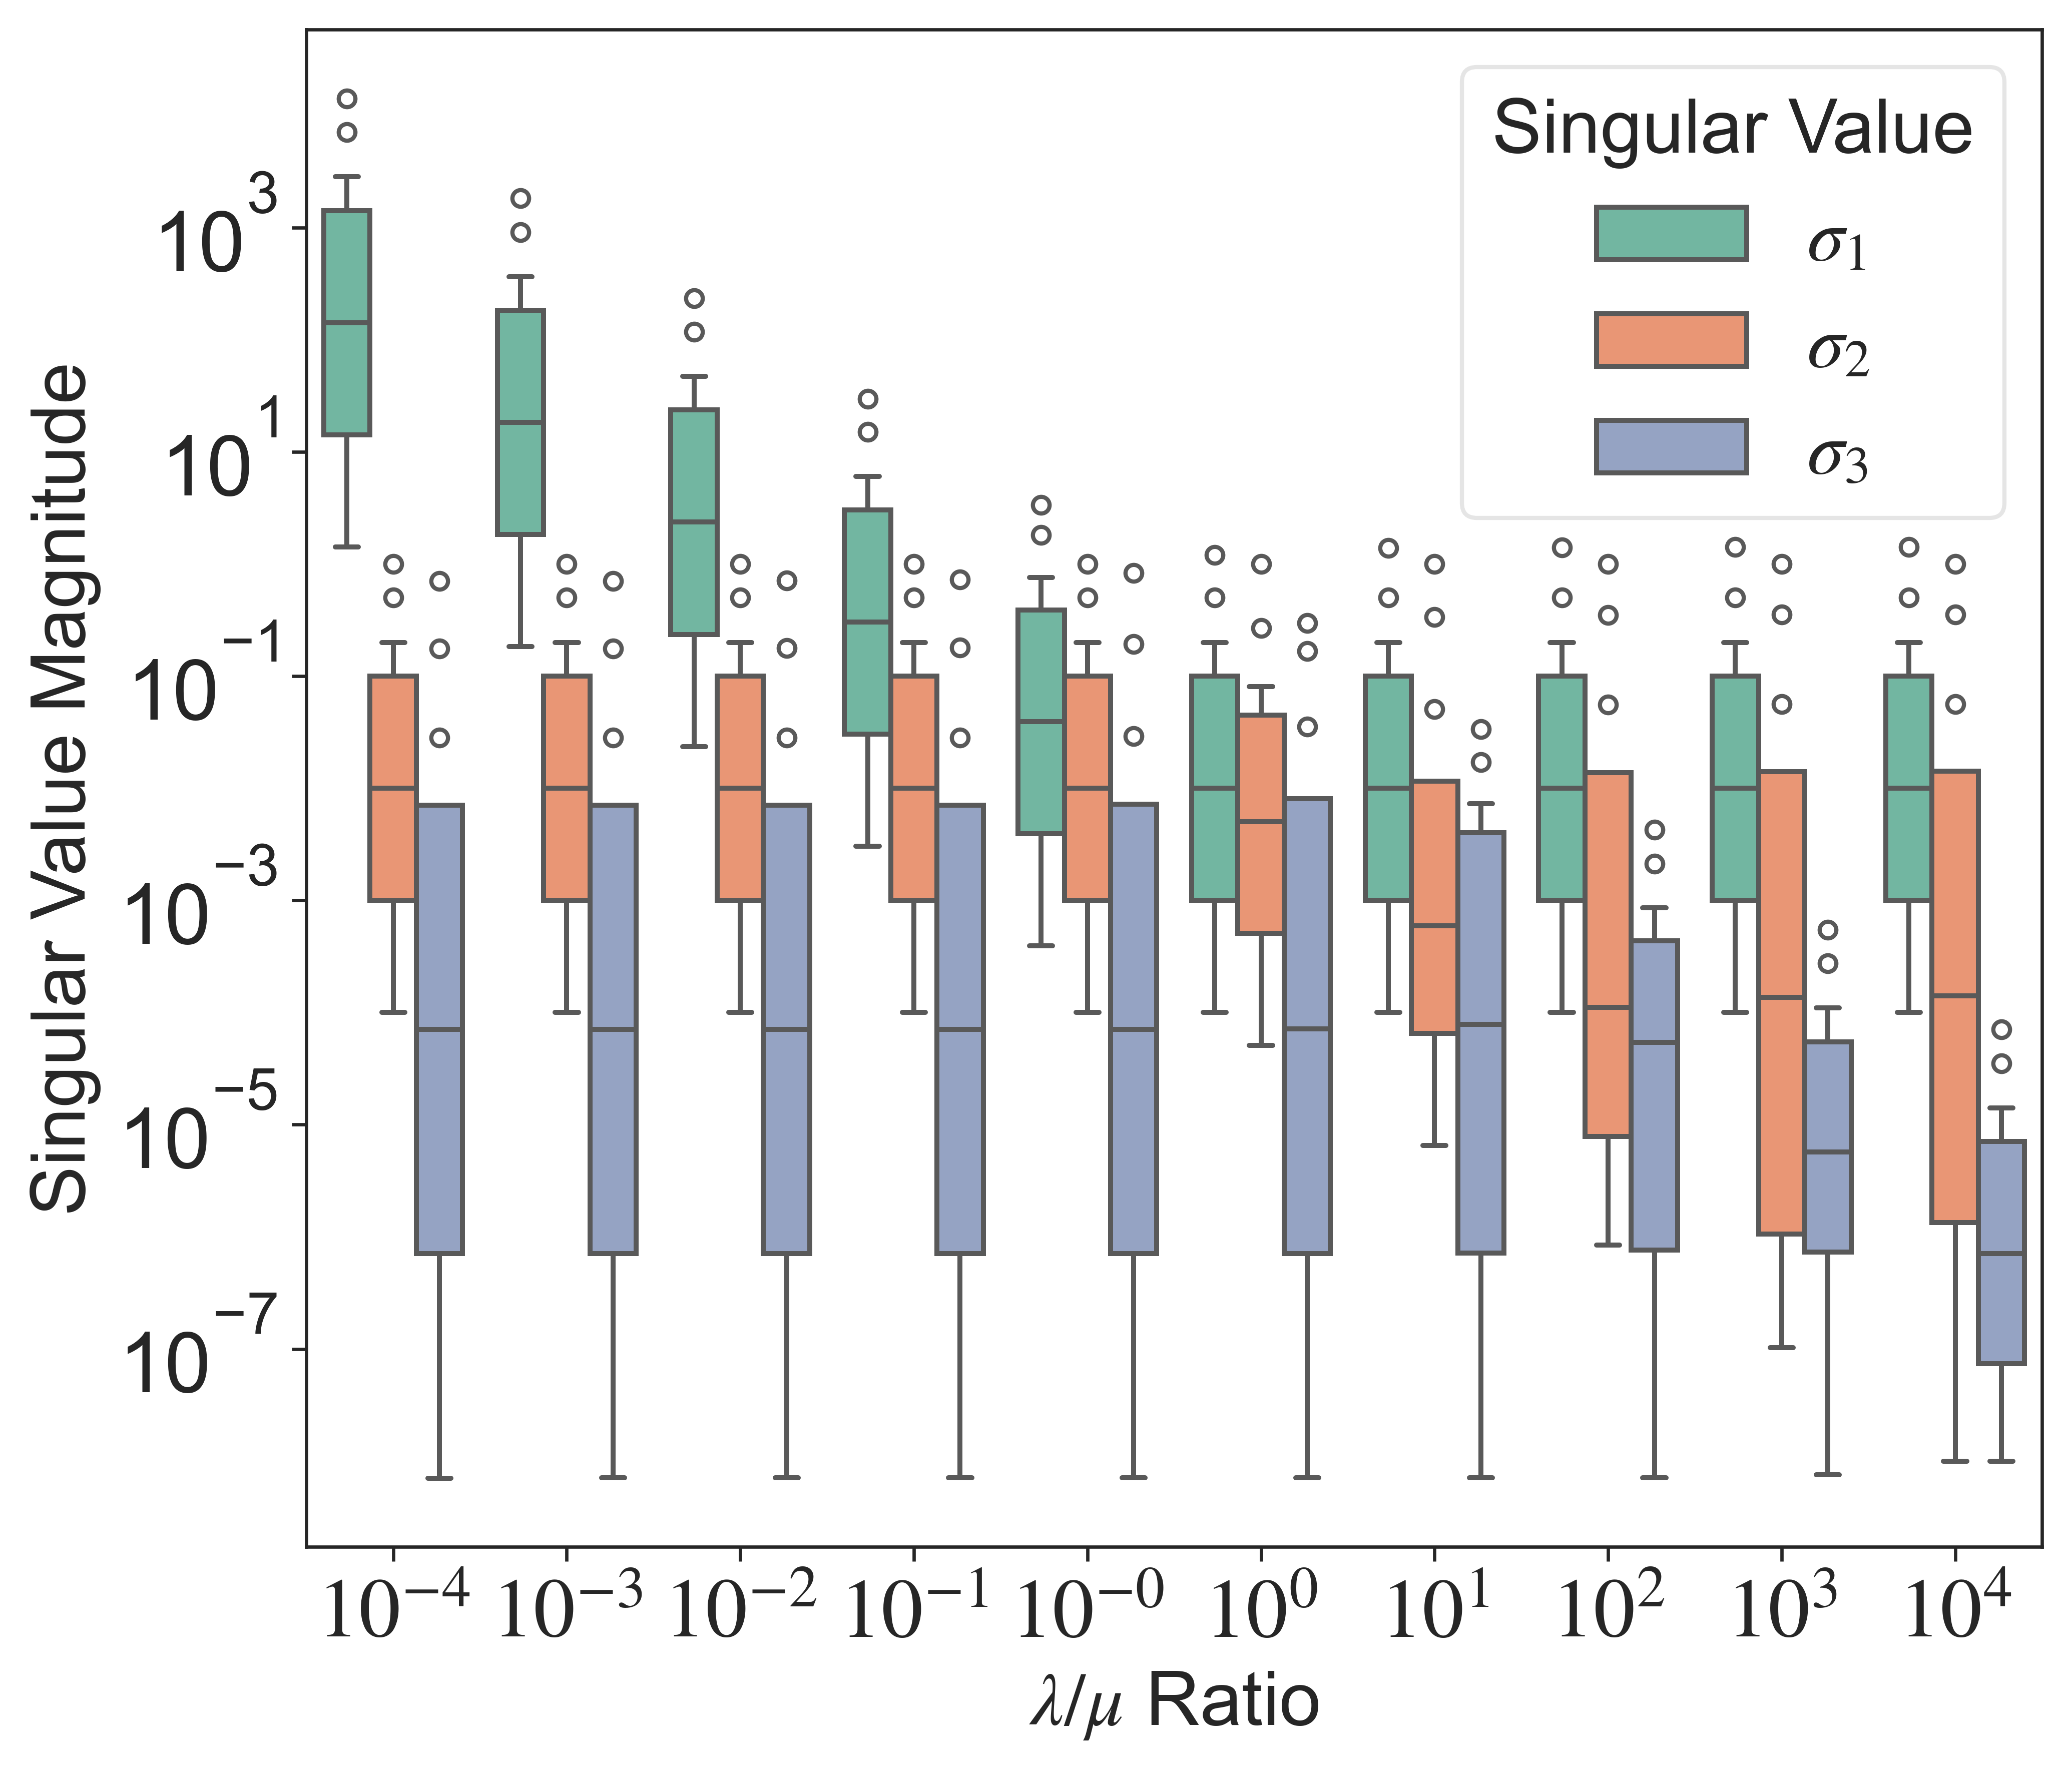

In [6]:
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
results, lam_values, ratios = generate_data_and_analyze(lam_values=[0.0001,0.0002,0.0005,0.001,0.002,0.005,0.01,0.02,0.05,0.1,0.2,0.5,1], 
                                                          log_min=-4, log_max=4, n_points=10)
plot_singular_values_boxplot(results, lam_values, ratios)

## 2. 已知解析 $K$：直接做 SVD 与粗粒化

这一部分假设 lifted 空间中的线性演化矩阵已经可以解析写出，因此不需要先做数据拟合。

整体步骤是：
- 固定参数并构造解析矩阵 $K$。
- 对 $K$ 做奇异值分解，判断是否适合做低秩截断。
- 用左奇异向量构造粗粒化变量。
- 将系统投影到宏观变量上，恢复宏观动力学方程。

这样可以直接把谱结构与粗粒化表达式联系起来。


In [7]:
def step(x, y, lam, mu):
    """计算下一步的x和y值"""
    x_next = lam * x
    y_next = mu * y + (lam**2 - mu) * x**2
    return x_next, y_next

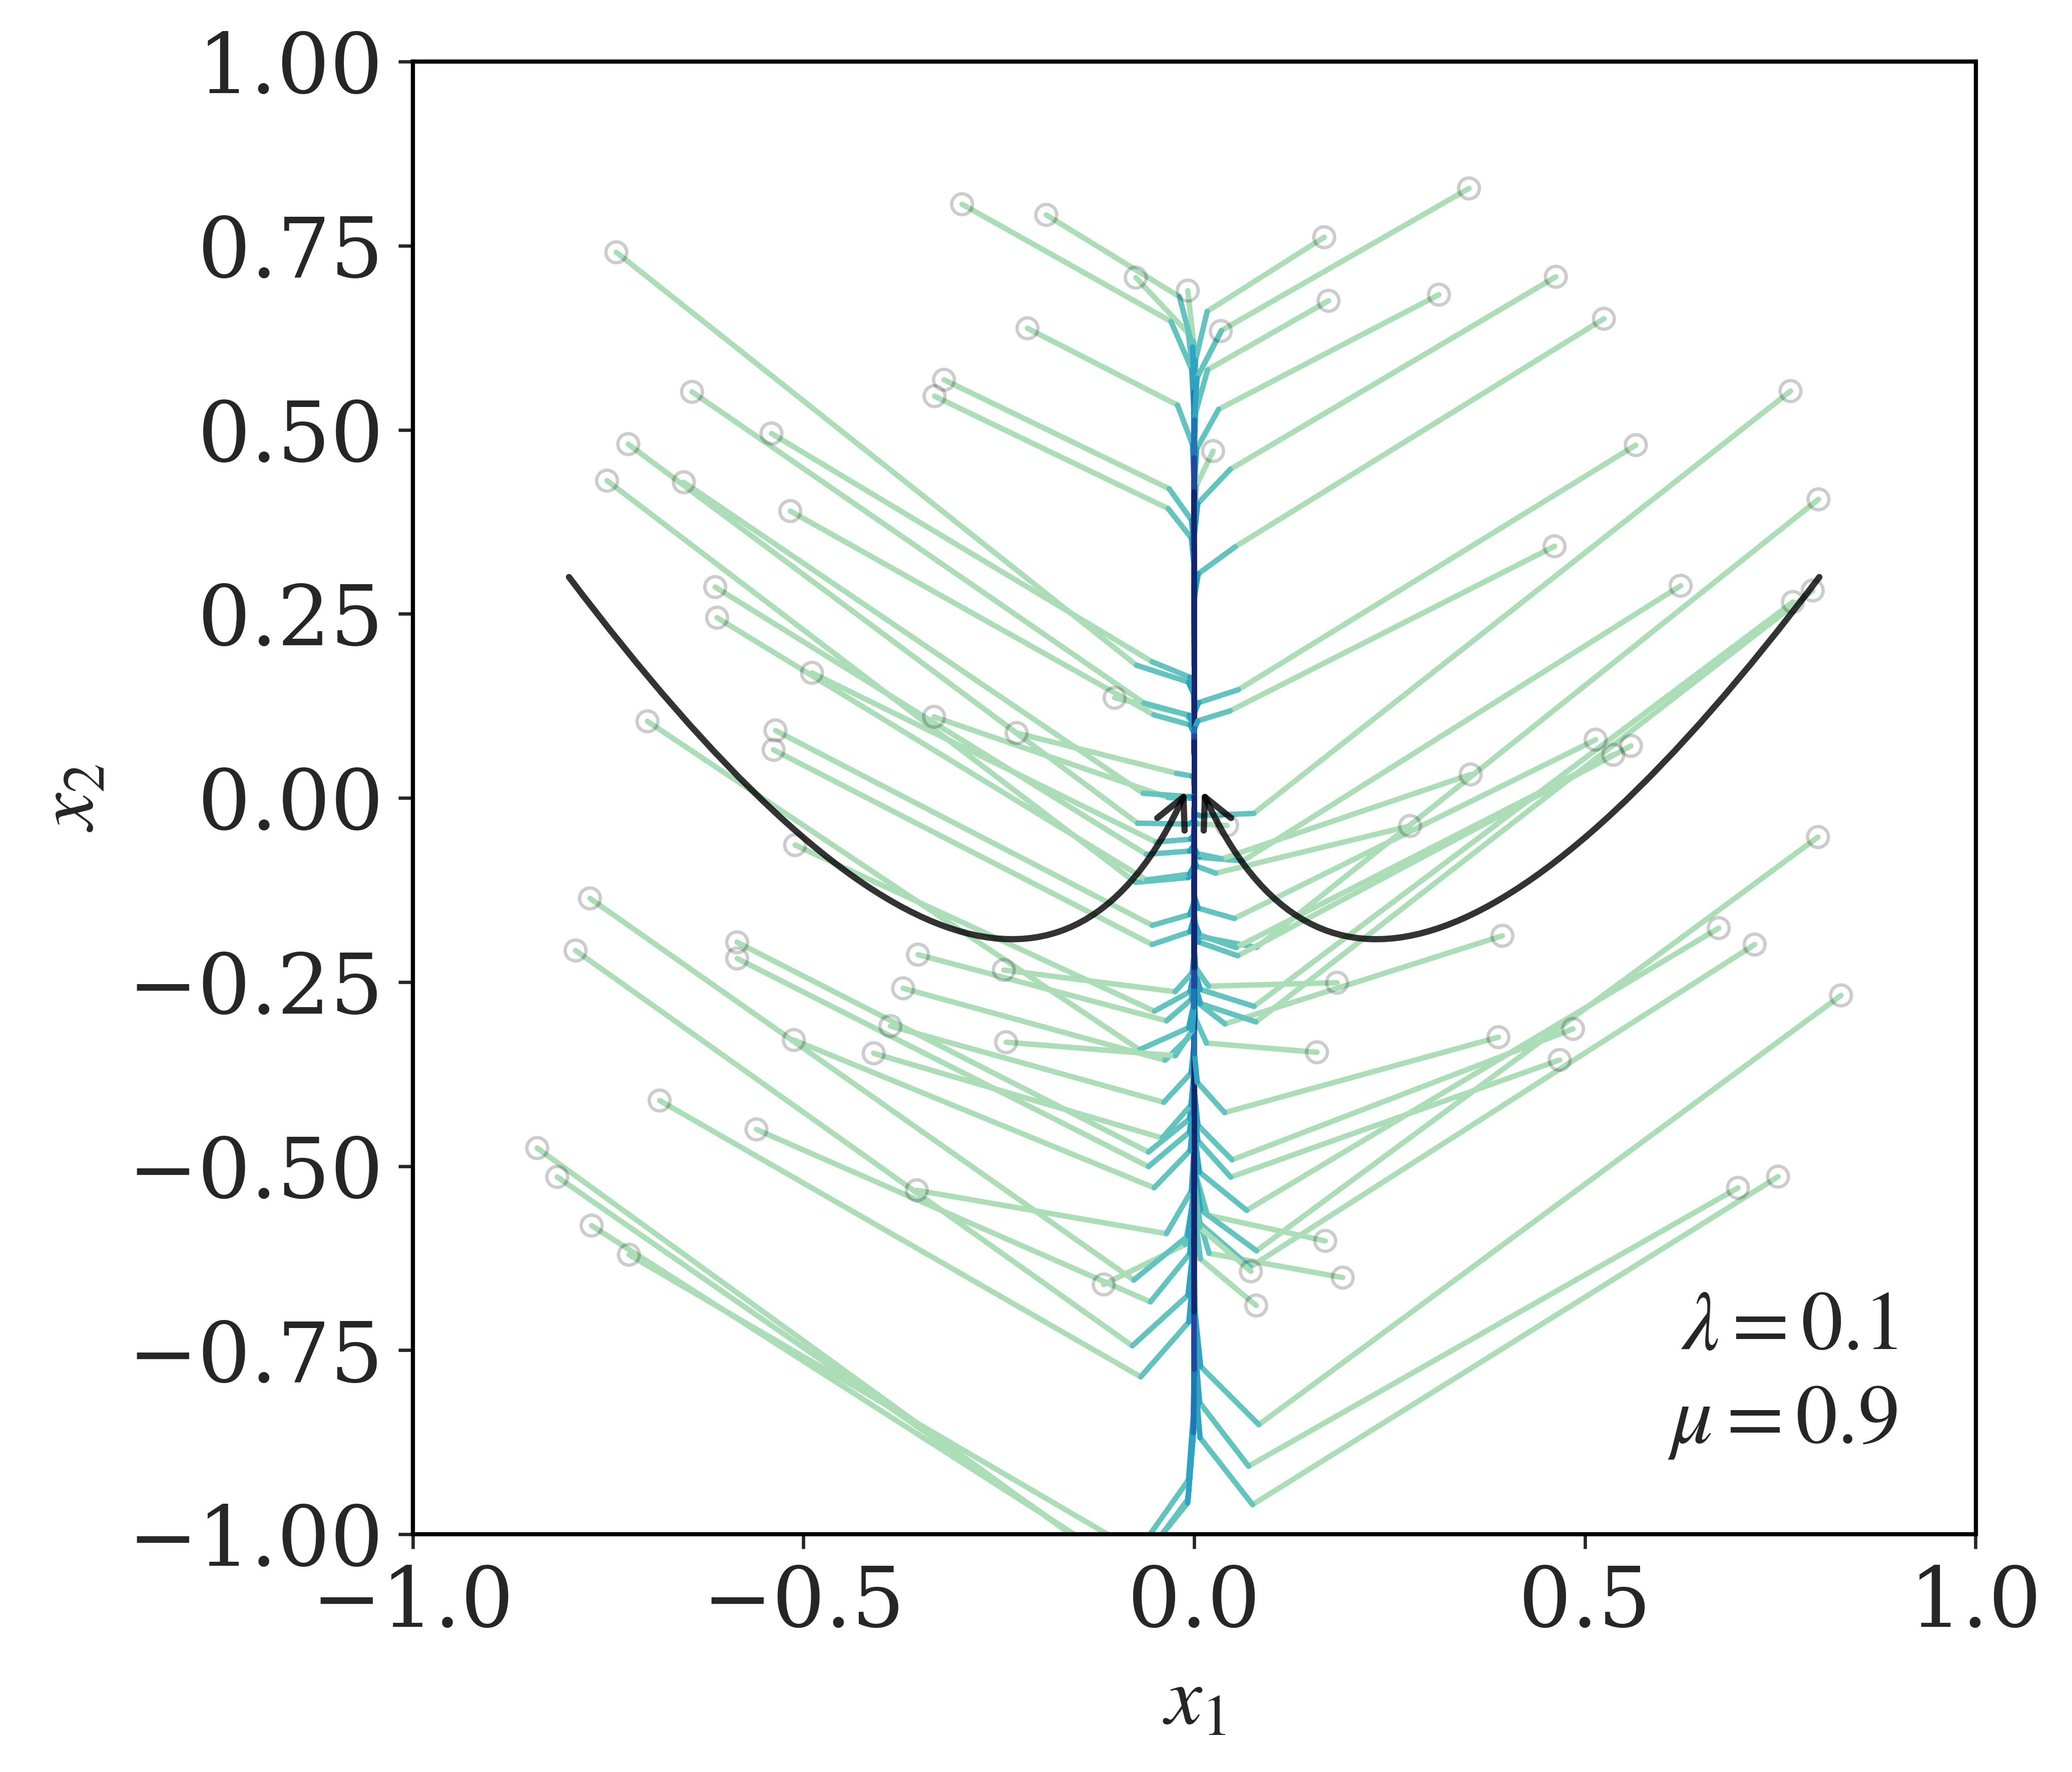

In [8]:
# --- 参数设置 ---
lam, mu = 0.1, 0.9
iterations = 35
num_samples = 80

np.random.seed(42)
x1_init = np.random.uniform(-0.85, 0.85, num_samples)
x2_init = np.random.uniform(-0.7, 0.85, num_samples)
initial_points = np.vstack([x1_init, x2_init]).T

# --- 绘图配置 ---
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(7, 6), dpi=600)

full_cmap = plt.cm.YlGnBu
colors = full_cmap(np.linspace(0.3, 0.95, 6))
custom_cmap = ListedColormap(colors)

for x0, y0 in initial_points:
    xs, ys = [x0], [y0]
    curr_x, curr_y = x0, y0
    for _ in range(iterations):
        curr_x, curr_y = step(curr_x, curr_y, lam, mu)
        xs.append(curr_x)
        ys.append(curr_y)

    points = np.array([xs, ys]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    color_indices = np.arange(len(segments))
    color_indices[5:] = 5

    lc = LineCollection(segments, cmap=custom_cmap)
    lc.set_array(color_indices)
    lc.set_linewidth(1.3) # 稍微调细一点，配合增加的点数
    lc.set_capstyle('round')
    lc.set_alpha(1.0)
    ax.add_collection(lc)

    ax.scatter(x0, y0, s=25, facecolors='none',
               edgecolors=(0, 0, 0, 0.2),
               linewidth=0.8, zorder=5)

# arrow_props 定义基础样式
arrow_props = dict(arrowstyle='->', mutation_scale=18, color='black', lw=1.5, alpha=0.8, zorder=10)

def get_curved_arrow(start, control, end):
    """
    使用二次贝塞尔曲线创建路径
    start: 起点 (x, y)
    control: 控制点 (x, y) - 曲线会向这个点弯曲，但不会直接穿过它，而是受其引力影响
    end: 终点 (x, y)
    """
    verts = [start, control, end]
    codes = [Path.MOVETO, Path.CURVE3, Path.CURVE3]
    return FancyArrowPatch(path=Path(verts, codes), **arrow_props)

arrow_right = get_curved_arrow((0.8, 0.3), (0.23, -0.5), (0.01, 0.01))
arrow_left = get_curved_arrow((-0.8, 0.3), (-0.23, -0.5), (-0.01, 0.01))

ax.add_patch(arrow_left)
ax.add_patch(arrow_right)

# --- 布局与标注 ---
#ax.set_title(f'Phase Portrait (Samples: {num_samples}, Iterations: {iterations})',fontsize=16 , fontweight='bold', pad=15)

info_text = f'$\lambda = {lam}$\n$\mu = {mu}$'
ax.text(0.95, 0.05, info_text, transform=ax.transAxes,
        fontsize=20, fontweight='bold', verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none'))

ax.set_xlabel('$x_1$', fontsize=20, fontweight='bold')
ax.set_ylabel('$x_2$', fontsize=20, fontweight='bold')
ax.tick_params(axis='both', labelsize=20)
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)

ax.grid(False)
plt.tight_layout()
plt.show()

In [9]:
_,_,_,A = compute_singular_values(0.1, 0.9)

In [10]:
cmap = plt.cm.Blues

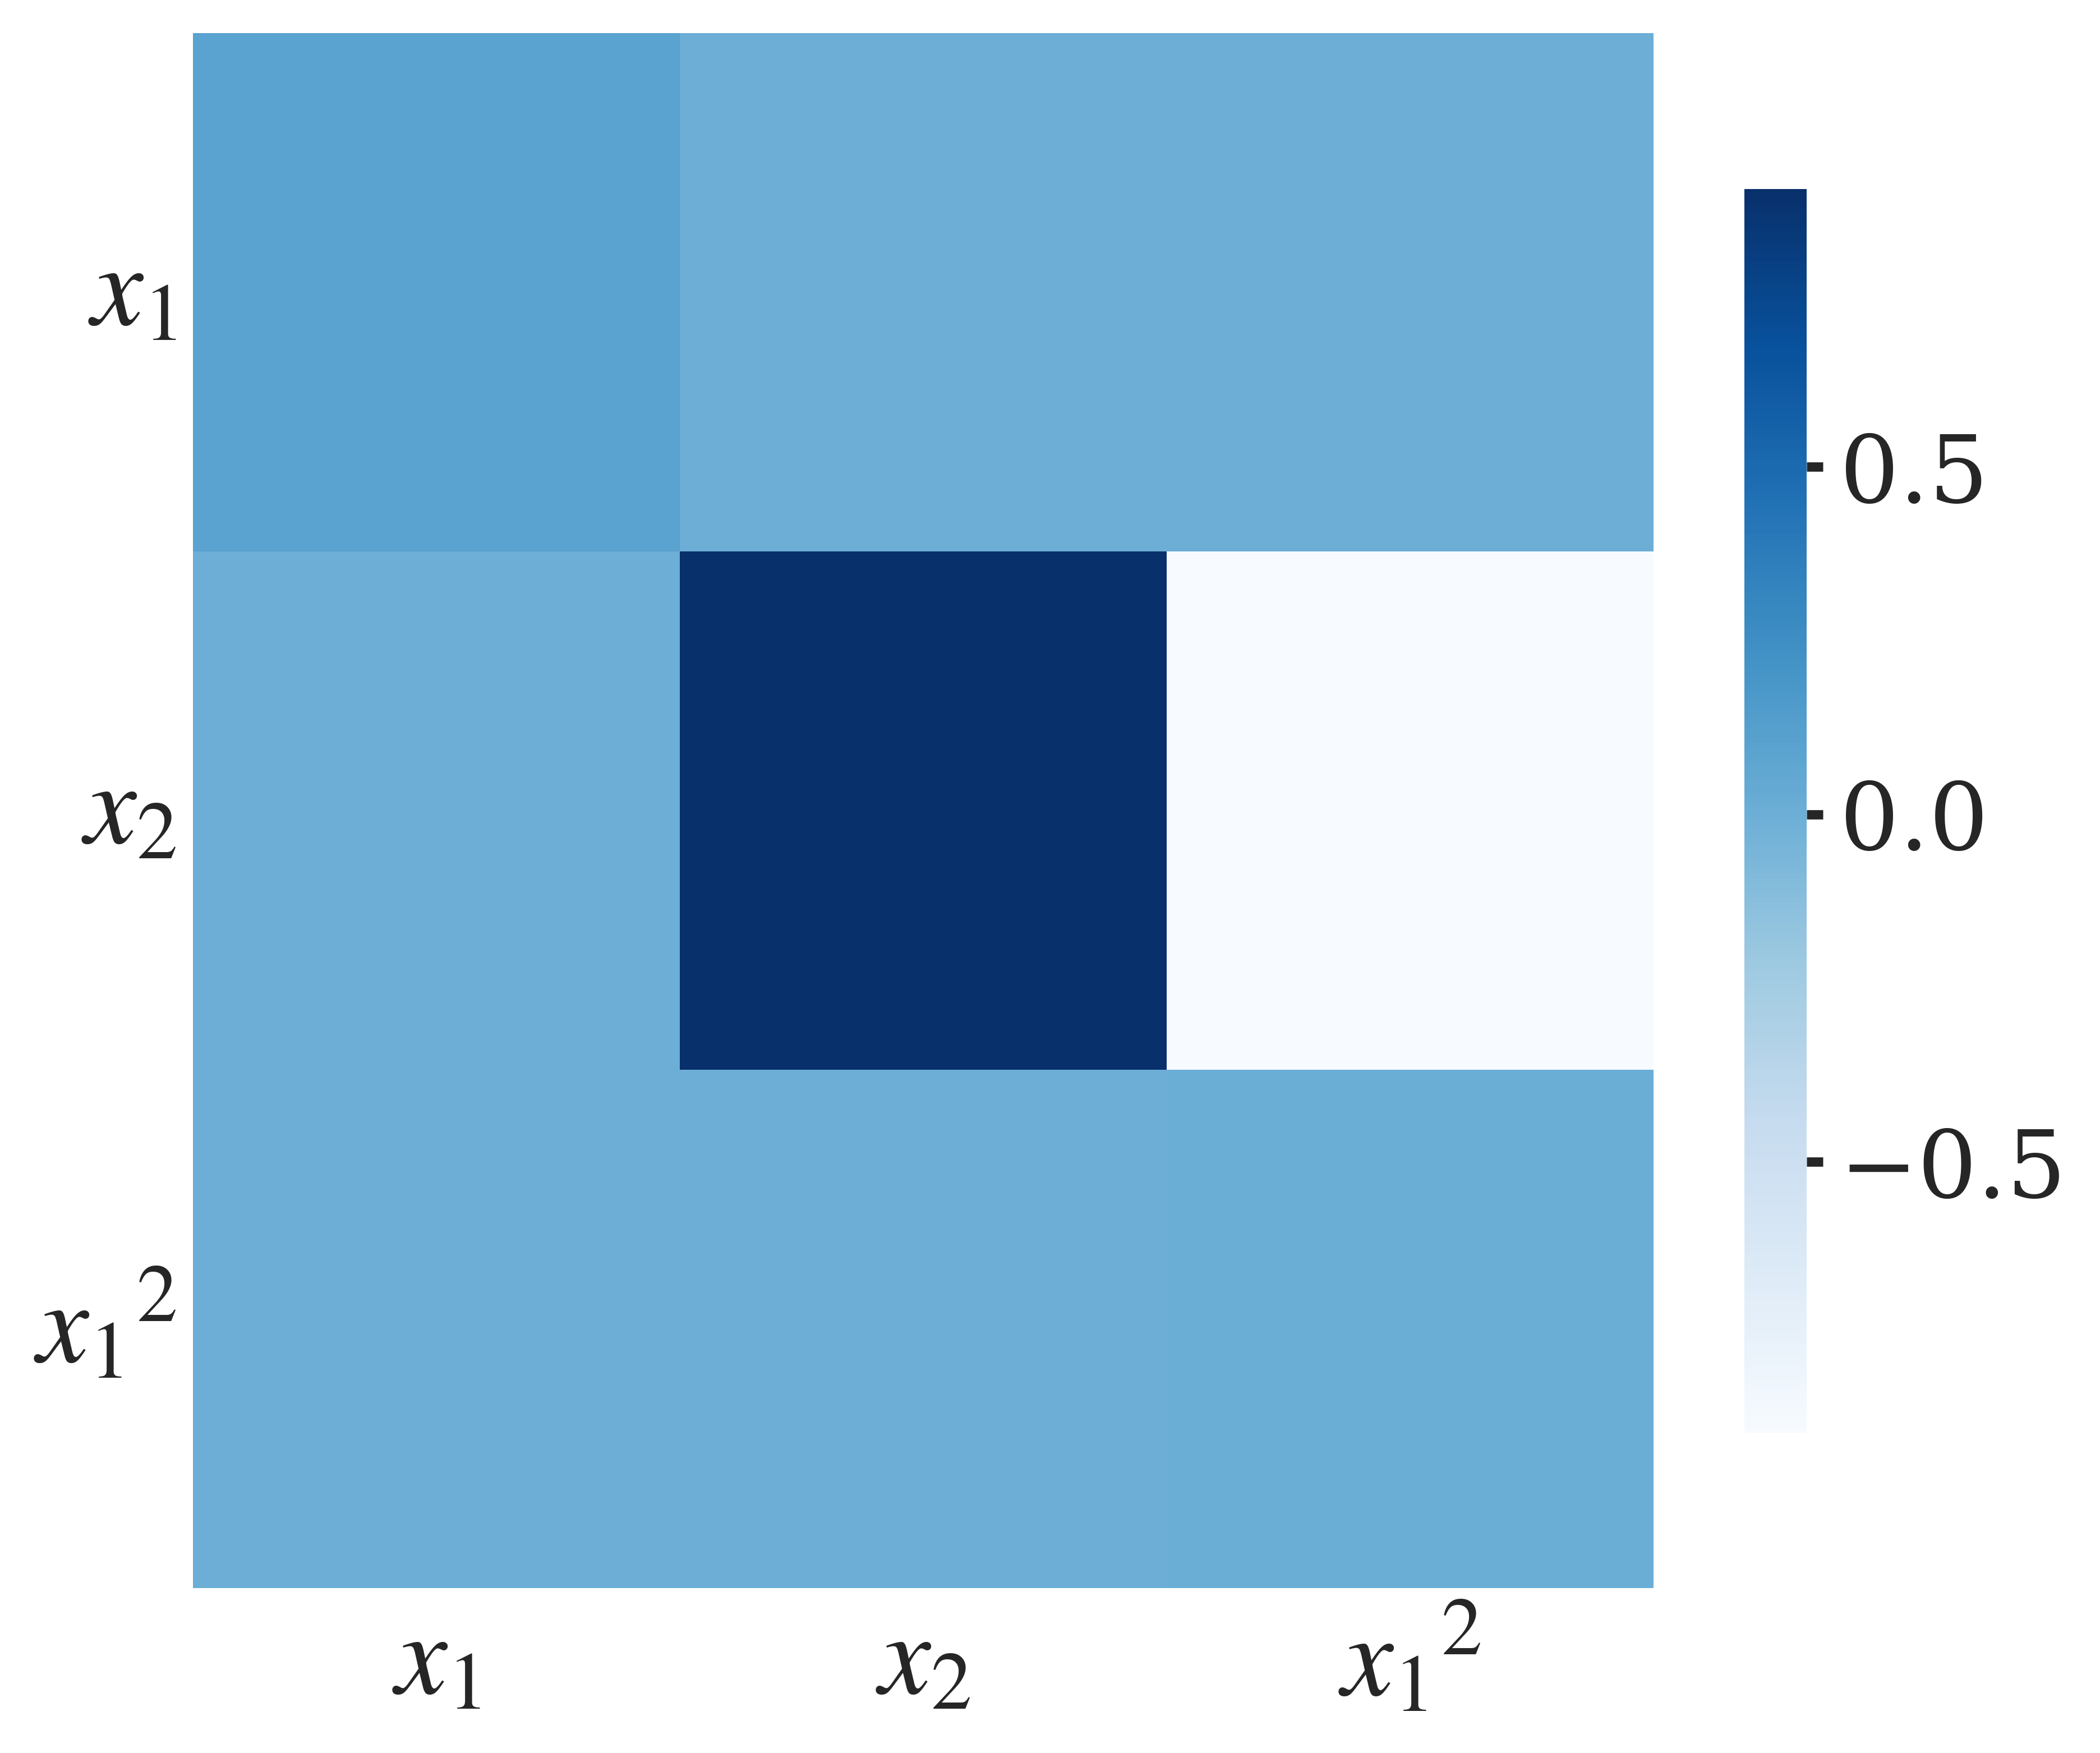

In [11]:
# 只设置参数，不自动显示全部
plt.figure(figsize=(7, 6),dpi=600) # 把画布搞大一点
plt.tick_params(axis='both', which='both', length=0, labelsize=25)
names1=['$x_1$','$x_2$','${x_1}^2$']
heatmap = sns.heatmap(A, xticklabels=names1, yticklabels=names1,cmap=cmap,cbar_kws={'shrink': 0.8})
# plt.title('Analytical Koopman Matrix', fontsize=16, fontweight='bold')
# 旋转横轴标签，避免重叠
plt.xticks(fontsize=25,rotation=0, fontweight='bold')  # 旋转90度
plt.yticks(fontsize=25,rotation=0, fontweight='bold')   # 纵轴保持水平
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=20, width=2) 
plt.show()

In [12]:
A

array([[ 0.1 ,  0.  ,  0.  ],
       [ 0.  ,  0.9 , -0.89],
       [ 0.  ,  0.  ,  0.01]])

In [13]:
# SVD
U,S,V = np.linalg.svd(A)

In [14]:
S

array([1.26576042, 0.1       , 0.00711035])

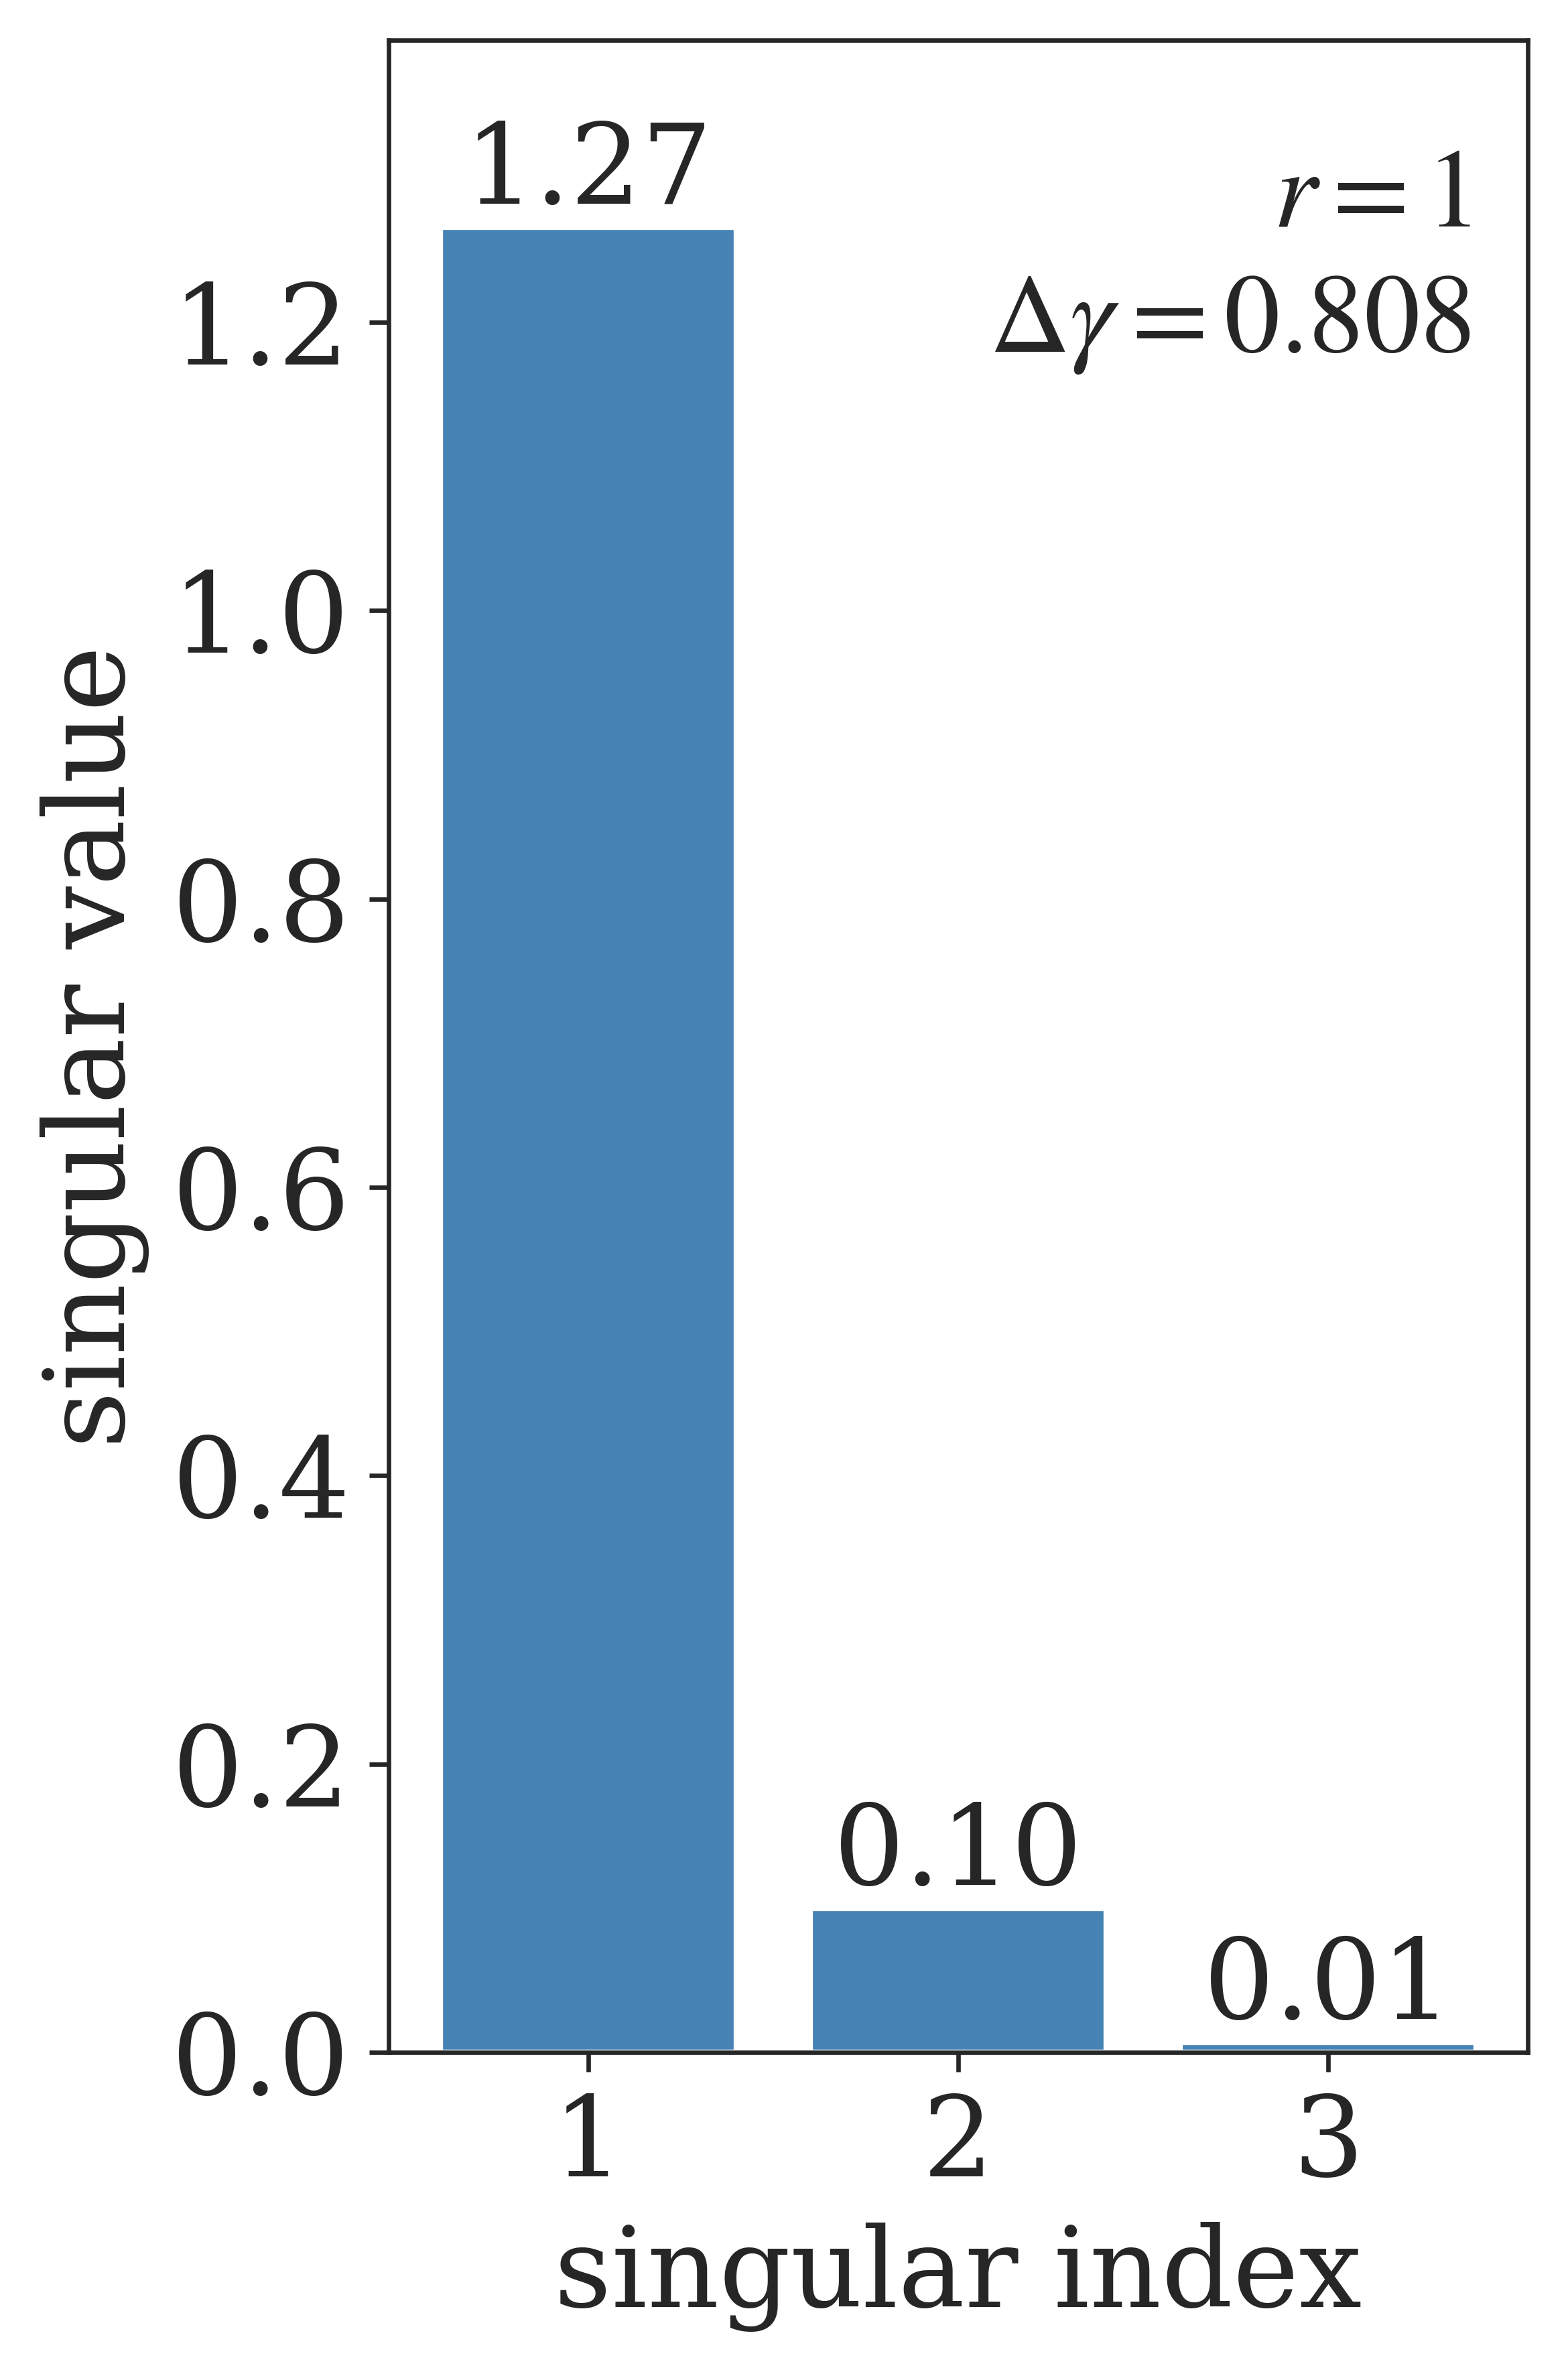

In [15]:
fig, ax = plt.subplots(figsize=(4, 6),dpi=600)
bars = ax.bar(range(1,len(S)+1), S, color='steelblue')
for b in bars:
    height = b.get_height()
    plt.text(b.get_x() + b.get_width()/2,height,f'{height:.2f}',
             ha='center', va='bottom', fontsize=20)
ax.set_xlabel('singular index', fontsize=20)
ax.set_ylabel('singular value', fontsize=20)
#ax.set_title('singular value', fontsize=16, fontweight='bold')
ax.tick_params(axis='both', labelsize=20)

ax.text(0.95, 0.95,
        r'$r = 1$' + '\n' + r'$\Delta\gamma = 0.808$',
        transform=ax.transAxes,      # 使用轴坐标系
        ha='right', va='top',        # 锚定在右上角
        fontsize=20,fontweight='bold')
# 自动调整Y轴范围，考虑所有图形元素
ax.relim()      # 重新计算数据限制
ax.autoscale_view(scalex=False, scaley=True)  # 只自动缩放Y轴
# 或者使用以下更精确的控制：
# ax.autoscale(axis='y', tight=False)

# 如果需要额外边距
current_ylim = ax.get_ylim()
ax.set_ylim([0, current_ylim[1] * 1.05]) 
plt.tight_layout()
plt.show()

In [16]:
# 选取截断
rank = 1
S_macro = S[:rank]
delt_gamma = sum(S_macro) / rank - sum(S) / len(S)
print(delt_gamma)

0.8081368304445518


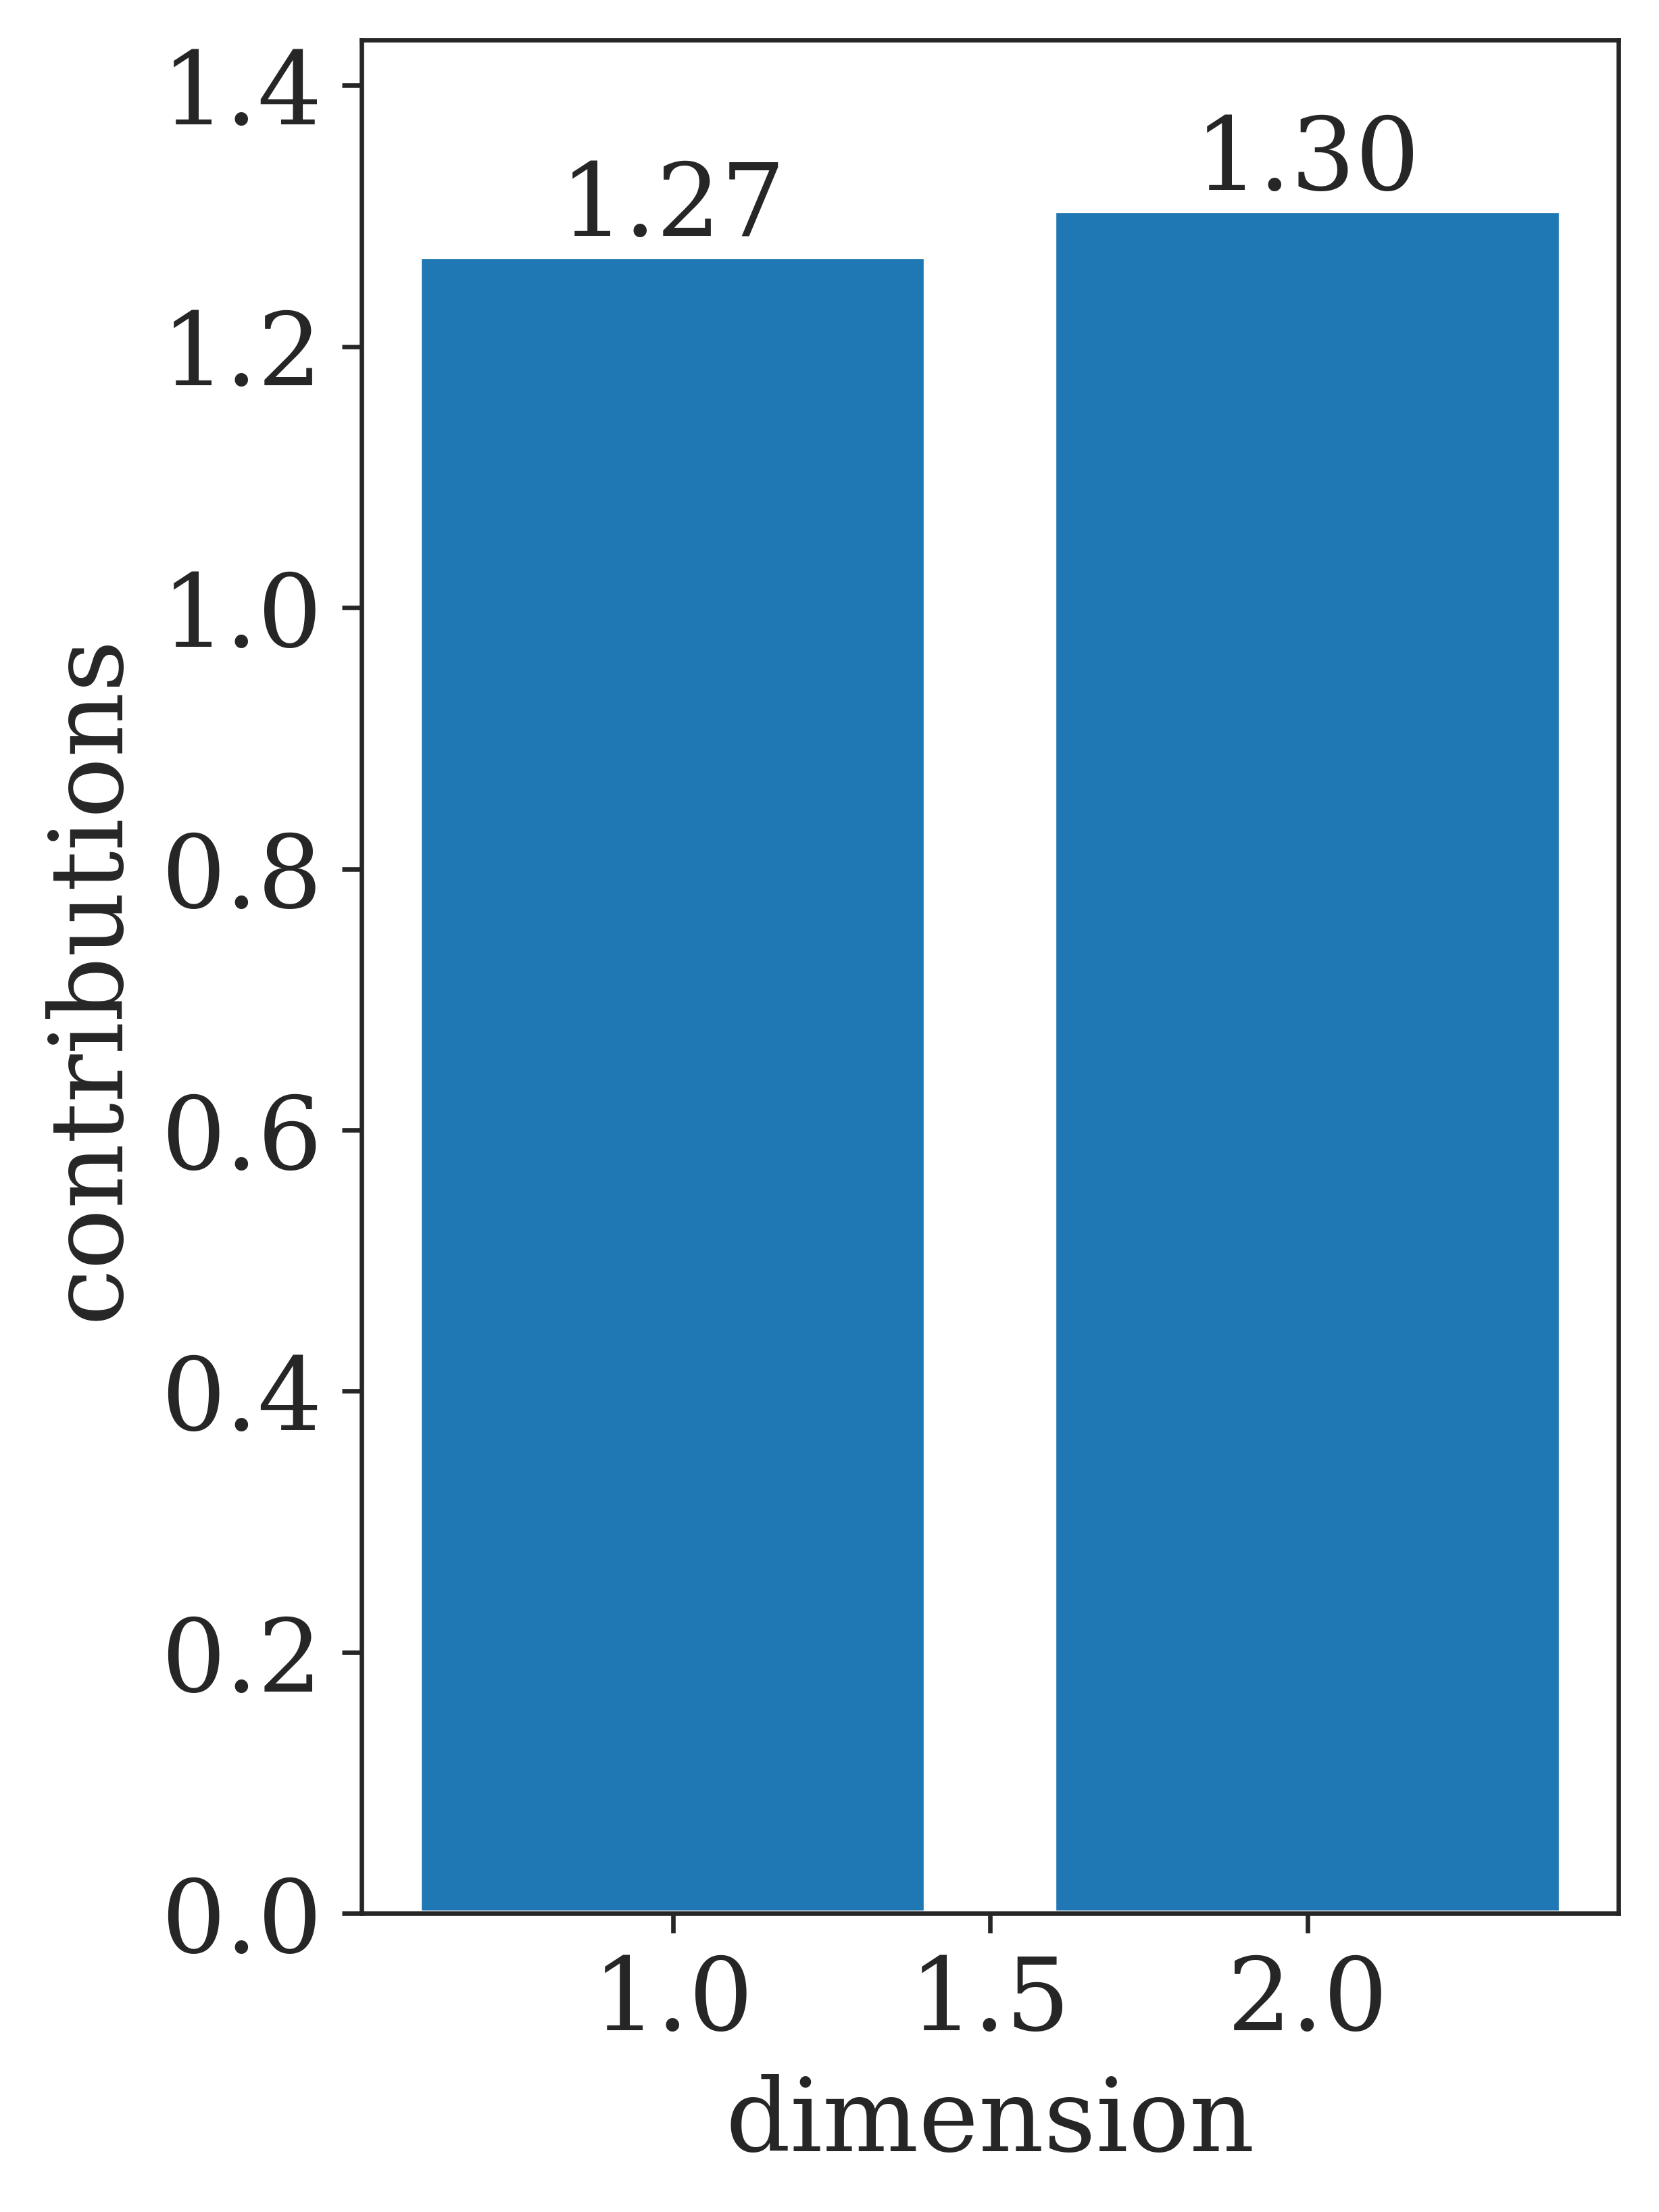

In [17]:
# 多尺度因果力分布
diff = get_positive_contributions(S)
plt.figure(figsize=(4, 6),dpi=600)
bars = plt.bar(range(1,len(diff)+1), diff) 
for b in bars:
    height = b.get_height()
    plt.text(b.get_x() + b.get_width()/2,height,f'{height:.2f}',
             ha='center', va='bottom', fontsize=18)
plt.xlabel('dimension', fontsize=18)
plt.ylabel('contributions', fontsize=18)
#plt.title('positive contributions', fontsize=16, fontweight='bold')
plt.tick_params(axis='both', labelsize=18)
#plt.text(0.80, 0.90, 'EC = 0.99987', transform=plt.gca().transAxes, fontsize=20, ha='center')
plt.ylim(0, max(diff) * 1.1) 
plt.show()


In [18]:
# 计算EC
print(compute_entropy(diff))

0.9998656418509548


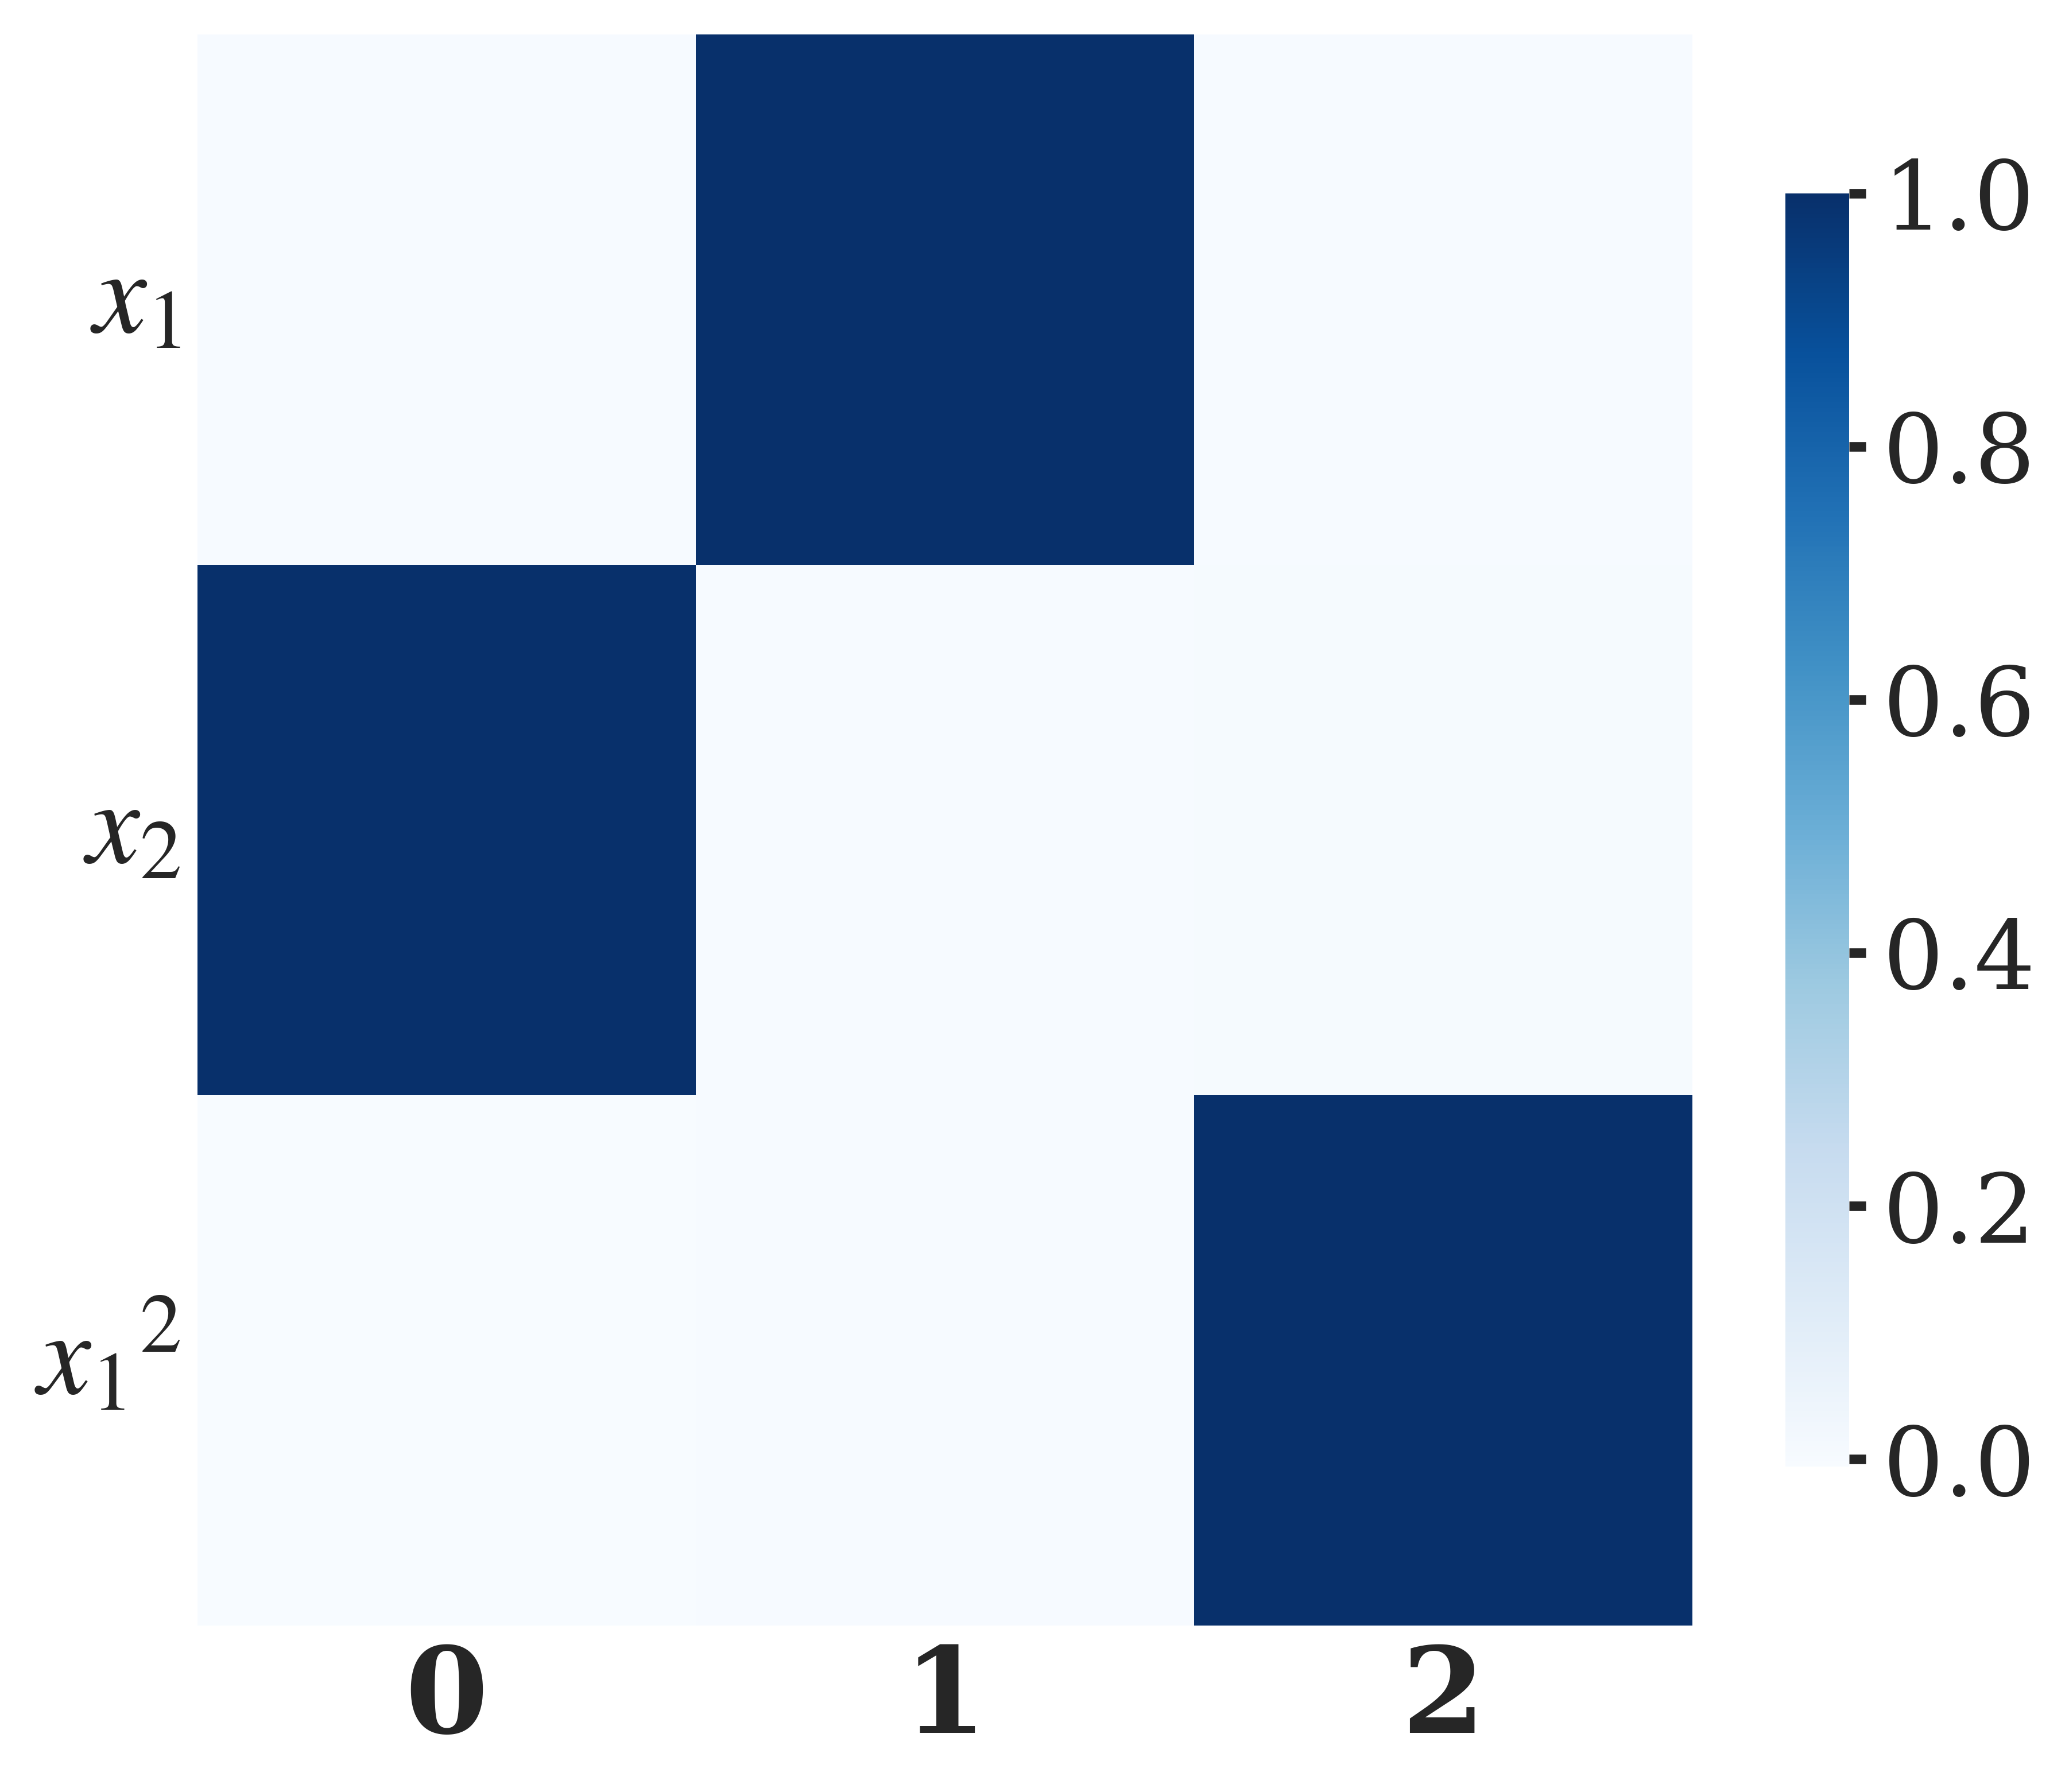

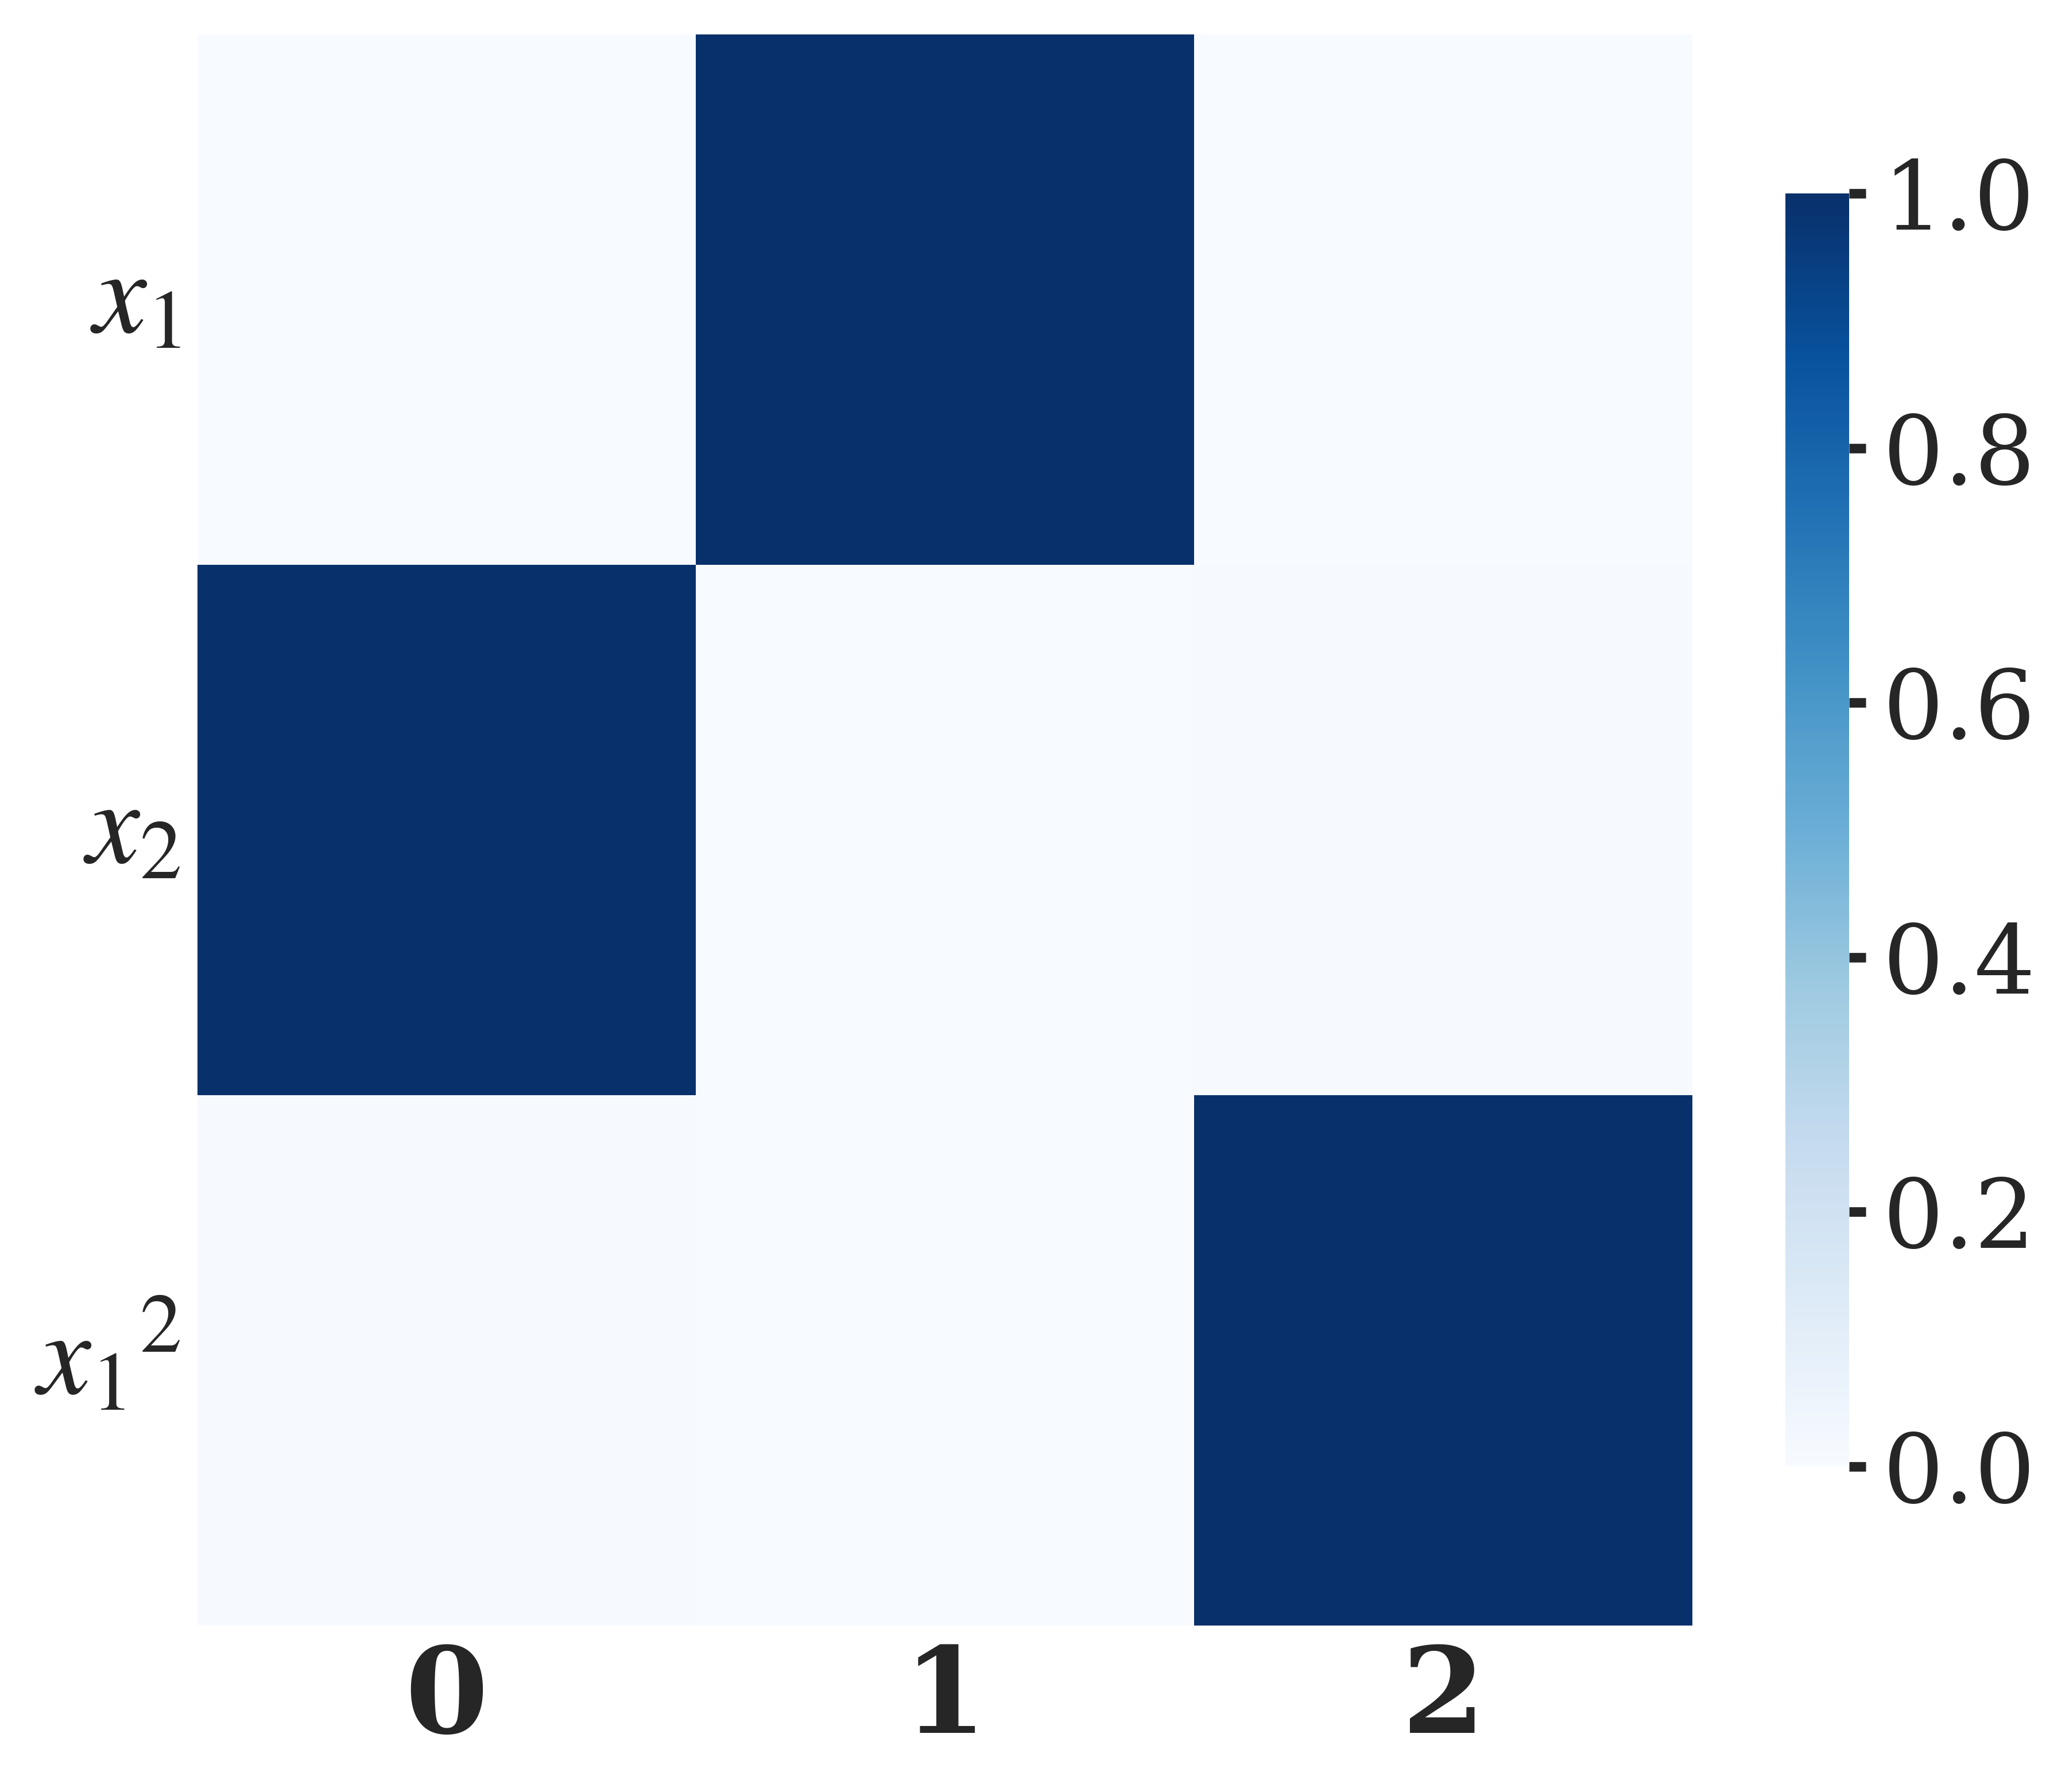

In [19]:
# 绘制奇异向量
U_abs = np.abs(U)

plt.figure(figsize=(7, 6),dpi=600) 
plt.tick_params(axis='both', which='both', length=0, labelsize=25)
heatmap = sns.heatmap(U, yticklabels=names1,cmap=cmap,cbar_kws={'shrink': 0.8})
plt.xticks(fontsize=25,rotation=0, fontweight='bold')  
plt.yticks(fontsize=25,rotation=0, fontweight='bold') 
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=20, width=2) 
plt.show()


plt.figure(figsize=(7, 6),dpi=600) 
plt.tick_params(axis='both', which='both', length=0, labelsize=25)
heatmap = sns.heatmap(U_abs, yticklabels=names1,cmap=cmap,cbar_kws={'shrink': 0.8})
plt.xticks(fontsize=25,rotation=0, fontweight='bold')  
plt.yticks(fontsize=25,rotation=0, fontweight='bold')   
#plt.title('U', fontsize=16, fontweight='bold')
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=20, width=2) 
plt.show() 

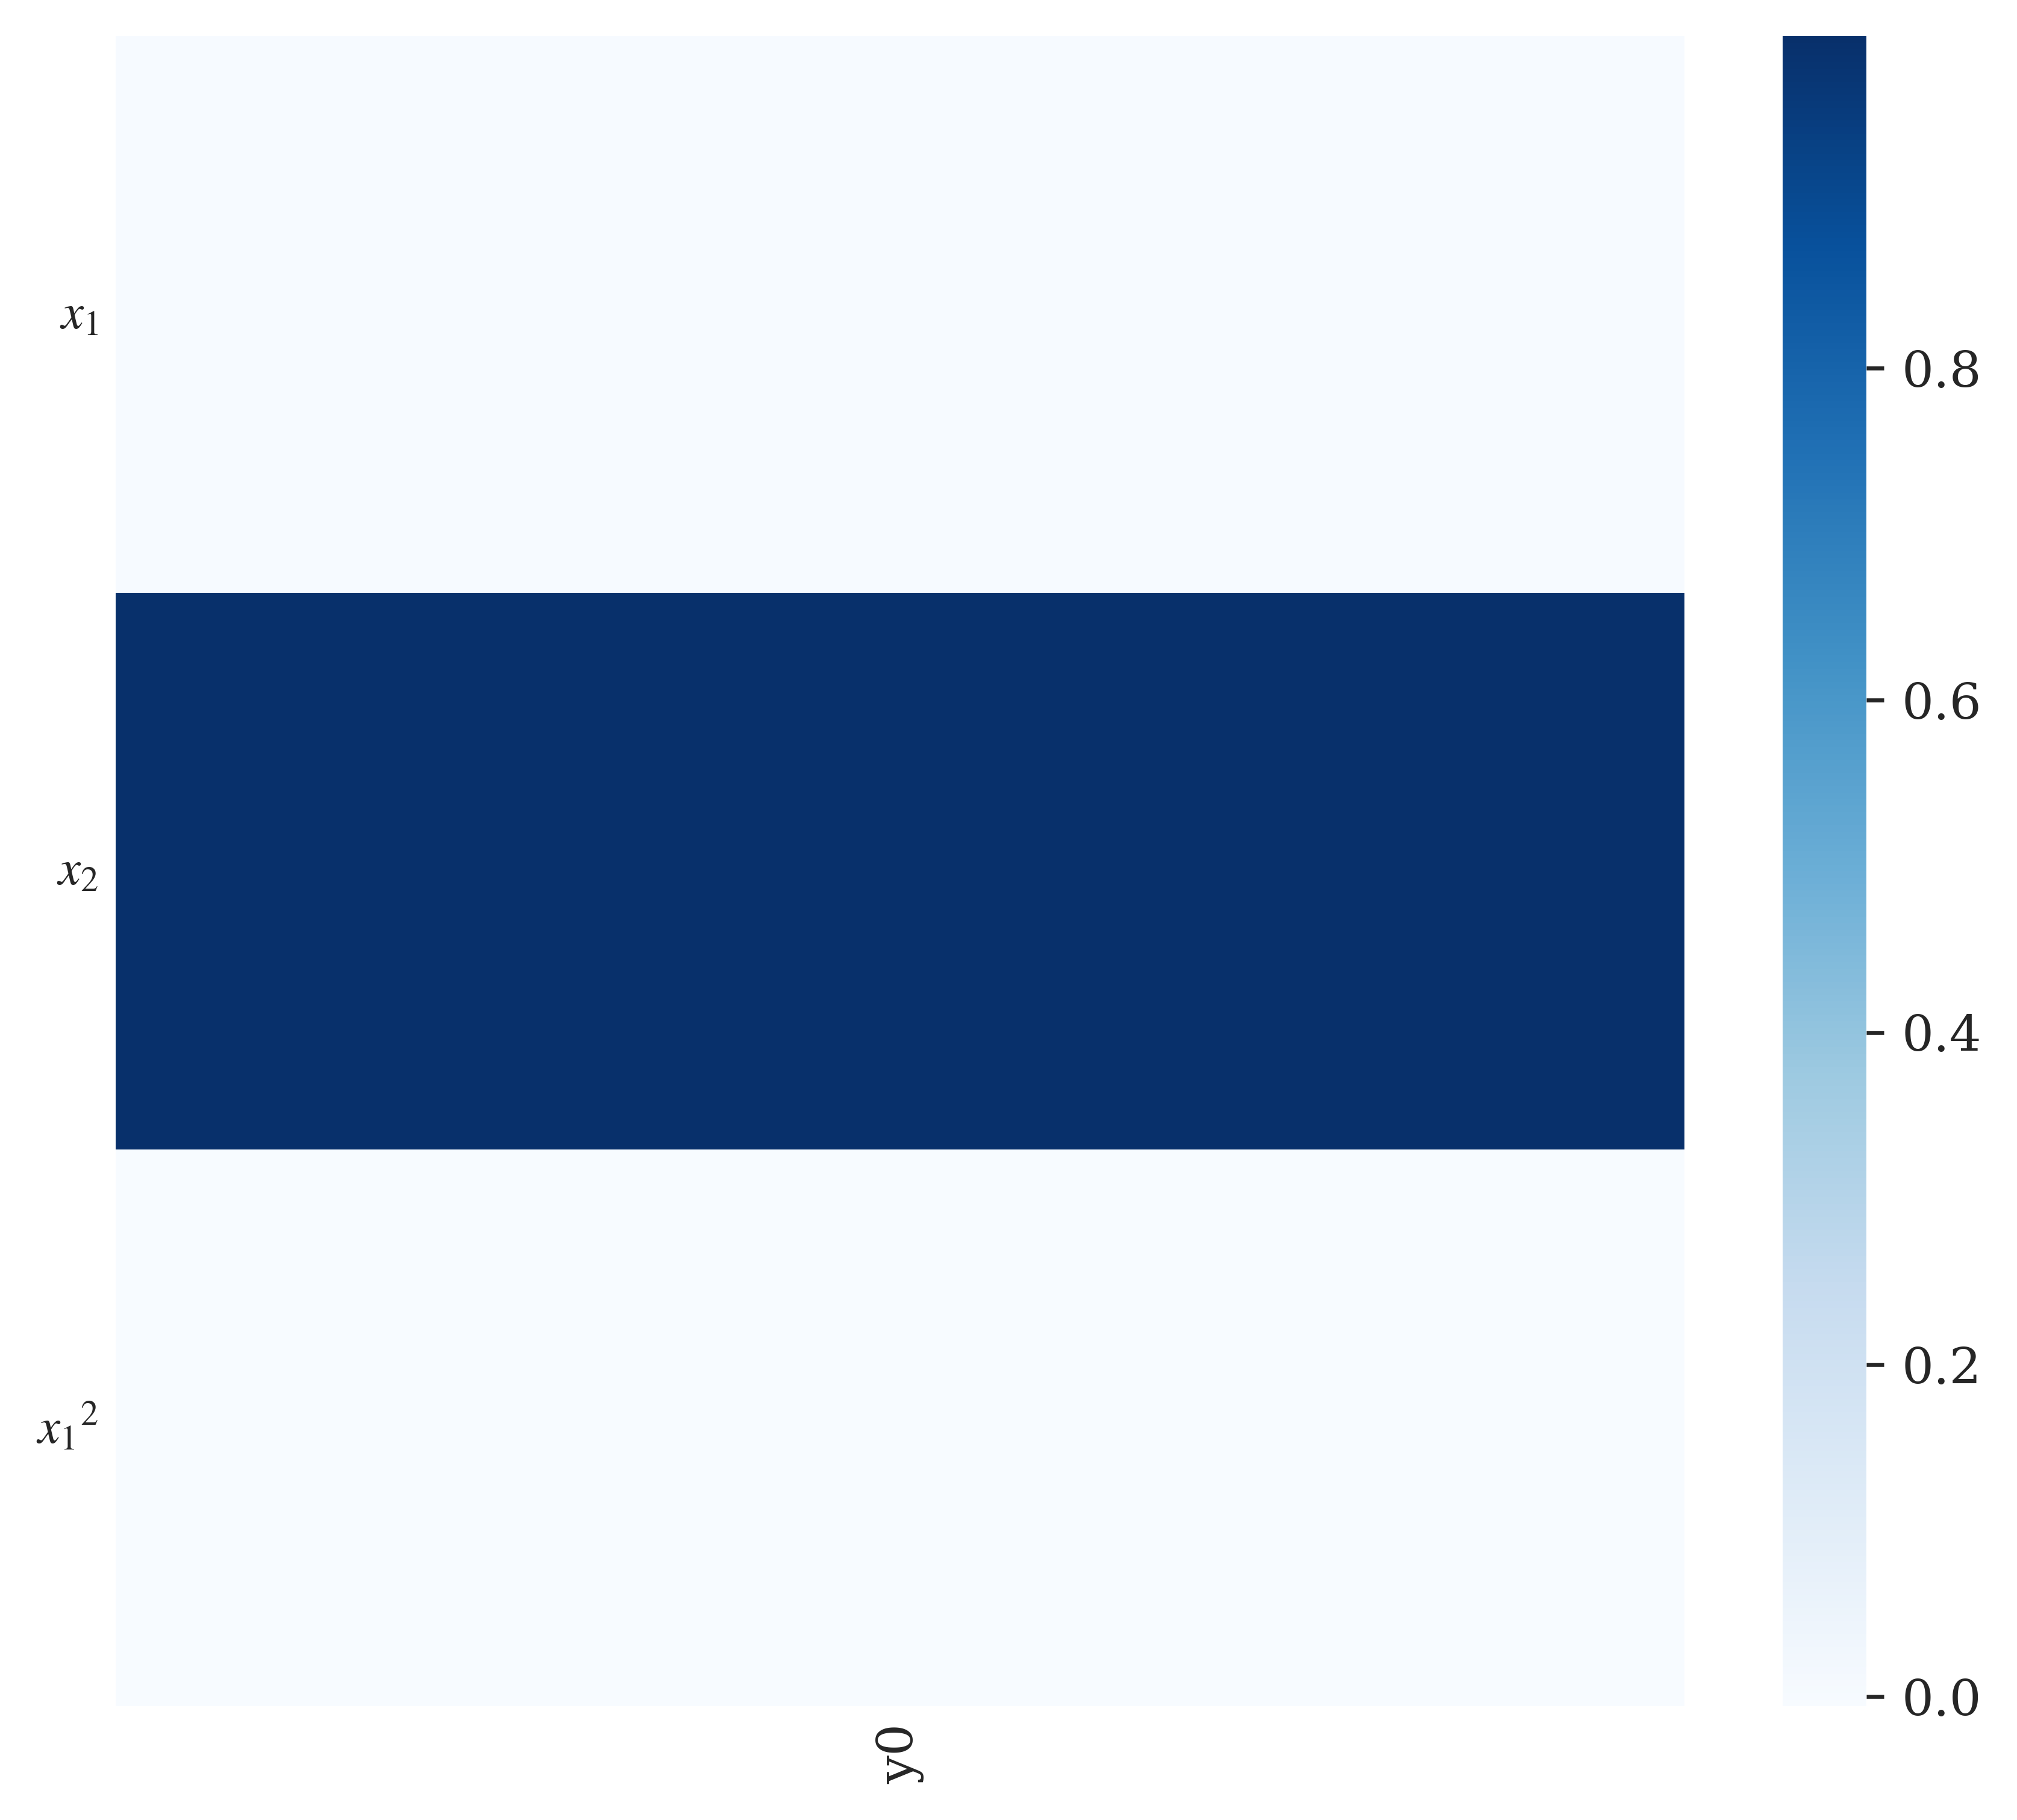

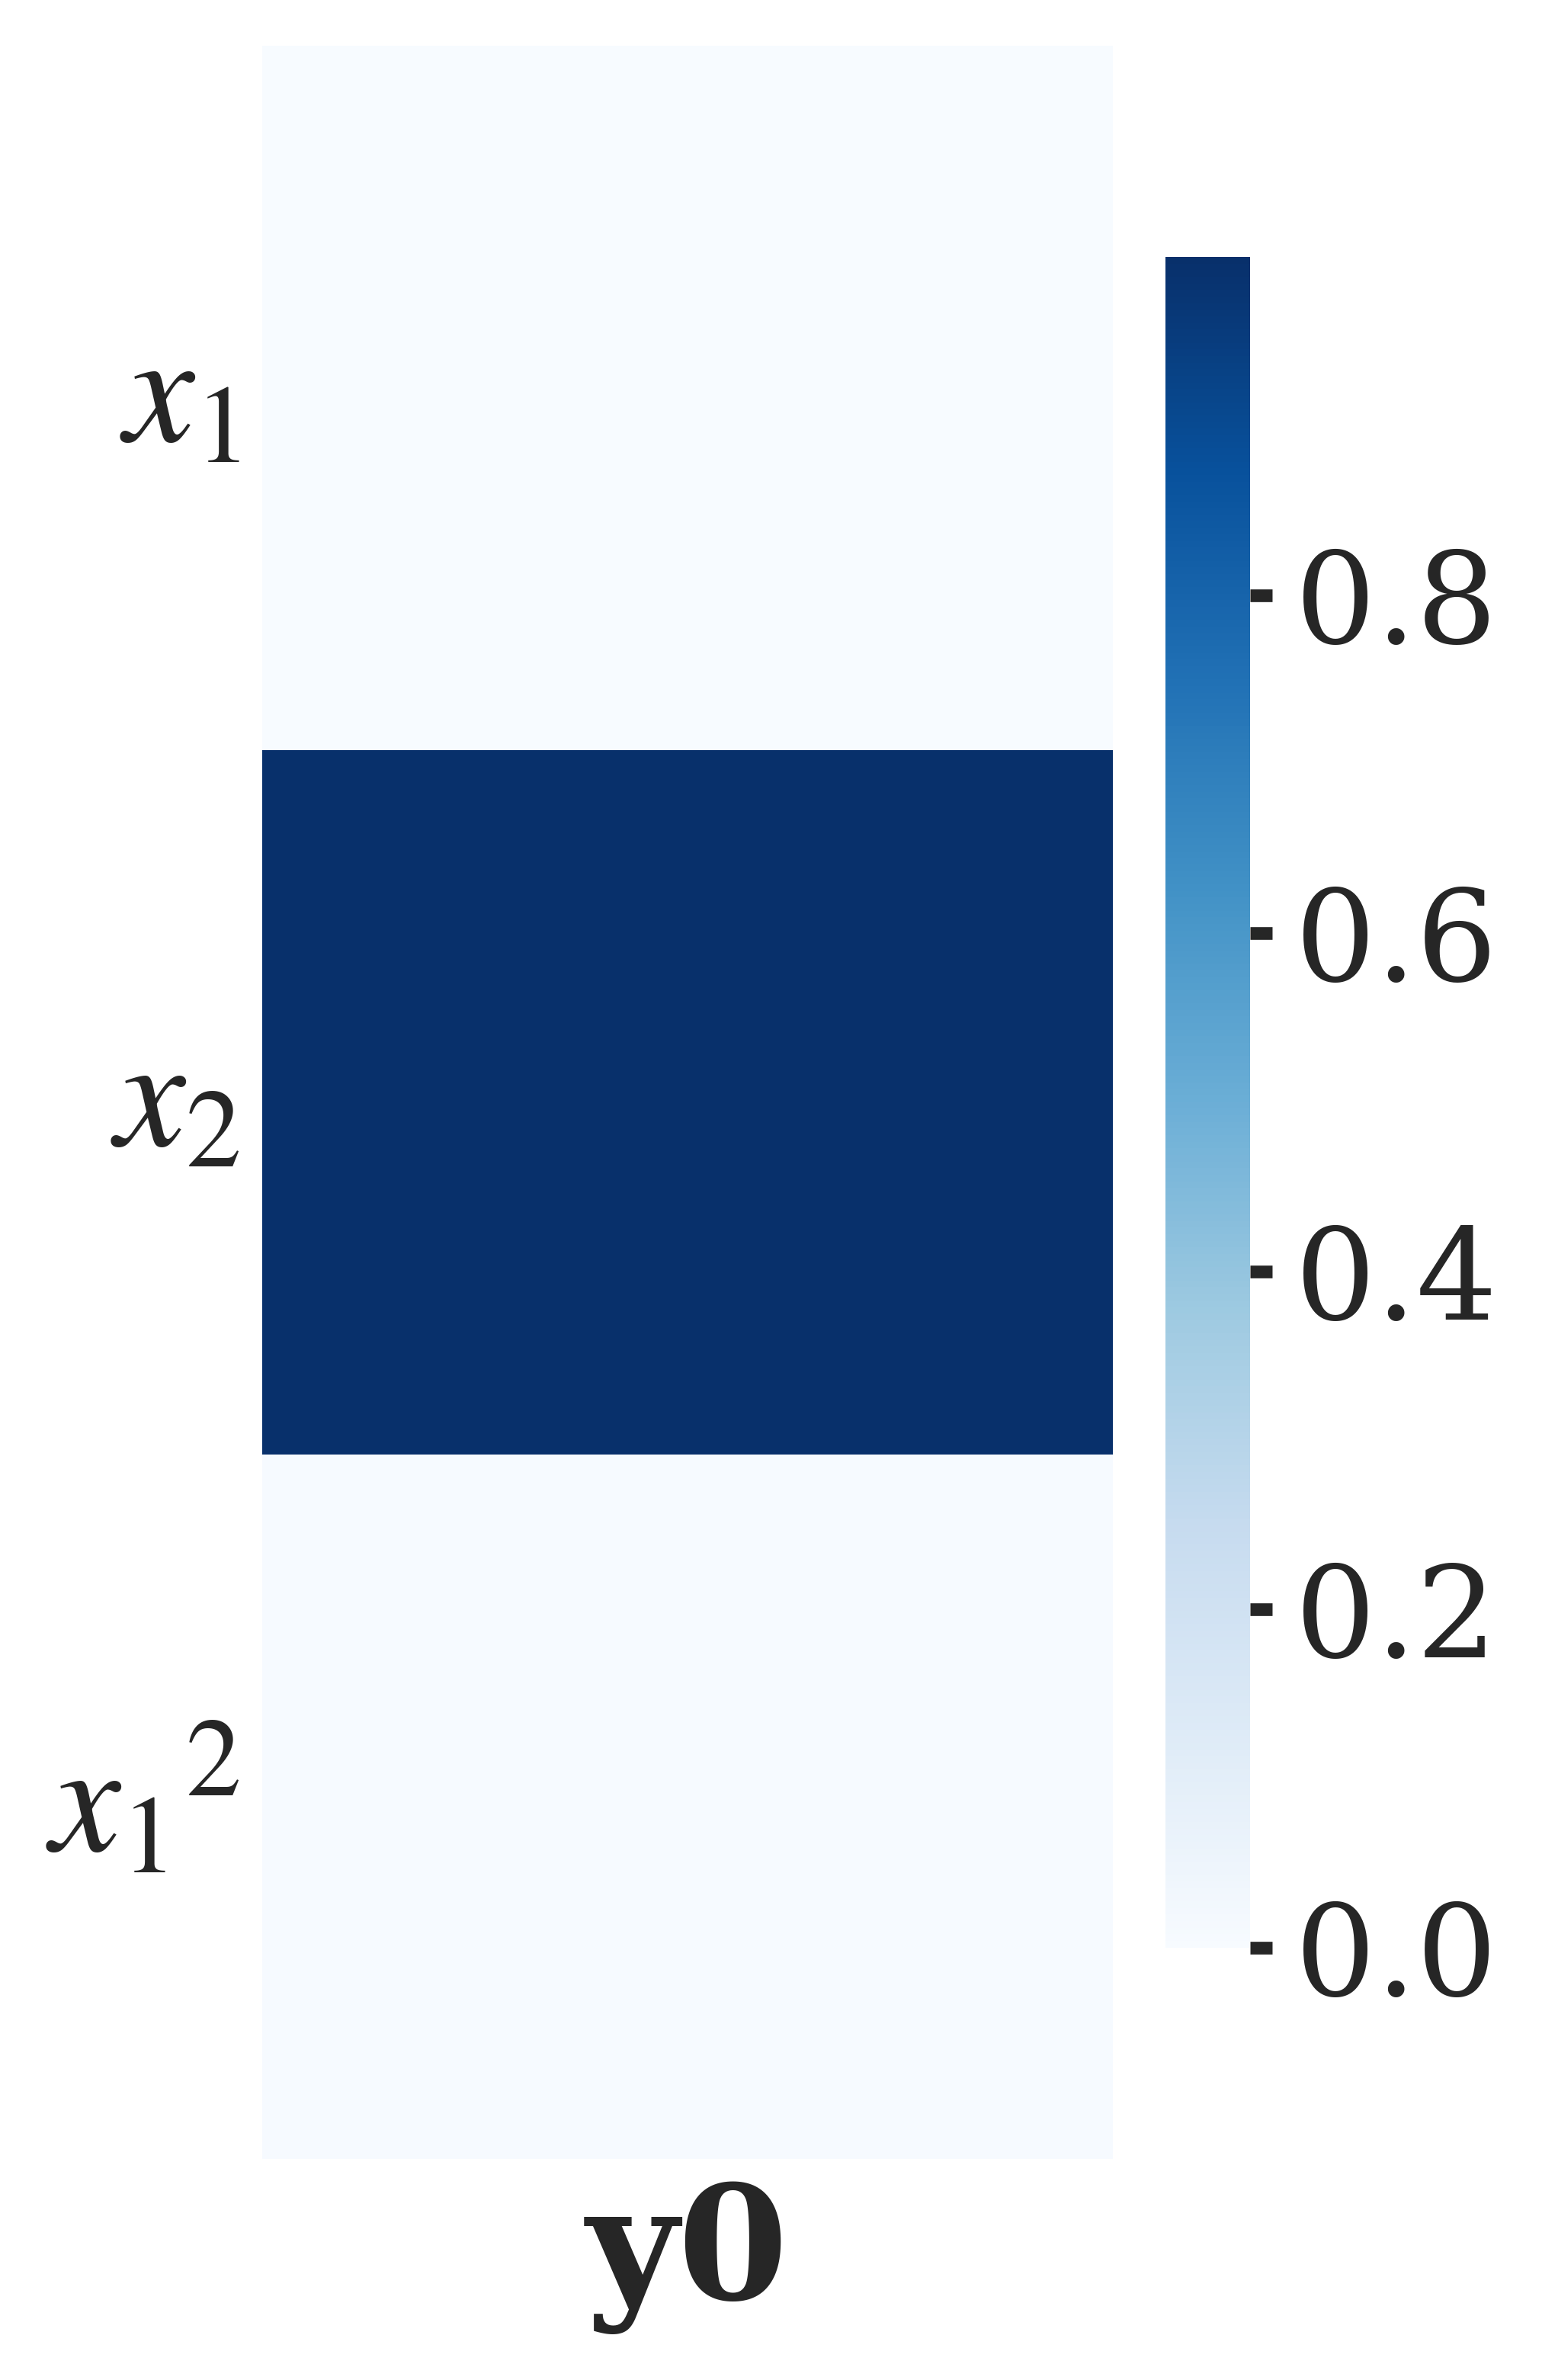

In [20]:
# 粗粒化函数系数
macro_name = [f'y{i}' for i in range(rank)]
coarse_grain_coff = U[:,:rank]

plt.figure(figsize=(7, 6),dpi=600) 
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(coarse_grain_coff, yticklabels=names1, xticklabels=macro_name,cmap=cmap)
plt.xticks(rotation=90)  
plt.yticks(rotation=0)   
plt.show()


plt.figure(figsize=(3, 6),dpi=600) 
plt.tick_params(axis='both', which='both', length=0, labelsize=25)
heatmap = sns.heatmap(np.abs(coarse_grain_coff), yticklabels=names1, xticklabels=macro_name,cmap=cmap,cbar_kws={'shrink': 0.8})
plt.xticks(fontsize=25,rotation=0, fontweight='bold')  
plt.yticks(fontsize=25,rotation=0, fontweight='bold')    
#plt.title('U[:,1]', fontsize=16, fontweight='bold')
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=20, width=2) 
plt.show()


In [21]:
# 输出粗粒化函数表达式
print_equations(coarse_grain_coff, names1, macro_name)

y0 = 1.0000 * $x_2$ - 0.0056 * ${x_1}^2$
------------------------------


In [22]:
coarse_grain_coff

array([[ 0.        ],
       [ 0.99998457],
       [-0.0055553 ]])

### 宏观变量时间序列

这一小节把第二部分得到的粗粒化变量代回时间序列中，直接观察宏观变量如何演化，并检查恢复出来的宏观方程是否与原始动力学一致。


In [23]:
def gen_step_data(
    initial_x=5,
    initial_y=5,
    lam=0.1,
    mu=0.9,
    total_steps=200,
    dt=1,
    random_seed=None
):
    """
    生成step模型数据（向量化版本）
    """
    # 设置随机种子
    if random_seed is not None:
        np.random.seed(random_seed)
    
    # 生成时间点
    t = np.arange(0, total_steps * dt, dt)
    n_points = len(t)
    
    # 初始化数组
    x_vals = np.zeros(n_points)
    y_vals = np.zeros(n_points)
    
    # 设置初始值
    x_vals[0], y_vals[0] = initial_x, initial_y
    
    # 迭代生成数据
    for i in range(1, n_points):
        x_vals[i] = lam * x_vals[i-1]
        y_vals[i] = mu * y_vals[i-1] + (lam**2 - mu) * (x_vals[i-1]**2)
    
    # 构建重复列的数据格式
    data_noiseless = np.column_stack([x_vals, y_vals])
    
    return data_noiseless, t

In [24]:
# 单时间序列采样
data, t = gen_step_data(initial_x=5,initial_y=5,lam=0.1,mu=0.9,total_steps=500,dt=1)
x_data = data
dt = 1
t_list = t

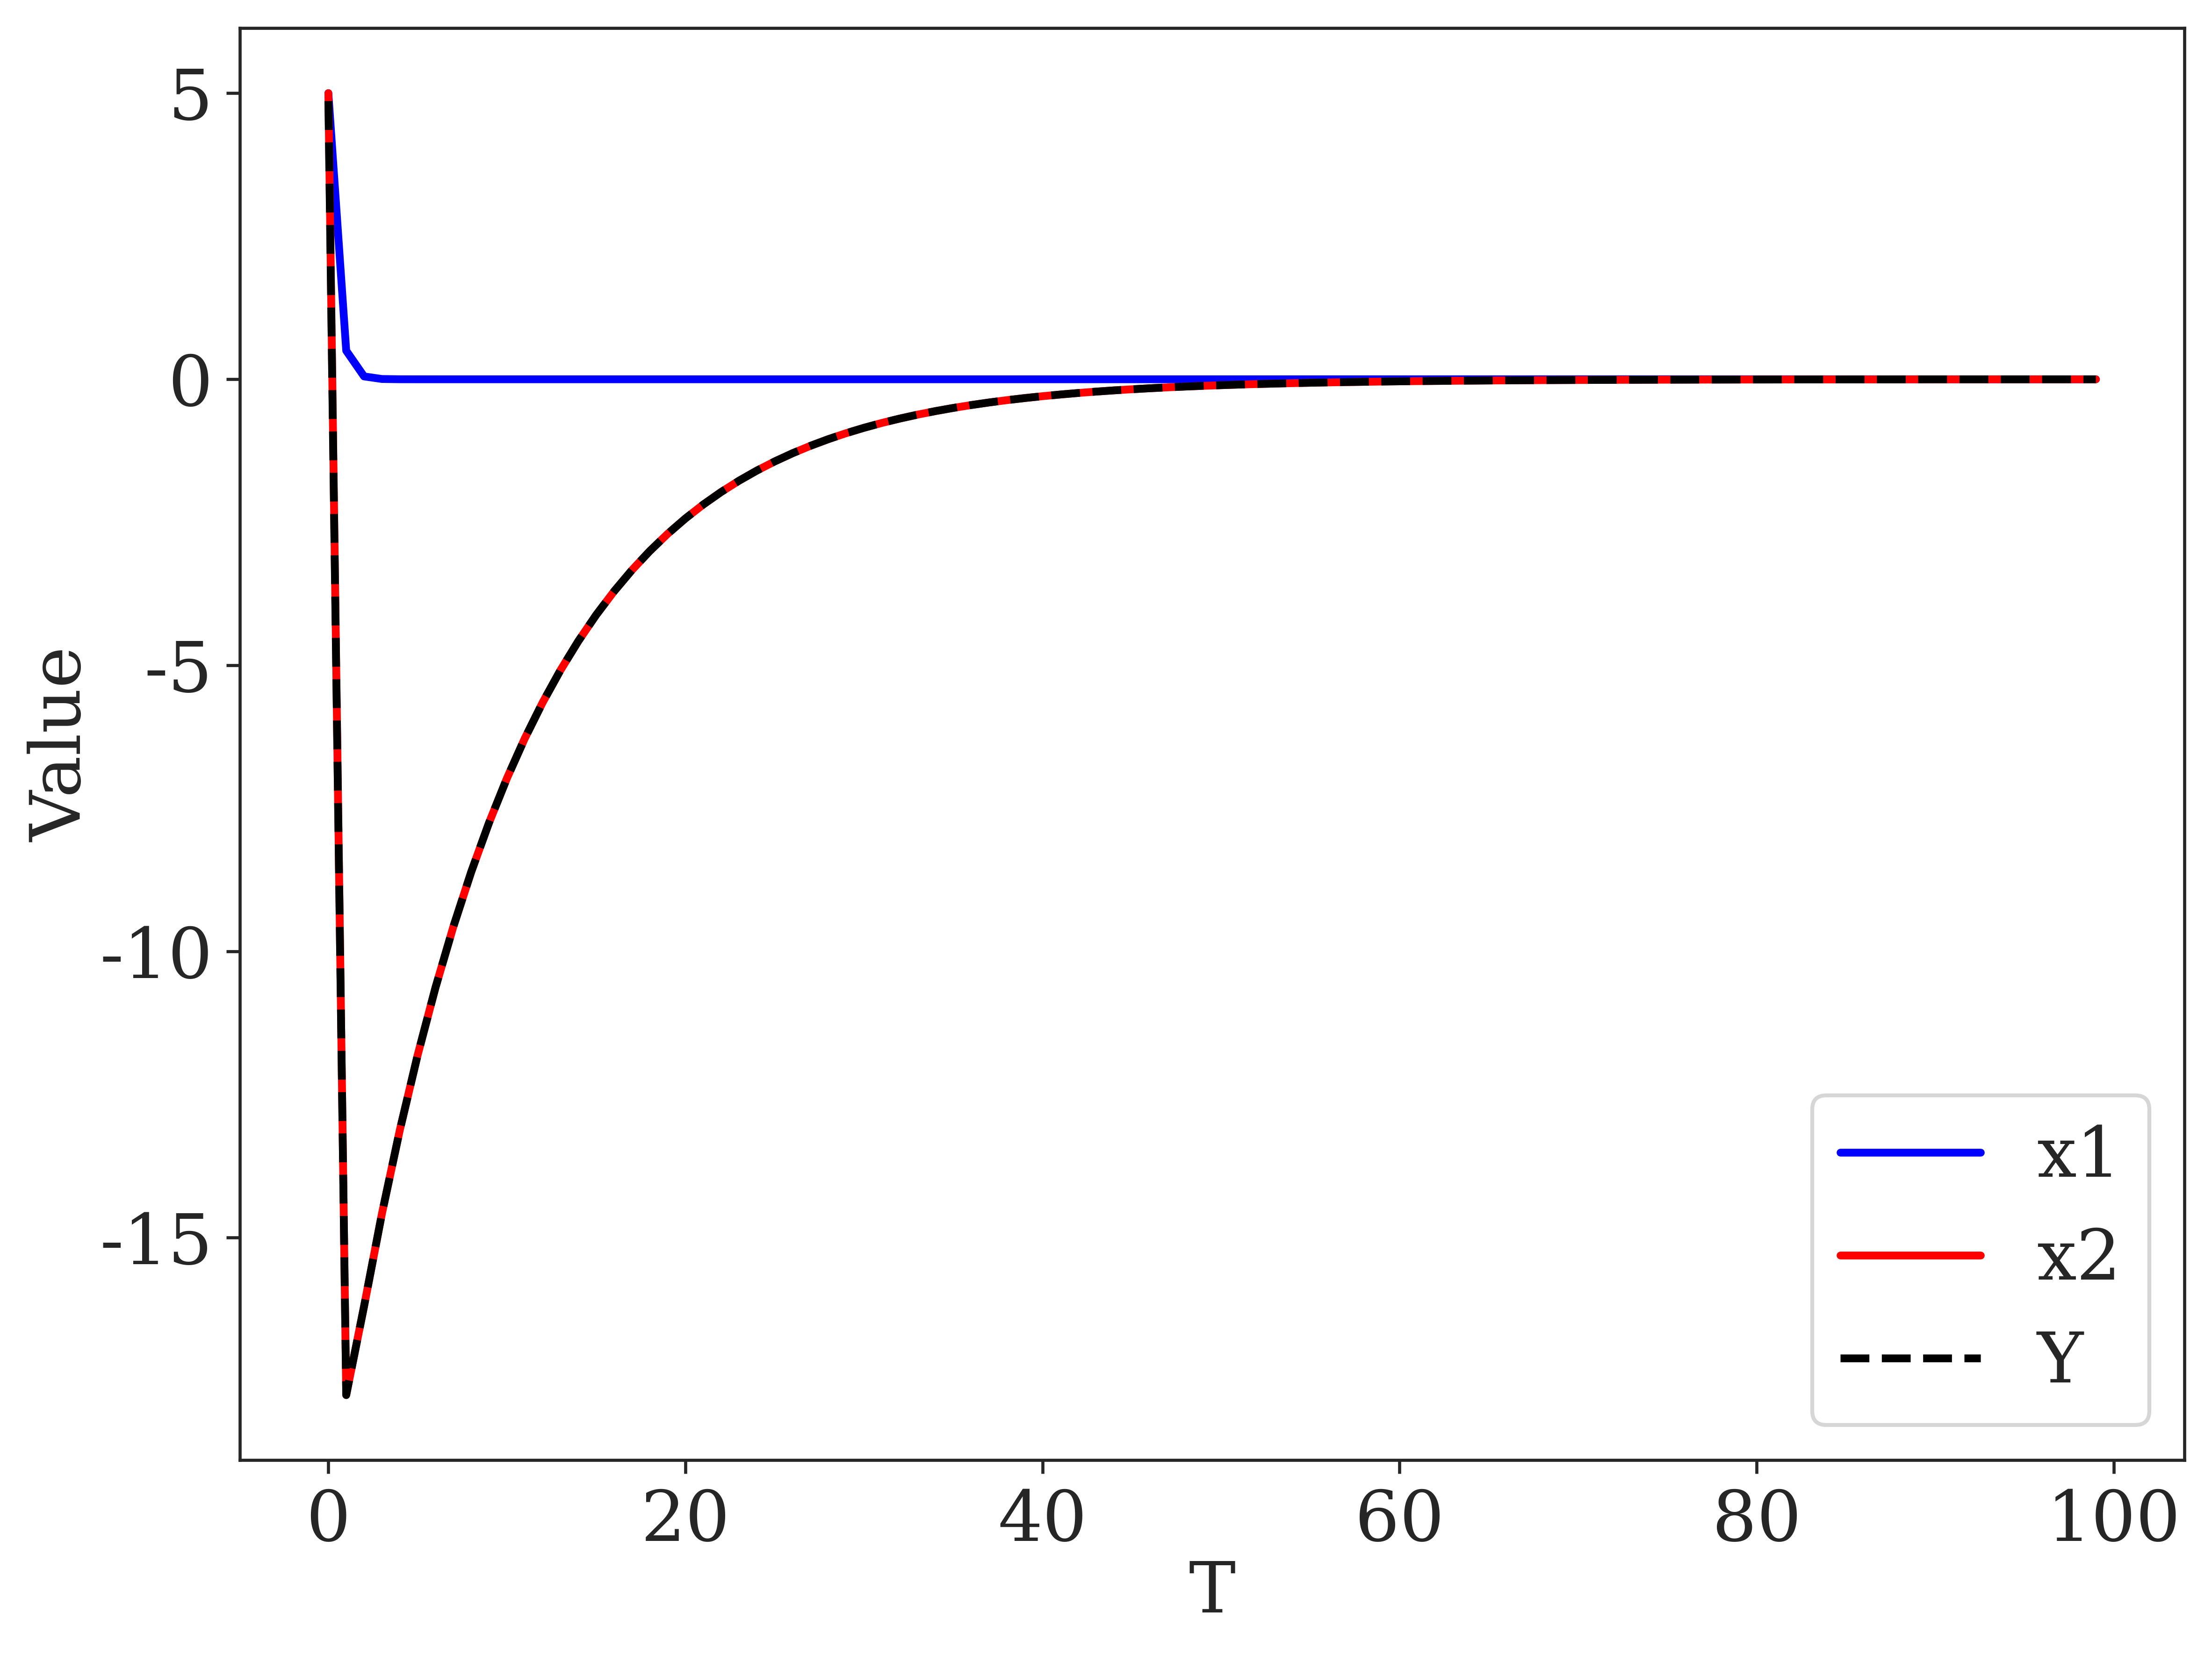

In [25]:
x1 = x_data[:, 0]  # 第一自变量：x1
x2 = x_data[:, 1]  # 第二自变量：x2
x1_square = x1 ** 2  # 第三自变量：x1的平方
# 线性组合构建Y：Y = coff[0]*x1 + coff[1]*x2 + coff[2]*x1²
Y = coarse_grain_coff[0] * x1 + coarse_grain_coff[1] * x2 + coarse_grain_coff[2] * x1_square

Y_data = Y.reshape(-1, 1)  # 转为列向量，方便后续拼接/处理

# -------------------------- 4. 绘制x1、x2、Y的曲线图 --------------------------
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示问题
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题
plt.figure(figsize=(8, 6), dpi=600)  # 设置画布大小和分辨率

# 绘制三条曲线：x1、x2、Y，分别设置颜色、标签、线宽
plt.plot(t_list[:100], x1[:100], color='blue', label='x1', linewidth=2)
plt.plot(t_list[:100], x2[:100], color='red', label='x2', linewidth=2)
plt.plot(t_list[:100], Y[:100], color='black', label='Y', linewidth=2, linestyle='--')

# 添加图表要素：标题、x轴标签、y轴标签、图例、网格
# plt.title('x1/x2 and Y ', fontsize=18, fontweight='bold',pad=10)
plt.xlabel('T', fontsize=18,labelpad=1)
plt.ylabel('Value', fontsize=18, labelpad=1)
plt.legend(loc='best', fontsize=18)  # 图例放在最优位置
#plt.legend(loc='best', fontsize=18, prop={'weight': 'bold', 'size': 18})  # 图例放在最优位置
plt.grid(False)  
# 设置坐标轴刻度字体大小
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# 调整布局，防止标签被截断
plt.tight_layout()
# 显示图像
plt.show()


In [26]:
# 给出宏观动力学方程
A_macro = coarse_grain_coff.T @ A @ coarse_grain_coff
macro_name_k = [i+'[k]' for i in macro_name]
macro_name_next = [i+'[k+1]' for i in macro_name]
print_equations(A_macro, macro_name_k, macro_name_next)

y0[k+1] = 0.9049 * y0[k]
------------------------------


## 3. 先生成数据，再从数据中拟合 $K$，然后做 SVD 与粗粒化

这一部分采用数据驱动的思路。现在假设解析 Koopman 矩阵 $K$ 不能直接得到，只能先观察时间序列数据，再在 lifted 空间中拟合一个近似的线性模型。

这一部分会先定义数据生成函数，然后补充带噪声观测的版本。

这里的高斯噪声指服从正态分布 $\mathcal{N}(0, \sigma^2)$ 的噪声。标准正态噪声只是它的一个特例，对应 $\sigma = 1$，也就是 $\mathcal{N}(0,1)$。在实际实验中，更常见的是保持均值为 0，然后通过调整标准差 $\sigma$ 来控制噪声强度。


### 数据生成函数

先定义无噪声的数据生成函数。这个函数只负责根据初值和参数生成确定性的时间序列。


In [27]:
def gen_step_data(
    initial_x=5,
    initial_y=5,
    lam=0.1,
    mu=0.9,
    total_steps=200,
    dt=1,
    random_seed=None
):
    """
    生成 step 模型的无噪声时间序列数据。

    动力学方程：
        x_{k+1} = lam * x_k
        y_{k+1} = mu * y_k + (lam**2 - mu) * x_k**2
    """
    if random_seed is not None:
        np.random.seed(random_seed)

    t = np.arange(0, total_steps * dt, dt)
    n_points = len(t)

    x_vals = np.zeros(n_points)
    y_vals = np.zeros(n_points)
    x_vals[0], y_vals[0] = initial_x, initial_y

    for i in range(1, n_points):
        x_vals[i] = lam * x_vals[i - 1]
        y_vals[i] = mu * y_vals[i - 1] + (lam**2 - mu) * (x_vals[i - 1] ** 2)

    data_noiseless = np.column_stack([x_vals, y_vals])
    return data_noiseless, t


### 加噪函数

这个函数只负责给已经生成好的观测数据逐点加入高斯噪声，其中噪声均值固定为 0，标准差由 `noise_std` 控制。

- `noise_std = 0` 表示不加噪声。
- `noise_std = 1` 对应标准正态噪声 $\mathcal{N}(0,1)$。
- 实际上更常用的是较小的 `noise_std`，例如 `0.01`、`0.05` 或 `0.1`，用于模拟不同强度的观测误差。


In [28]:
def add_gaussian_noise(data, noise_std=0.05, random_seed=None):
    """
    给观测数据添加独立同分布的高斯噪声。

    噪声分布为 N(0, noise_std^2)。
    当 noise_std = 1 时，就对应标准正态噪声 N(0, 1)。
    """
    rng = np.random.default_rng(random_seed)
    noise = rng.normal(loc=0.0, scale=noise_std, size=data.shape)
    data_noisy = data + noise
    return data_noisy, noise


### 带噪声的数据生成函数

这个函数把前两步连接起来：先生成无噪声轨道，再叠加高斯噪声。这样后面做拟合时可以很方便地在干净数据和带噪声数据之间切换。


In [29]:
def gen_step_data_with_noise(
    initial_x=5,
    initial_y=5,
    lam=0.1,
    mu=0.9,
    total_steps=200,
    dt=1,
    noise_std=0.05,
    random_seed=None,
    noise_seed=None
):
    """
    先生成无噪声的 step 数据，再叠加高斯噪声。
    """
    data_noiseless, t = gen_step_data(
        initial_x=initial_x,
        initial_y=initial_y,
        lam=lam,
        mu=mu,
        total_steps=total_steps,
        dt=dt,
        random_seed=random_seed,
    )
    data_noisy, noise = add_gaussian_noise(
        data_noiseless,
        noise_std=noise_std,
        random_seed=noise_seed,
    )
    return data_noiseless, data_noisy, noise, t


### 生成样本并选择是否使用带噪声观测

下面的代码会同时生成无噪声数据和带噪声数据。默认仍然使用无噪声数据进入拟合流程，这样更方便和第二部分的解析结果做对照；如果希望测试噪声对拟合和粗粒化的影响，只需要把 `use_noisy_data` 改成 `True`。


In [30]:
noise_std = 0.05
use_noisy_data = False

data_clean, data_noisy, noise, t = gen_step_data_with_noise(
    initial_x=5,
    initial_y=5,
    lam=0.1,
    mu=0.9,
    total_steps=500,
    dt=1,
    noise_std=noise_std,
    random_seed=0,
    noise_seed=42,
)

x_data = data_noisy if use_noisy_data else data_clean
dt = 1
t_list = t


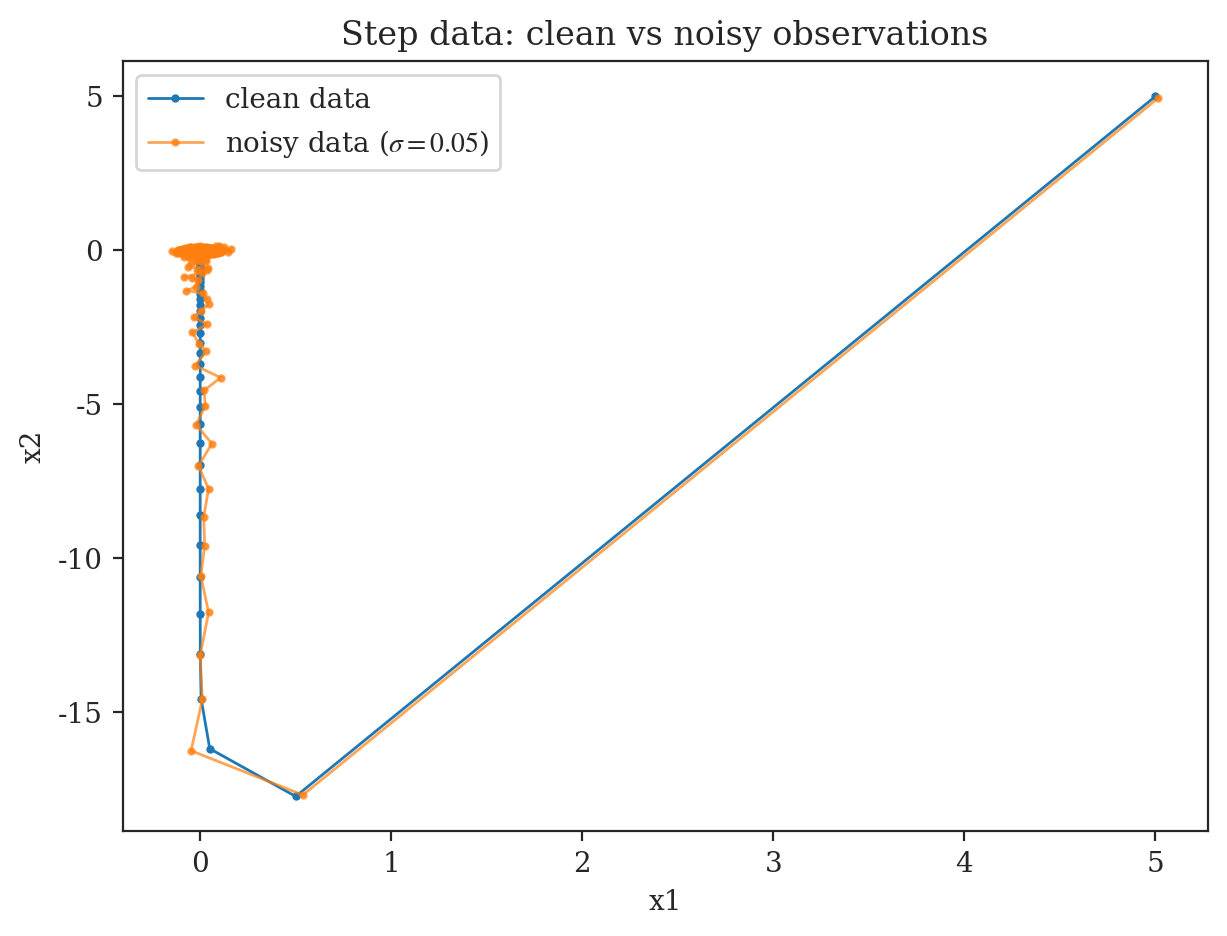

In [31]:
plt.figure(figsize=(7, 5), dpi=200)
plt.plot(data_clean[:, 0], data_clean[:, 1], marker='o', markersize=2, linewidth=1, label='clean data')
plt.plot(data_noisy[:, 0], data_noisy[:, 1], marker='o', markersize=2, linewidth=1, alpha=0.7, label=f'noisy data ($\sigma={noise_std}$)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title('Step data: clean vs noisy observations')
plt.show()


### 选择观测函数库

为了从数据中拟合近似的 $K$，需要先把原始状态映射到一个特征空间中。这里仍然使用与解析例子一致的观测函数结构，这样更方便和第二部分的结果做比较。


In [32]:
# 候选的观测函数
ide = ps.IdentityLibrary()
fourier = ps.FourierLibrary(n_frequencies=1)
ode_lib = ps.PolynomialLibrary(degree=2,include_bias=False)
library_functions = [
    lambda x: x,
    lambda x, y: x * x,
]
custom_library = ps.CustomLibrary(library_functions=library_functions)

# 选定观测函数
library = custom_library

# 进行lift
library.fit(x_data)
x_data_lift = library.transform(x_data)
names = library.get_feature_names()

# 单时间序列
# print(x_data.shape)
# print(x_data_lift.shape)
# 多时间序列
print(x_data_lift[0].shape)
# 检查观测函数变量名
print(names)

(3,)
['f0(x0)', 'f0(x1)', 'f1(x0,x1)']


### 从数据中拟合近似的 $K$

这一单元使用 SINDy 在 lifted 空间中拟合离散时间模型。拟合得到的系数矩阵可以视为一个数据驱动得到的 Koopman 矩阵近似。


In [33]:
# 离散的迭代方程 or 连续的微分方程
#discrete_time=False
discrete_time=True

# 候选拟合器
sr3_optimizer = ps.SR3(reg_weight_lam=0.01, regularizer="l2")
lasso_optimizer = Lasso(alpha=0.00001, max_iter=2000, fit_intercept=False)

optimizer = lasso_optimizer

# 进行拟合
model = ps.SINDy(feature_library=ide, optimizer=optimizer, discrete_time=discrete_time)
model.fit(x_data_lift, t=dt, feature_names=names)
model.print()

(f0(x0))[k+1] = 0.076 f0(x0)[k] + 0.005 f1(x0,x1)[k]
(f0(x1))[k+1] = 0.900 f0(x1)[k] + -0.890 f1(x0,x1)[k]
(f1(x0,x1))[k+1] = 0.010 f1(x0,x1)[k]


In [34]:
# 计算score
model.score(x_data_lift, t=dt)

0.9998796846289296

### 对拟合得到的 $K$ 做 SVD 与粗粒化

从这里开始，流程与第二部分保持一致：先取出拟合矩阵，再进行 SVD，观察奇异值谱，选择截断秩，计算贡献度量，并恢复粗粒化变量和宏观动力学。


In [35]:
cmap = plt.cm.Blues

(3, 3)


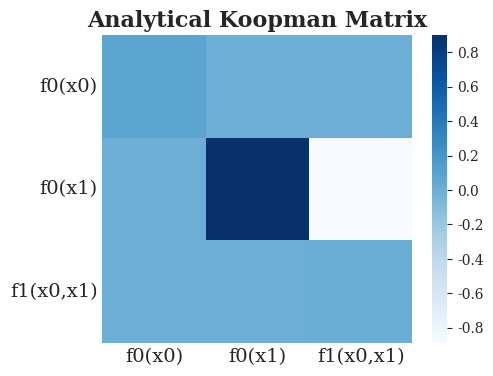

In [36]:
# 提取和处理系数矩阵
A = model.coefficients()
print(A.shape)
if discrete_time==False:
    A = scipy.linalg.expm(A)

# 只设置参数，不自动显示全部
plt.figure(figsize=(5, 4)) # 把画布搞大一点
plt.tick_params(axis='both', which='both', length=0, labelsize=14)
_ = sns.heatmap(A, xticklabels=names, yticklabels=names,cmap=cmap)
plt.title('Analytical Koopman Matrix', fontsize=16, fontweight='bold')
# 旋转横轴标签，避免重叠
plt.xticks(rotation=0)  # 旋转90度
plt.yticks(rotation=0)   # 纵轴保持水平
plt.show()

In [37]:
A

array([[ 7.60706755e-02, -1.21696401e-04,  4.80565822e-03],
       [-0.00000000e+00,  8.99995628e-01, -8.89991174e-01],
       [ 0.00000000e+00,  0.00000000e+00,  9.99201680e-03]])

In [38]:
np.set_printoptions(precision=2, suppress=True)  # suppress=True 防止科学计数法
print(A)

[[ 0.08 -0.    0.  ]
 [-0.    0.9  -0.89]
 [ 0.    0.    0.01]]


In [39]:
# SVD
U,S,V = np.linalg.svd(A)

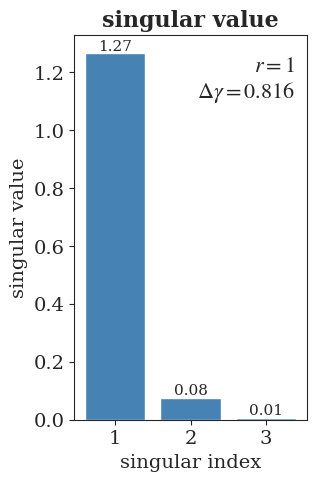

In [40]:
fig, ax = plt.subplots(figsize=(3,5))
bars = ax.bar(range(1,len(S)+1), S, color='steelblue')
for b in bars:
    height = b.get_height()
    plt.text(b.get_x() + b.get_width()/2,height,f'{height:.2f}',
             ha='center', va='bottom', fontsize=11)
ax.set_xlabel('singular index', fontsize=14)
ax.set_ylabel('singular value', fontsize=14)
ax.set_title('singular value', fontsize=16, fontweight='bold')
ax.tick_params(axis='both', labelsize=14)

ax.text(0.95, 0.95,
        r'$r = 1$' + '\n' + r'$\Delta\gamma = 0.816$',
        transform=ax.transAxes,      # 使用轴坐标系
        ha='right', va='top',        # 锚定在右上角
        fontsize=16)

plt.show()

In [41]:
# 选取截断
rank = 1
S_macro = S[:rank]
delt_gamma = sum(S_macro) / rank - sum(S) / len(S)
print(delt_gamma)

0.8160899679309772


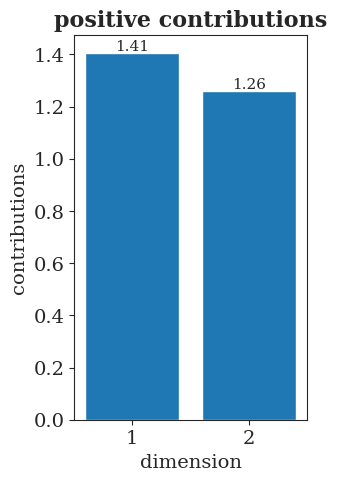

In [42]:
# 多尺度因果力分布
diff = get_positive_contributions(S)
plt.figure(figsize=(3, 5))
bars = plt.bar(range(1,len(diff)+1), diff) 
for b in bars:
    height = b.get_height()
    plt.text(b.get_x() + b.get_width()/2,height,f'{height:.2f}',
             ha='center', va='bottom', fontsize=11)
plt.xlabel('dimension', fontsize=14)
plt.ylabel('contributions', fontsize=14)
plt.title('positive contributions', fontsize=16, fontweight='bold')
plt.tick_params(axis='both', labelsize=14)
#plt.text(0.80, 0.90, 'EC = 0.9978', transform=plt.gca().transAxes, fontsize=20, ha='center')
plt.show()


In [43]:
# 计算EC
print(compute_entropy(diff))

0.9978339885950289


### 粗粒化表达式与宏观演化

这一小节会输出粗粒化变量的显式表达式，并把数据投影到宏观坐标上，从而比较宏观演化与原始 lifted 变量之间的关系。


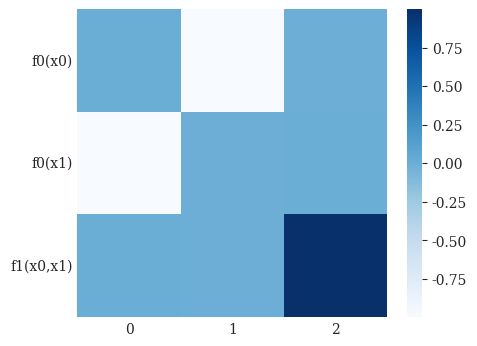

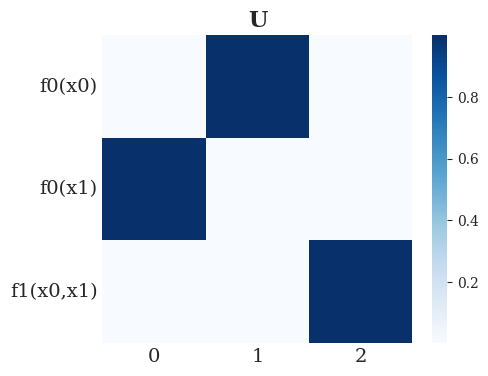

In [44]:
# 绘制奇异向量
U_abs = np.abs(U)

plt.figure(figsize=(5, 4)) 
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(U, yticklabels=names,cmap=cmap)
plt.xticks(rotation=0)  
plt.yticks(rotation=0)   
plt.show()


plt.figure(figsize=(5, 4)) 
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(U_abs, yticklabels=names,cmap=cmap)
plt.xticks(rotation=0)  
plt.yticks(rotation=0)   
plt.title('U', fontsize=16, fontweight='bold')
plt.tick_params(axis='both', labelsize=14)
plt.show() 

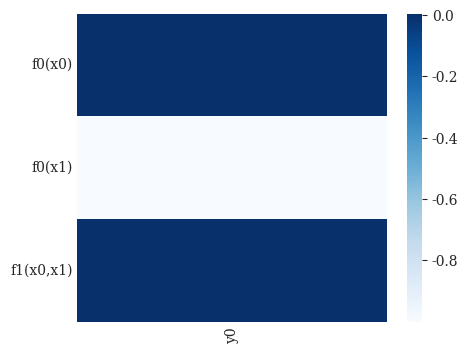

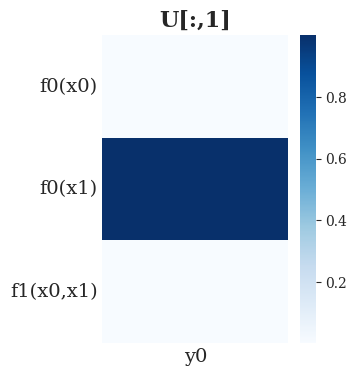

In [45]:
# 粗粒化函数系数
macro_name = [f'y{i}' for i in range(rank)]
coarse_grain_coff = U[:,:rank]

plt.figure(figsize=(5, 4)) 
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(coarse_grain_coff, yticklabels=names, xticklabels=macro_name,cmap=cmap)
plt.xticks(rotation=90)  
plt.yticks(rotation=0)   
plt.show()


plt.figure(figsize=(3, 4)) 
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(np.abs(coarse_grain_coff), yticklabels=names, xticklabels=macro_name,cmap=cmap)
plt.xticks(rotation=0, fontsize=14)  
plt.yticks(rotation=0, fontsize=14)  
plt.title('U[:,1]', fontsize=16, fontweight='bold')
plt.tick_params(axis='both', labelsize=14)
plt.show()

In [46]:
# 输出粗粒化函数表达式
print_equations(coarse_grain_coff, names, macro_name)

y0 = 0.0027 * f0(x0) - 1.0000 * f0(x1) + 0.0056 * f1(x0,x1)
------------------------------


In [47]:
macro_data = x_data_lift @ coarse_grain_coff
macro_dim = macro_data.shape[1]

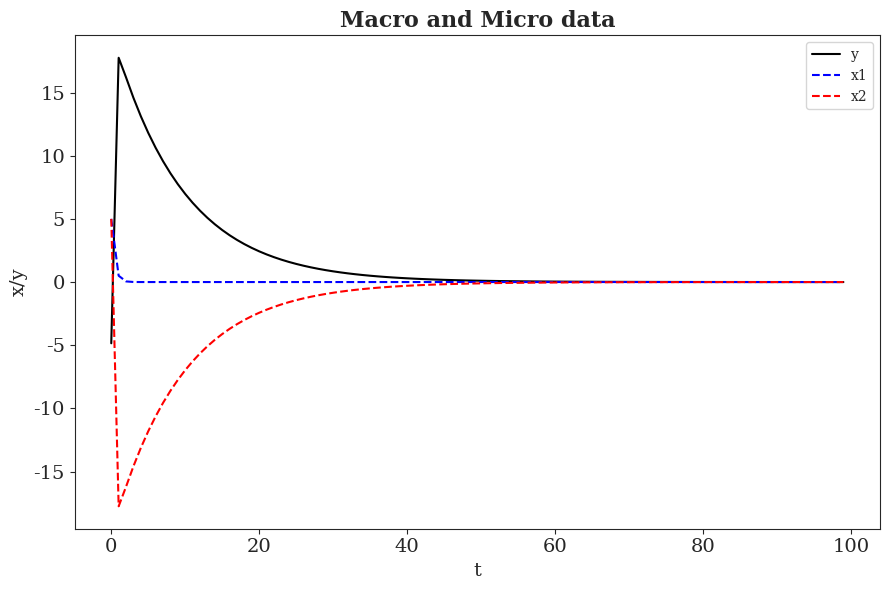

In [48]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(macro_data[:,0][:100], color='k', label='y')   
ax.plot(x_data_lift[:,0][:100], '--',color='blue', label='x1')
ax.plot(x_data_lift[:,1][:100], '--',color='red', label='x2')

ax.set_xlabel('t', fontsize=14)
ax.set_ylabel('x/y', fontsize=14)
ax.set_title('Macro and Micro data', fontsize=16, fontweight='bold')
ax.tick_params(axis='both', labelsize=14)

ax.legend()
fig.tight_layout()
plt.show()

In [49]:
# 给出宏观动力学方程
A_macro = coarse_grain_coff.T @ A @ coarse_grain_coff
macro_name_k = [i+'[k]' for i in macro_name]
macro_name_next = [i+'[k+1]' for i in macro_name]
print_equations(A_macro, macro_name_k, macro_name_next)

y0[k+1] = 0.9049 * y0[k]
------------------------------


## 4. 奇异值与特征值的对比

最后一部分使用另一个矩阵例子，对比奇异值分解与特征值分解。

核心想说明的是：
- 奇异值更适合衡量不同方向上的放大强度，以及低秩结构是否明显。
- 特征值更适合描述模态的增长、衰减和稳定性。
- 在粗粒化和秩截断问题中，奇异值通常是更直接的工具。


In [50]:
def step2(x, y):
    """
    根据给定的方程计算下一步状态:
    x_{k+1} = 0.8 * x_k + 10 * y_k^2
    y_{k+1} = 0.8 * y_k
    """
    x_next = 0.8 * x + 10 * (y ** 2)
    y_next = 0.8 * y
    return x_next, y_next

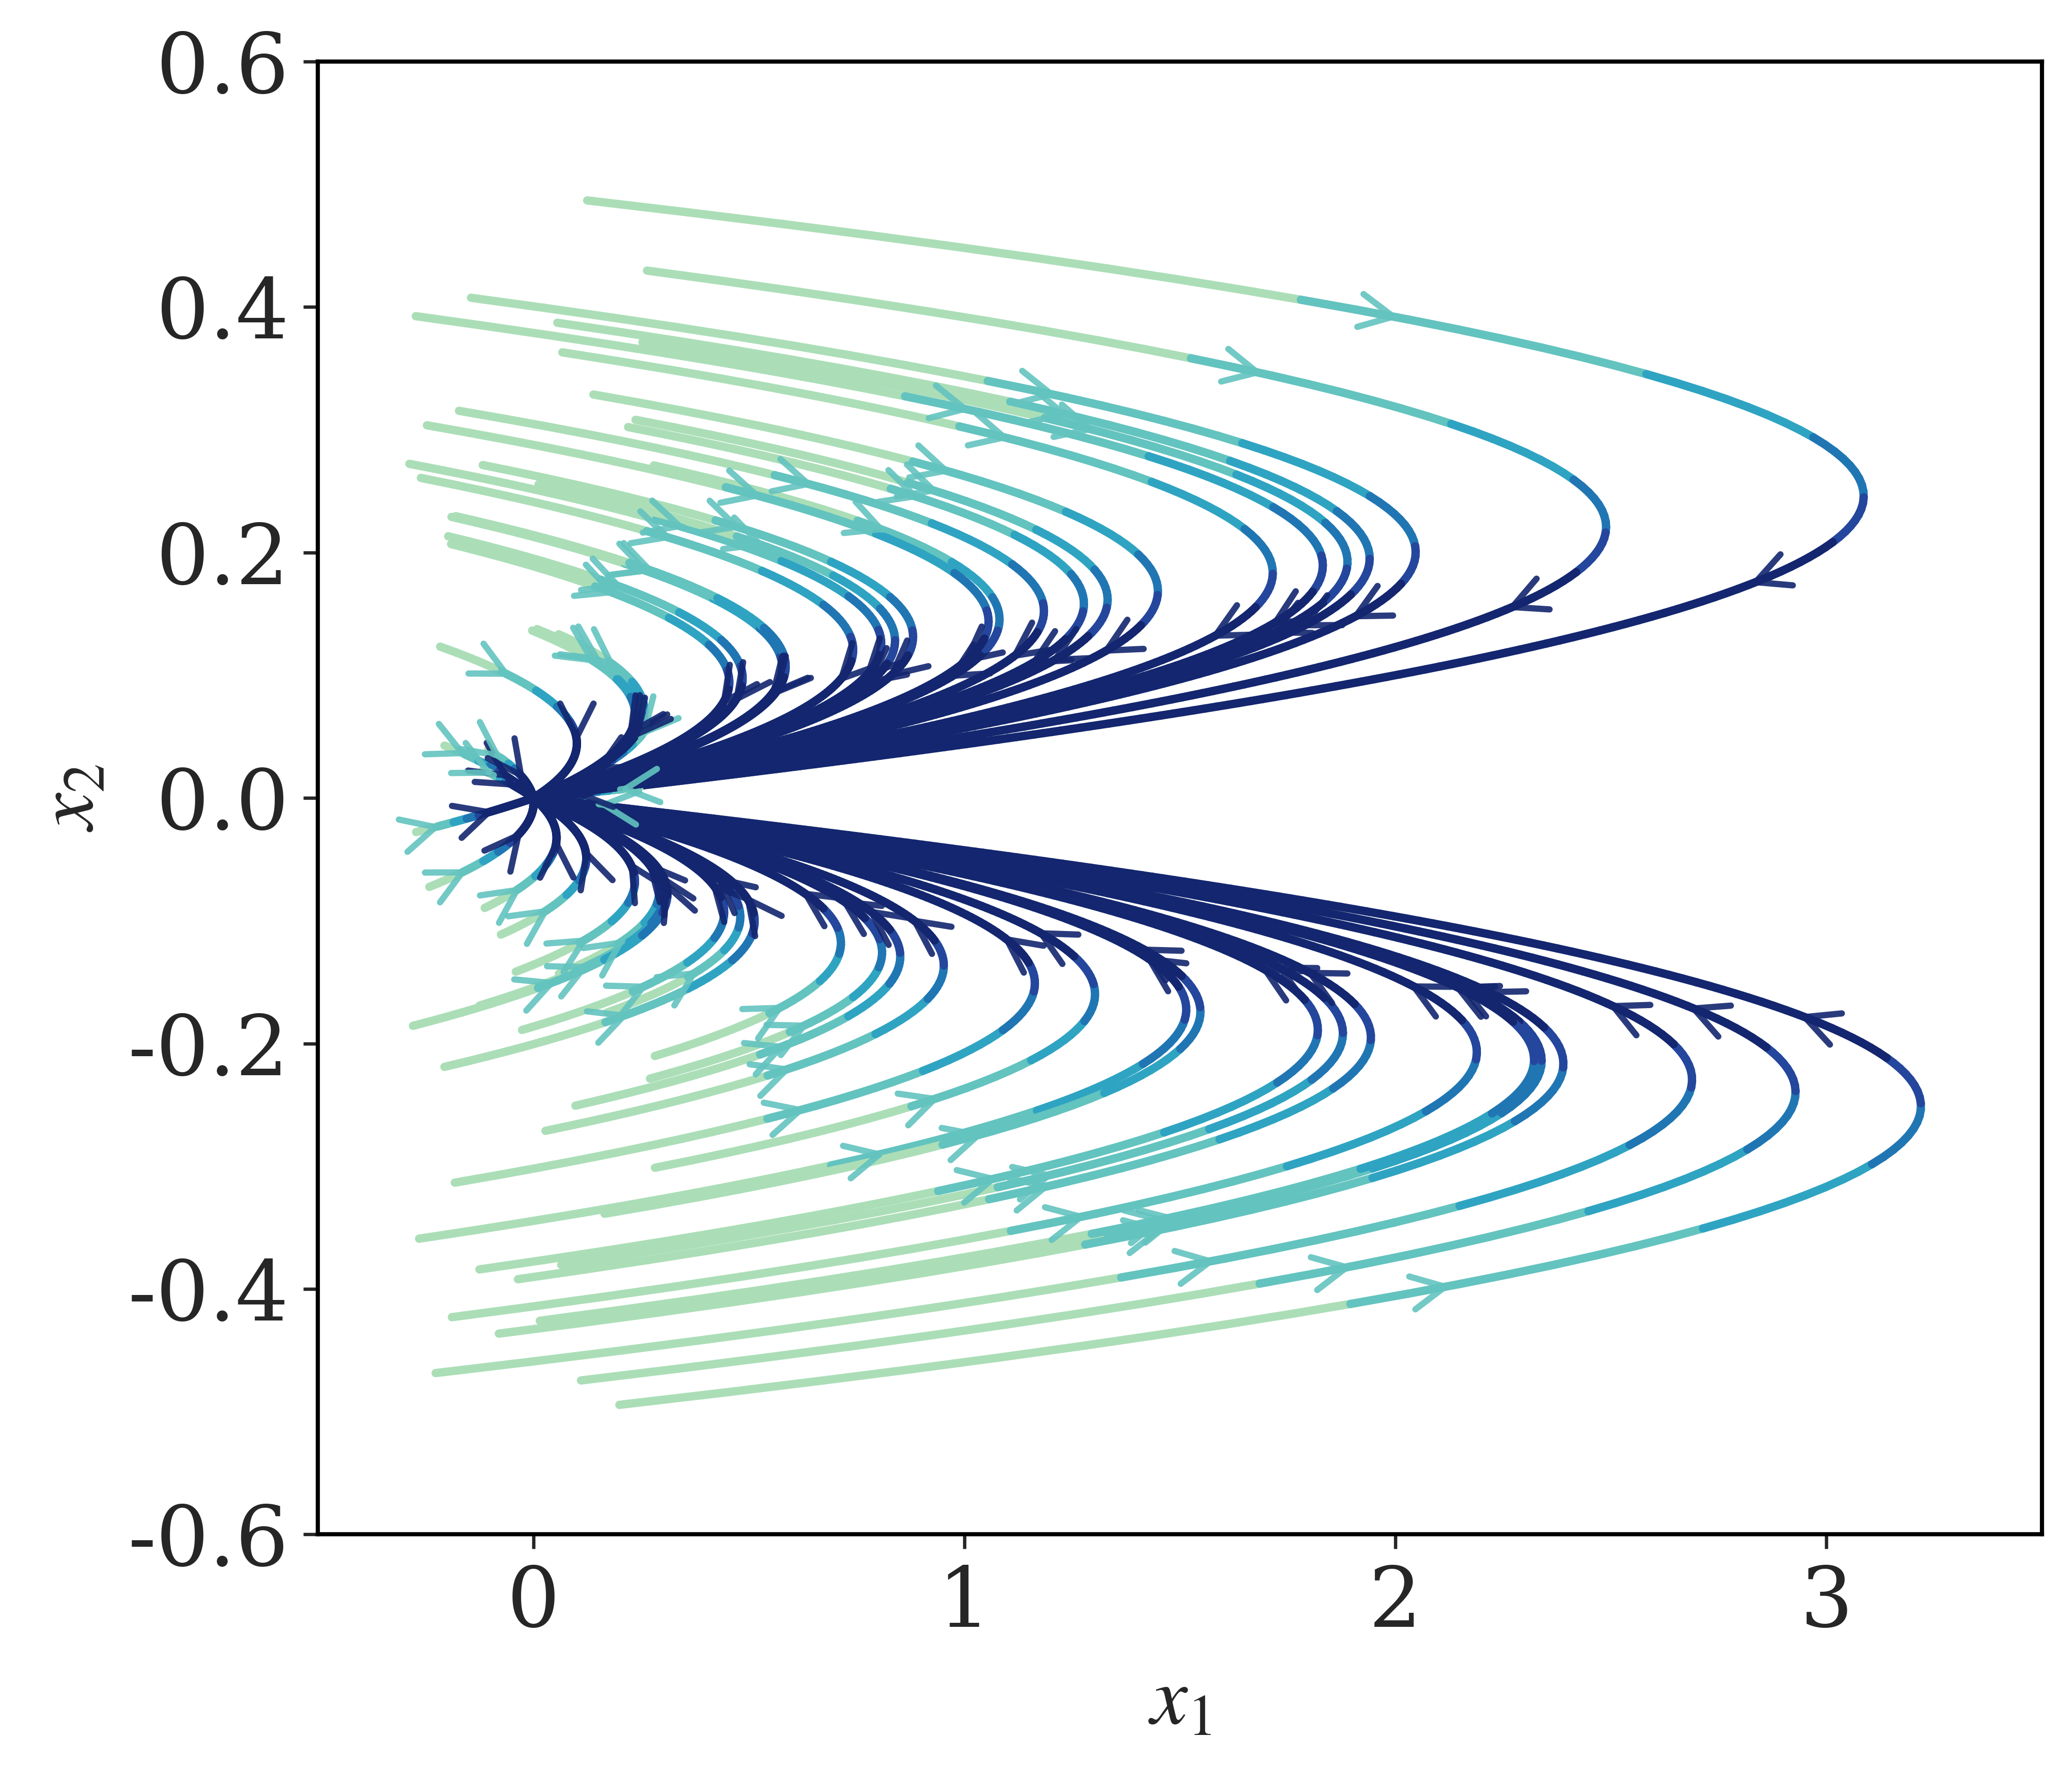

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap
from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path

# --- 参数设置 ---
lam, mu = 0.1, 0.9
iterations = 35
num_samples = 60
epsilon = 0.1     # 微步缩放因子
total_steps = iterations * 10 
np.random.seed(42)
x1_init = np.random.uniform(-0.3, 0.3, num_samples)
x2_init = np.random.uniform(-0.5, 0.5, num_samples)
initial_points = np.vstack([x1_init, x2_init]).T

plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(7, 6), dpi=600)

full_cmap = plt.cm.YlGnBu
colors = full_cmap(np.linspace(0.3, 0.95, 6))
custom_cmap = ListedColormap(colors)

for x0, y0 in initial_points:
    xs, ys = [x0], [y0]
    curr_x, curr_y = x0, y0
    
    for _ in range(total_steps):
        next_x, next_y = step2(curr_x, curr_y)
        dx = next_x - curr_x
        dy = next_y - curr_y
        
        curr_x = curr_x + epsilon * dx
        curr_y = curr_y + epsilon * dy
        
        xs.append(curr_x)
        ys.append(curr_y)

    # A. 绘制渐变曲线
    points = np.array([xs, ys]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # 颜色索引：前 50 小步渐变，后续固定
    color_indices = np.arange(len(segments))
    color_indices[50:] = 50 

    lc = LineCollection(segments, cmap=custom_cmap)
    lc.set_array(color_indices)
    lc.set_linewidth(2)
    lc.set_capstyle('round')
    lc.set_alpha(1.0)
    ax.add_collection(lc)

    # B. 添加简约箭头 (在第 5 步和第 15 步)
    for arrow_idx in [10, 50]:
        if arrow_idx < len(xs) - 1:
            p1 = np.array([xs[arrow_idx], ys[arrow_idx]])
            p2 = np.array([xs[arrow_idx + 1], ys[arrow_idx + 1]])
            
            # 计算当前步对应的颜色，保持视觉统一
            c_val = arrow_idx if arrow_idx < 50 else 50
            arrow_color = custom_cmap(c_val / 50.0)
            
            arrow = FancyArrowPatch(
                p1, p2,
                arrowstyle='->',
                mutation_scale=20,  # 箭头大小
                color=arrow_color,
                linewidth=1.5,
                alpha=0.9,
                zorder=4
            )
            ax.add_patch(arrow)

    # C. 绘制起点
#     ax.scatter(x0, y0, s=5, facecolors='none',
#                edgecolors=(0, 0, 0, 0.2),
#                linewidth=1, zorder=5)

ax.set_xlabel('$x_1$', fontsize=20, fontweight='bold')
ax.set_ylabel('$x_2$', fontsize=20, fontweight='bold')
ax.tick_params(axis='both', labelsize=20)
ax.set_xlim([-0.5, 3.5])
ax.set_ylim([-0.6, 0.6])
# ax.set_aspect('equal') # 保持比例，防止箭头畸变

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)

ax.grid(False)
plt.tight_layout()
plt.show()


In [52]:
A = np.array([
    [0.8, 0.0, 10.0],
    [0.0, 0.8, 0.0],
    [0.0, 0.0, 0.64]
])

In [53]:
cmap = plt.cm.Blues

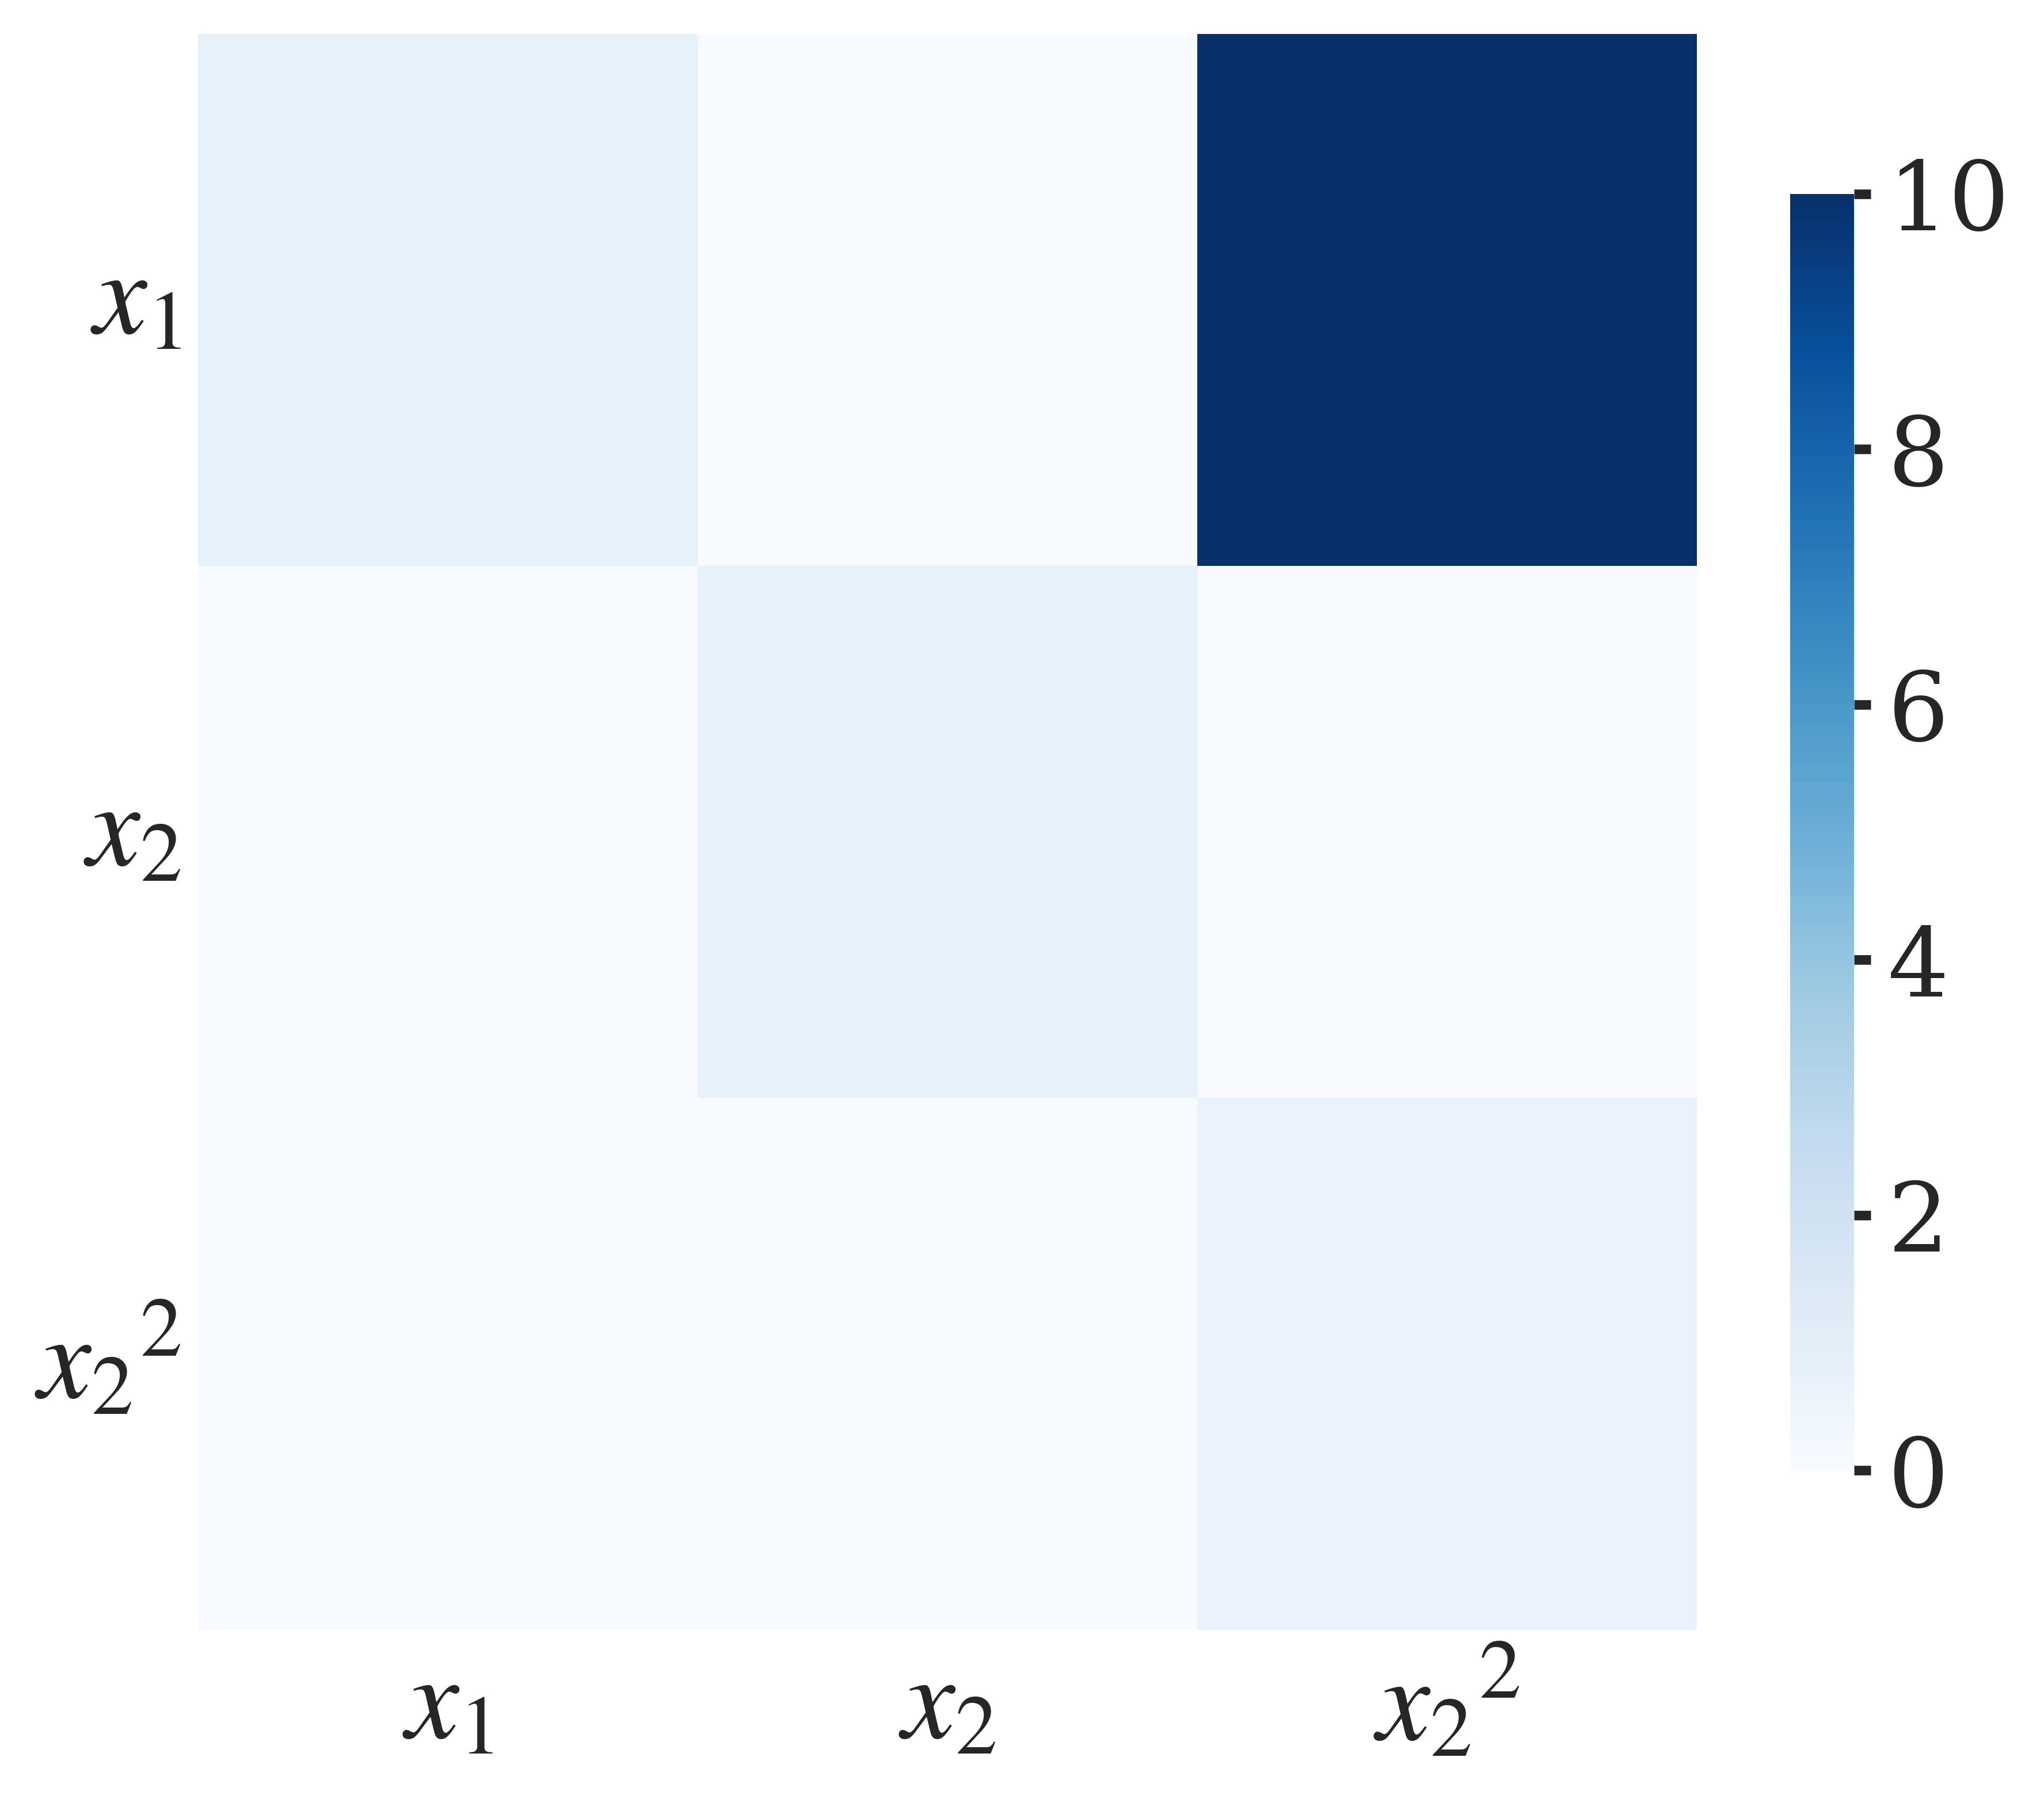

In [54]:
# 只设置参数，不自动显示全部
plt.figure(figsize=(7, 6),dpi=600) # 把画布搞大一点
plt.tick_params(axis='both', which='both', length=0, labelsize=25)
names1=['$x_1$','$x_2$','${x_2}^2$']
heatmap = sns.heatmap(A, xticklabels=names1, yticklabels=names1,cmap=cmap,cbar_kws={'shrink': 0.8})
# plt.title('Analytical Koopman Matrix', fontsize=16, fontweight='bold')
# 旋转横轴标签，避免重叠
plt.xticks(fontsize=25,rotation=0, fontweight='bold')  # 旋转90度
plt.yticks(fontsize=25,rotation=0, fontweight='bold')   # 纵轴保持水平
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=20, width=2) 
plt.show()

In [55]:
# SVD
U,S,V = np.linalg.svd(A)

In [56]:
# Eigenvalue Decomposition
eig_vals, eig_vecs = np.linalg.eig(A)
# Sort eigenvalues by magnitude (descending) for better visualization
idx = np.argsort(np.abs(eig_vals))[::-1]
eig_vals_sorted = eig_vals[idx]
eig_vecs_sorted = eig_vecs[:, idx]

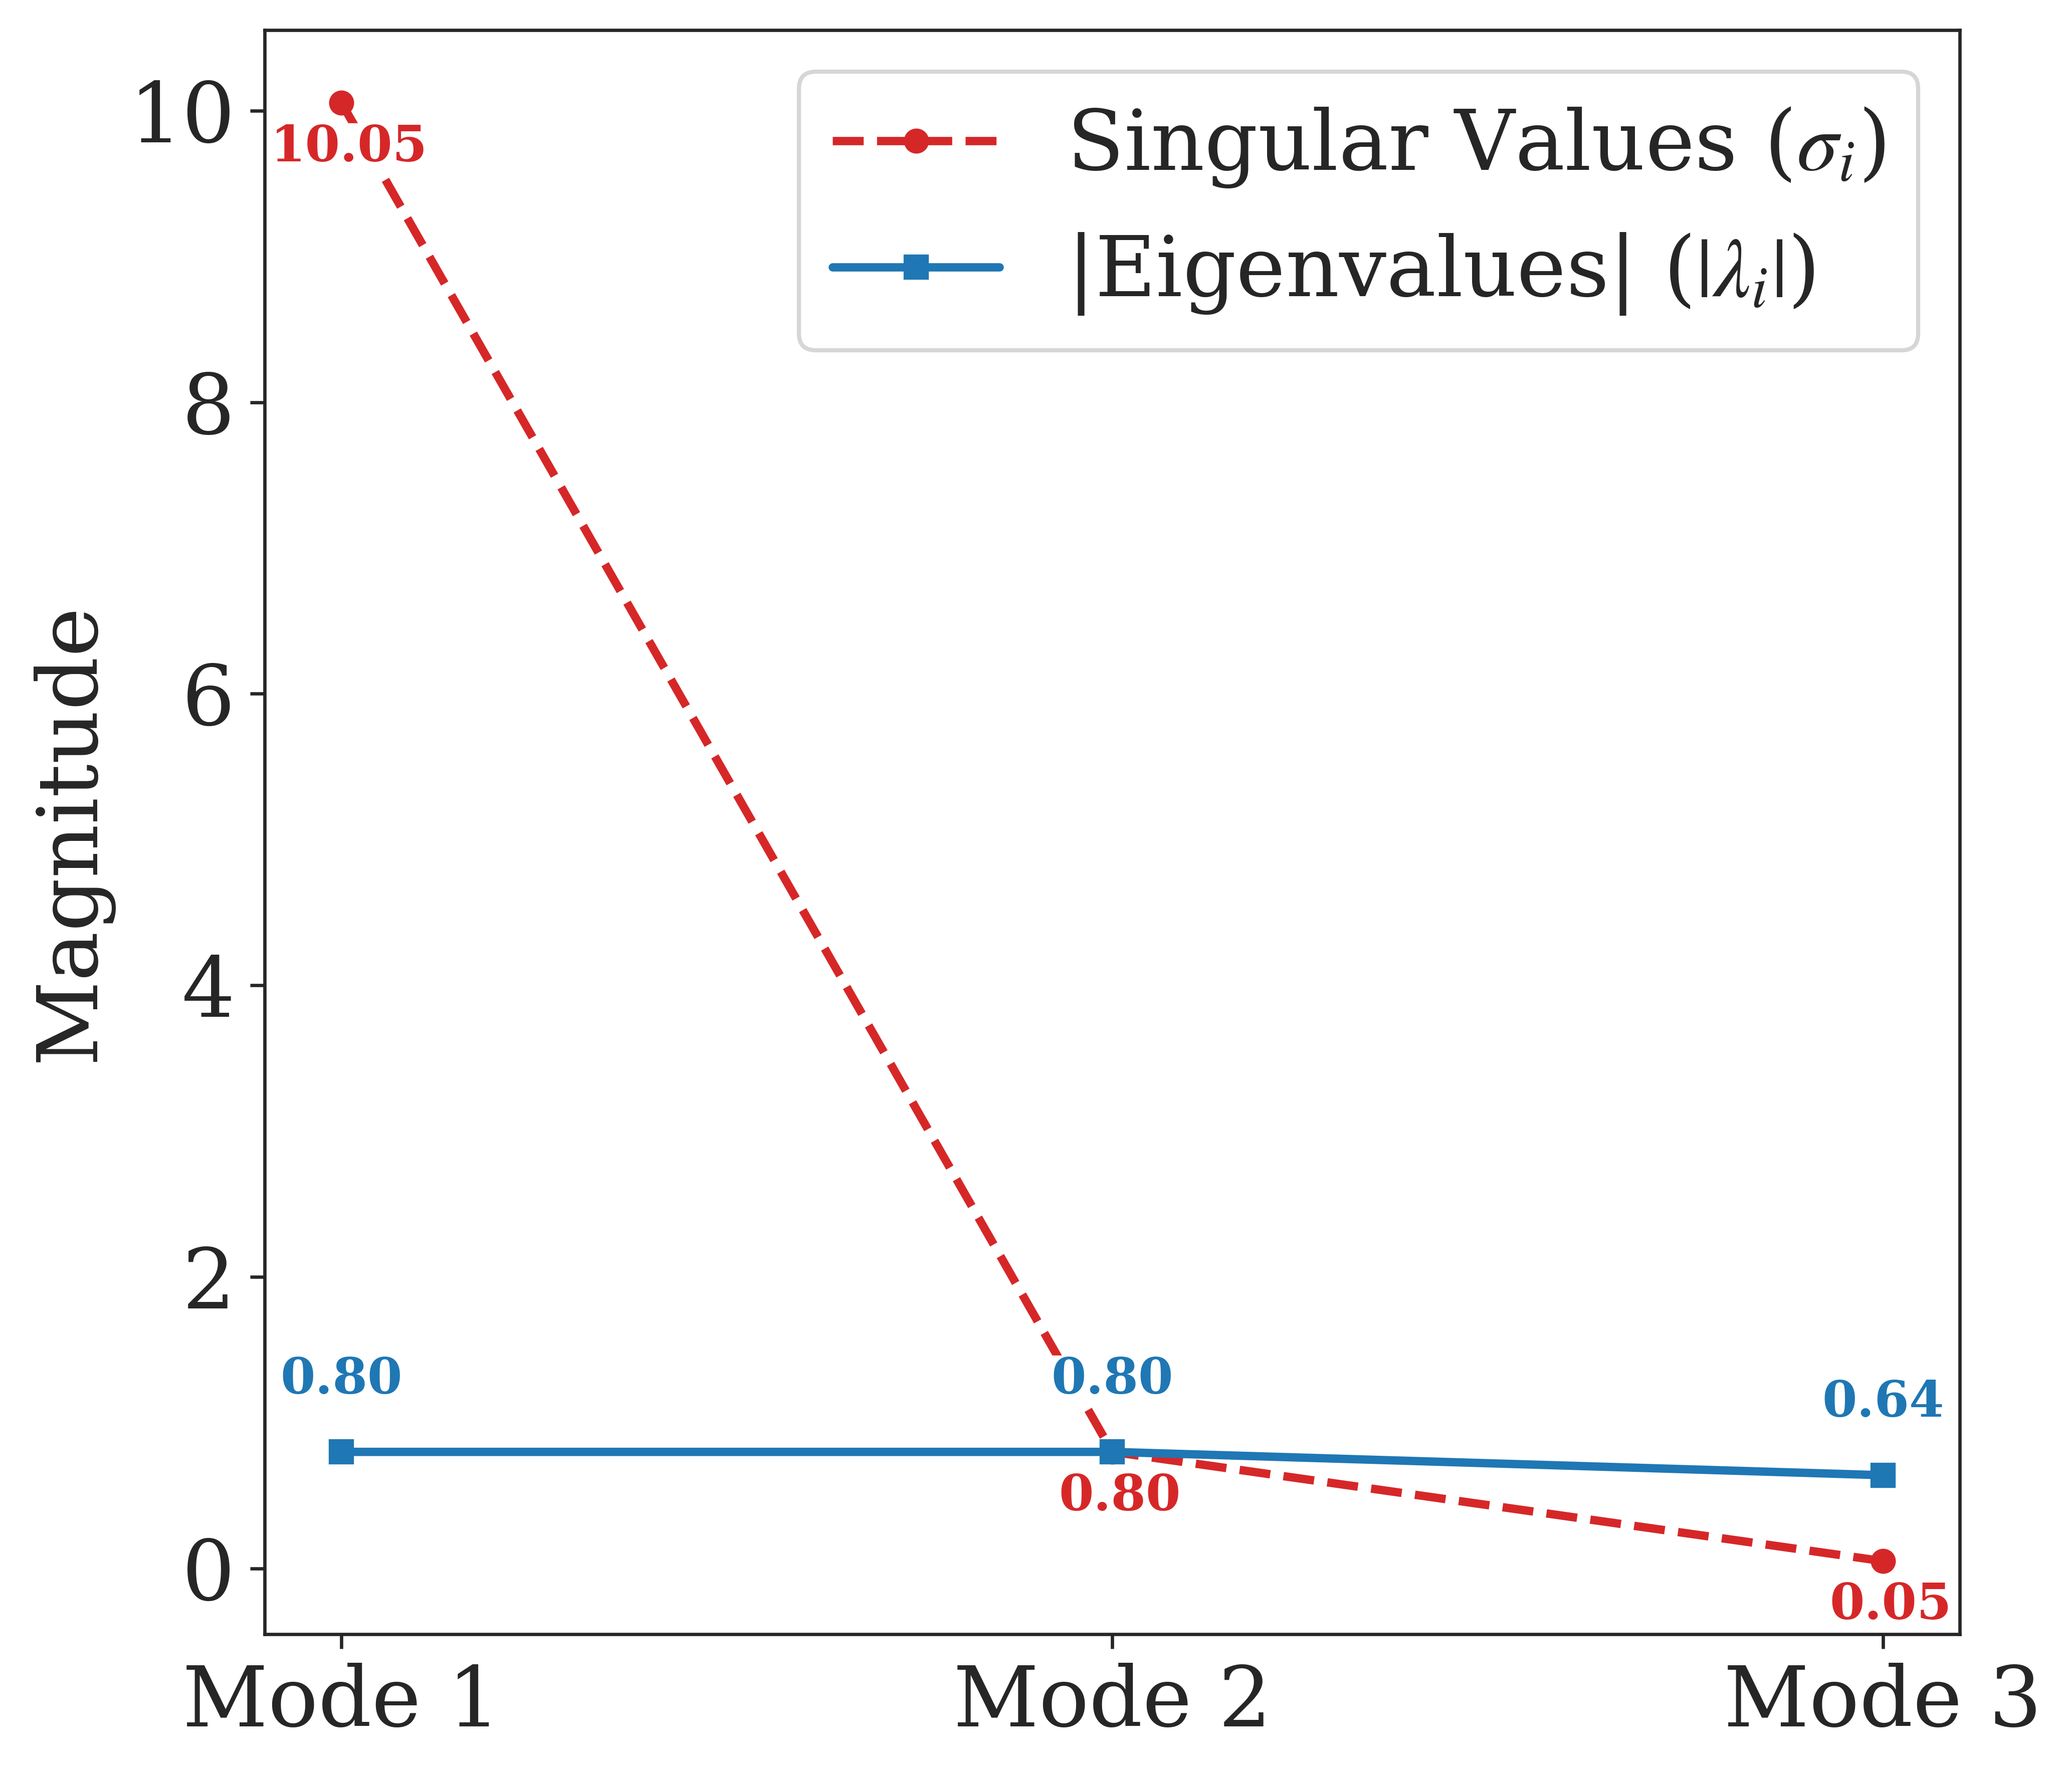

In [57]:
fig, ax = plt.subplots(figsize=(7, 6), dpi=600)
ax.plot(range(1, 4), S, 'o--', color='#d62728', linewidth=2, markersize=5, label='Singular Values ($\sigma_i$)')
ax.plot(range(1, 4), np.abs(eig_vals_sorted), 's-', color='#1f77b4', linewidth=2, markersize=5, label='|Eigenvalues| ($|\lambda_i|$)')

for i, val in enumerate(S):
    ax.text(i+1.01, val - 0.4, f"{val:.2f}", ha='center', color='#d62728', fontsize = 12, fontweight='bold',bbox=dict(boxstyle='round,pad=0', facecolor='white', alpha=1, edgecolor='none'))
for i, val in enumerate(np.abs(eig_vals_sorted)):
    ax.text(i+1, val + 0.4, f"{val:.2f}", ha='center', color='#1f77b4', fontsize = 12, fontweight='bold',bbox=dict(boxstyle='round,pad=0', facecolor='white', alpha=1, edgecolor='none'))

#ax.set_title('Spectra Comparison: Singular Values vs. Eigenvalues', fontsize=16,fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Mode 1', 'Mode 2', 'Mode 3'], fontsize=20)
ax.set_ylabel('Magnitude', fontsize=20)
ax.tick_params(axis='both', labelsize=20)
ax.legend(fontsize=20)
ax.grid(False)
plt.tight_layout()
plt.show()

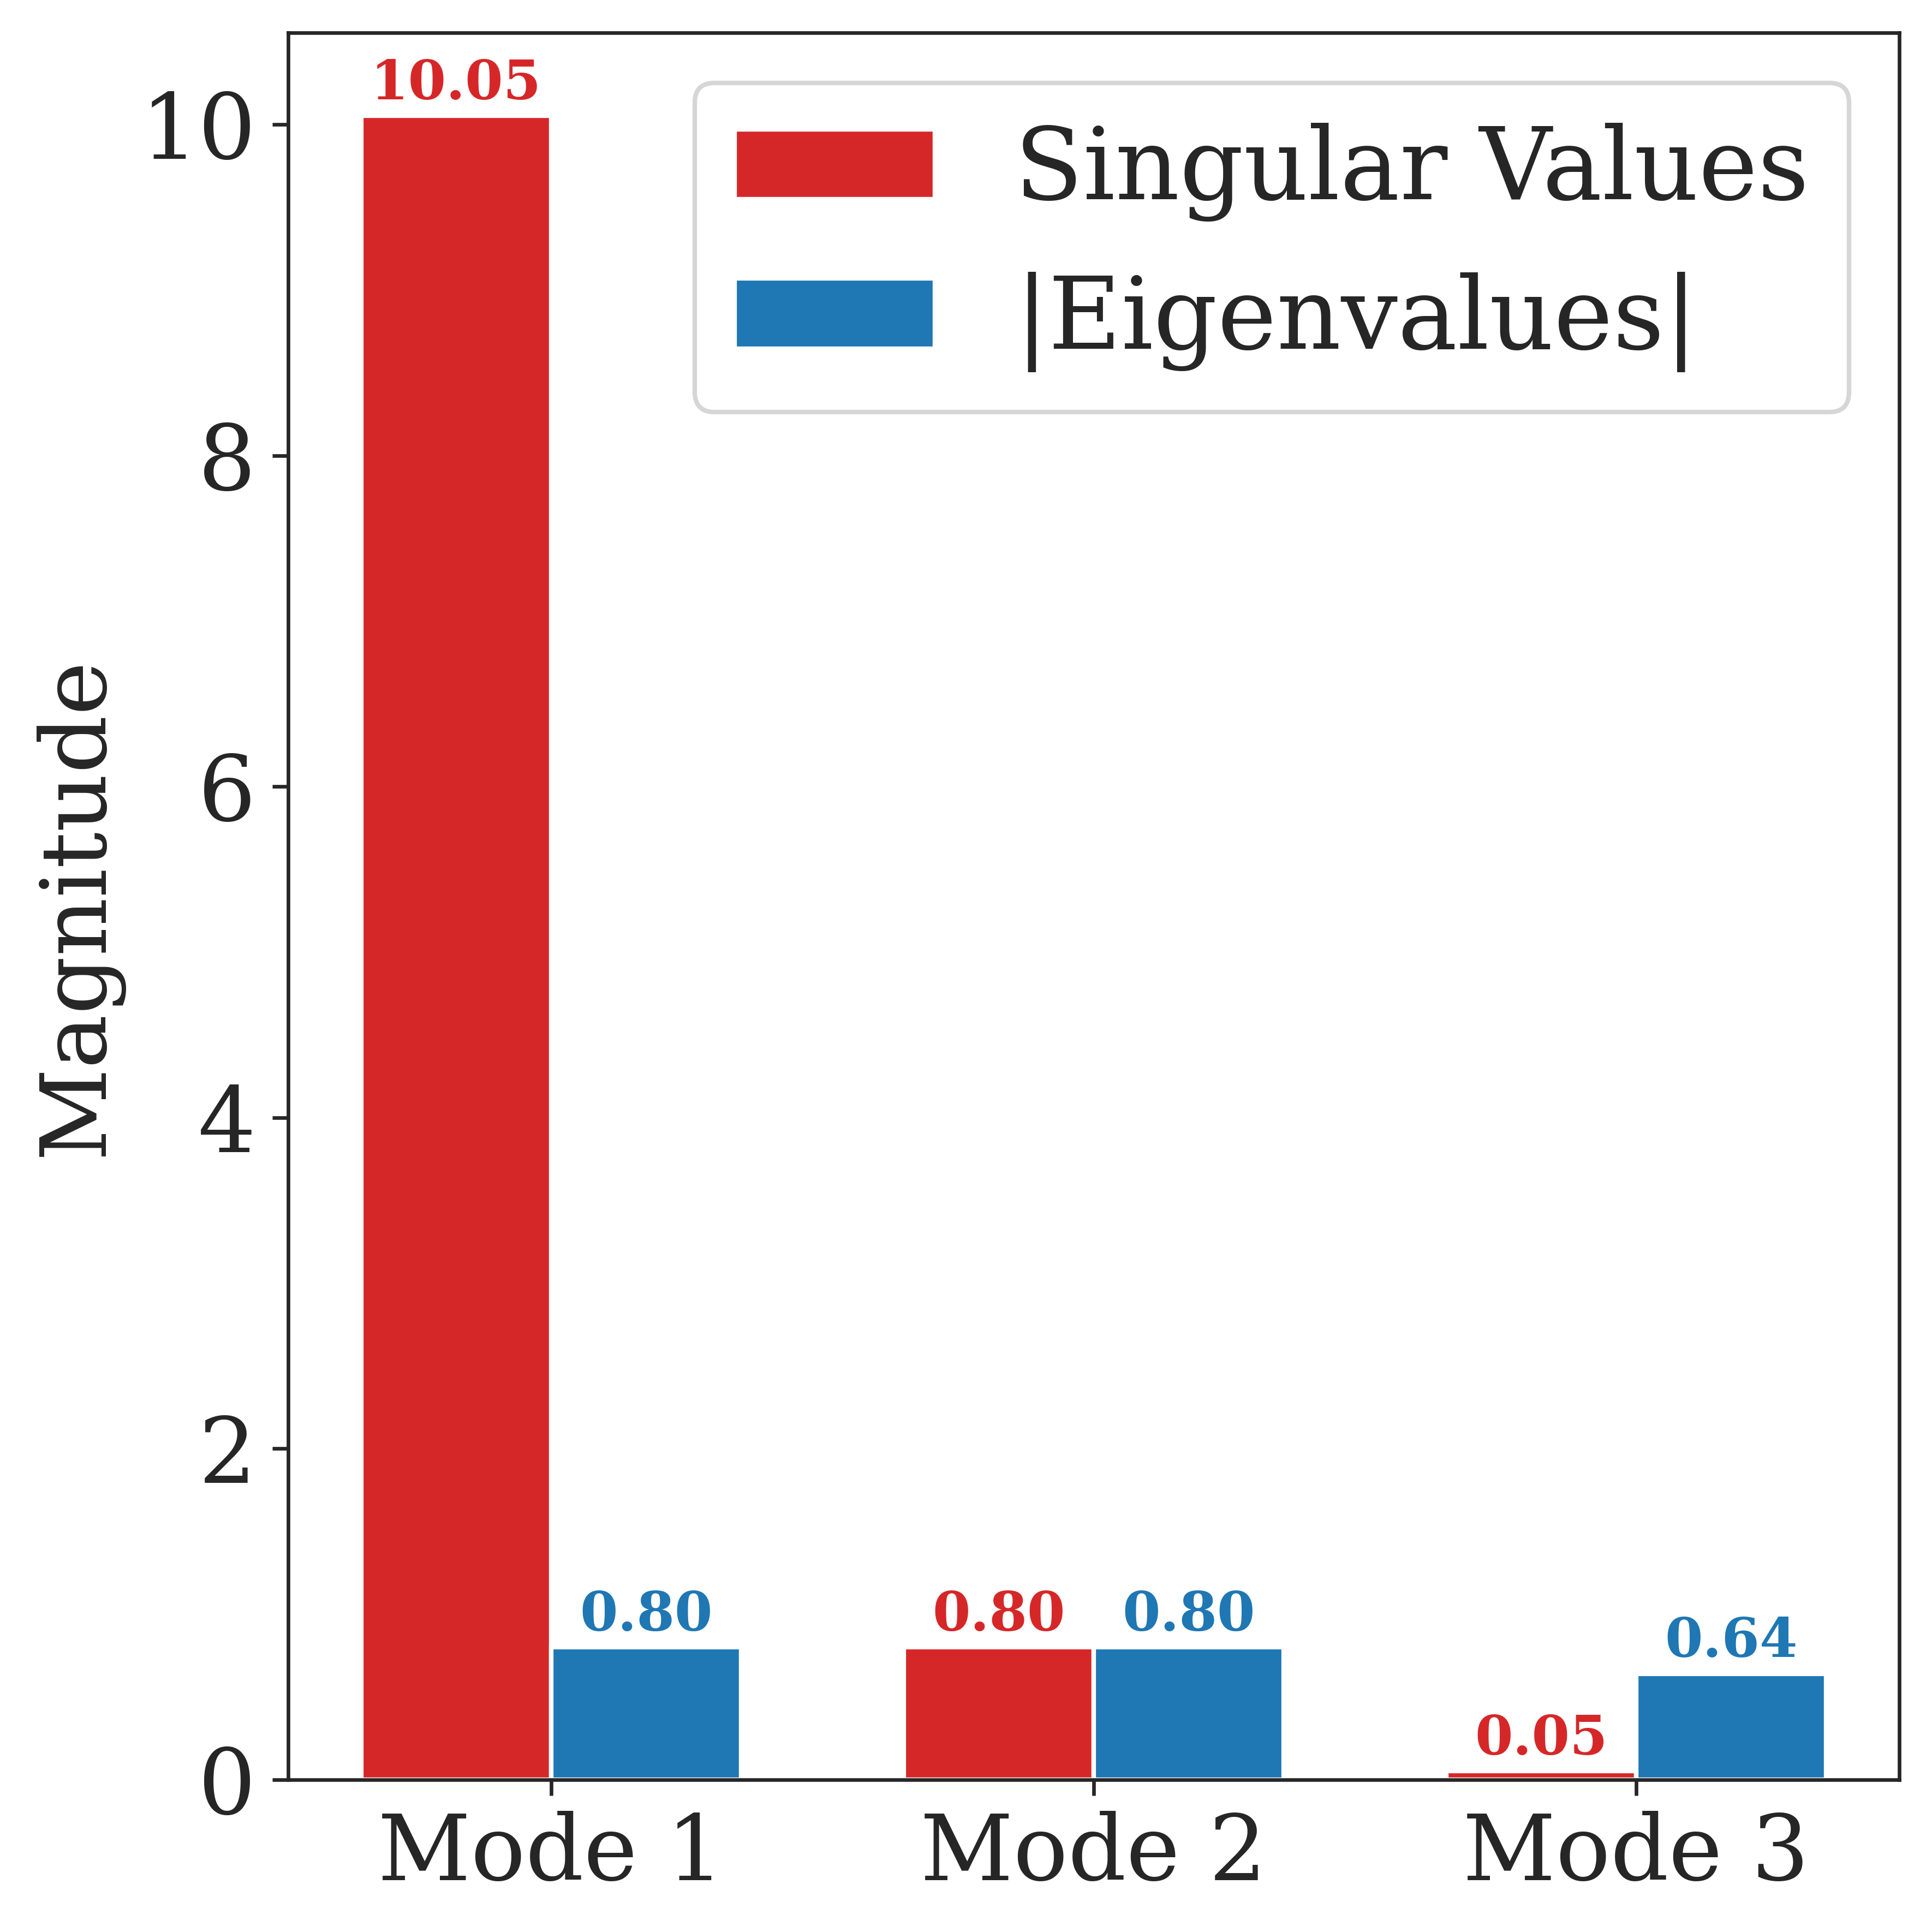

In [58]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=600)

bar_width = 0.35
x = np.arange(1, 4)

# 绘制柱状图
bars1 = ax.bar(x - bar_width/2, S, width=bar_width, color='#d62728', label='Singular Values')
bars2 = ax.bar(x + bar_width/2, np.abs(eig_vals_sorted), width=bar_width, color='#1f77b4', label='|Eigenvalues|')

# 添加数值文本
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    height1 = bar1.get_height()
    height2 = bar2.get_height()
    ax.text(bar1.get_x() + bar1.get_width()/2, height1 + 0.1, f"{height1:.2f}", 
            ha='center', color='#d62728', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0', facecolor='white', alpha=1, edgecolor='none'))
    ax.text(bar2.get_x() + bar2.get_width()/2, height2 + 0.1, f"{height2:.2f}", 
            ha='center', color='#1f77b4', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0', facecolor='white', alpha=1, edgecolor='none'))

# 设置坐标轴
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Mode 1', 'Mode 2', 'Mode 3'], fontsize=20)
ax.set_ylabel('Magnitude', fontsize=20)
ax.tick_params(axis='both', labelsize=20)
ax.legend(fontsize=22, prop={'size': 22})
ax.grid(False)
plt.tight_layout()
plt.show()

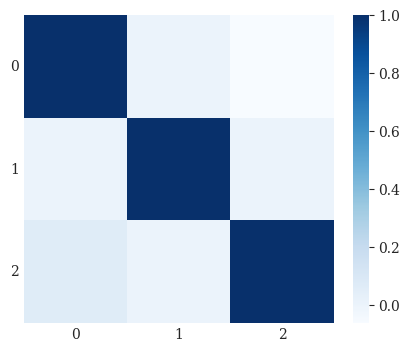

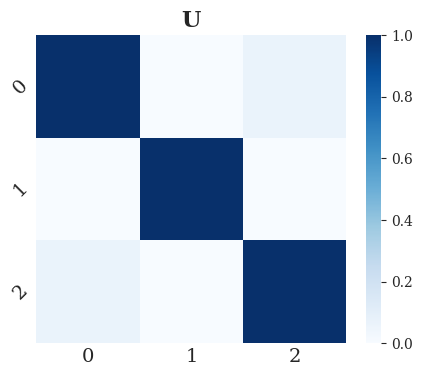

In [59]:
# 绘制奇异向量
U_abs = np.abs(U)

plt.figure(figsize=(5, 4)) 
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(U, cmap=cmap)
plt.xticks(rotation=0)  
plt.yticks(rotation=0)   
plt.show()


plt.figure(figsize=(5, 4)) 
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(U_abs,cmap=cmap)
plt.xticks(rotation=0)  
plt.yticks(rotation=45) 
plt.title('U', fontsize=16, fontweight='bold')
plt.tick_params(axis='both', labelsize=14)
plt.show() 


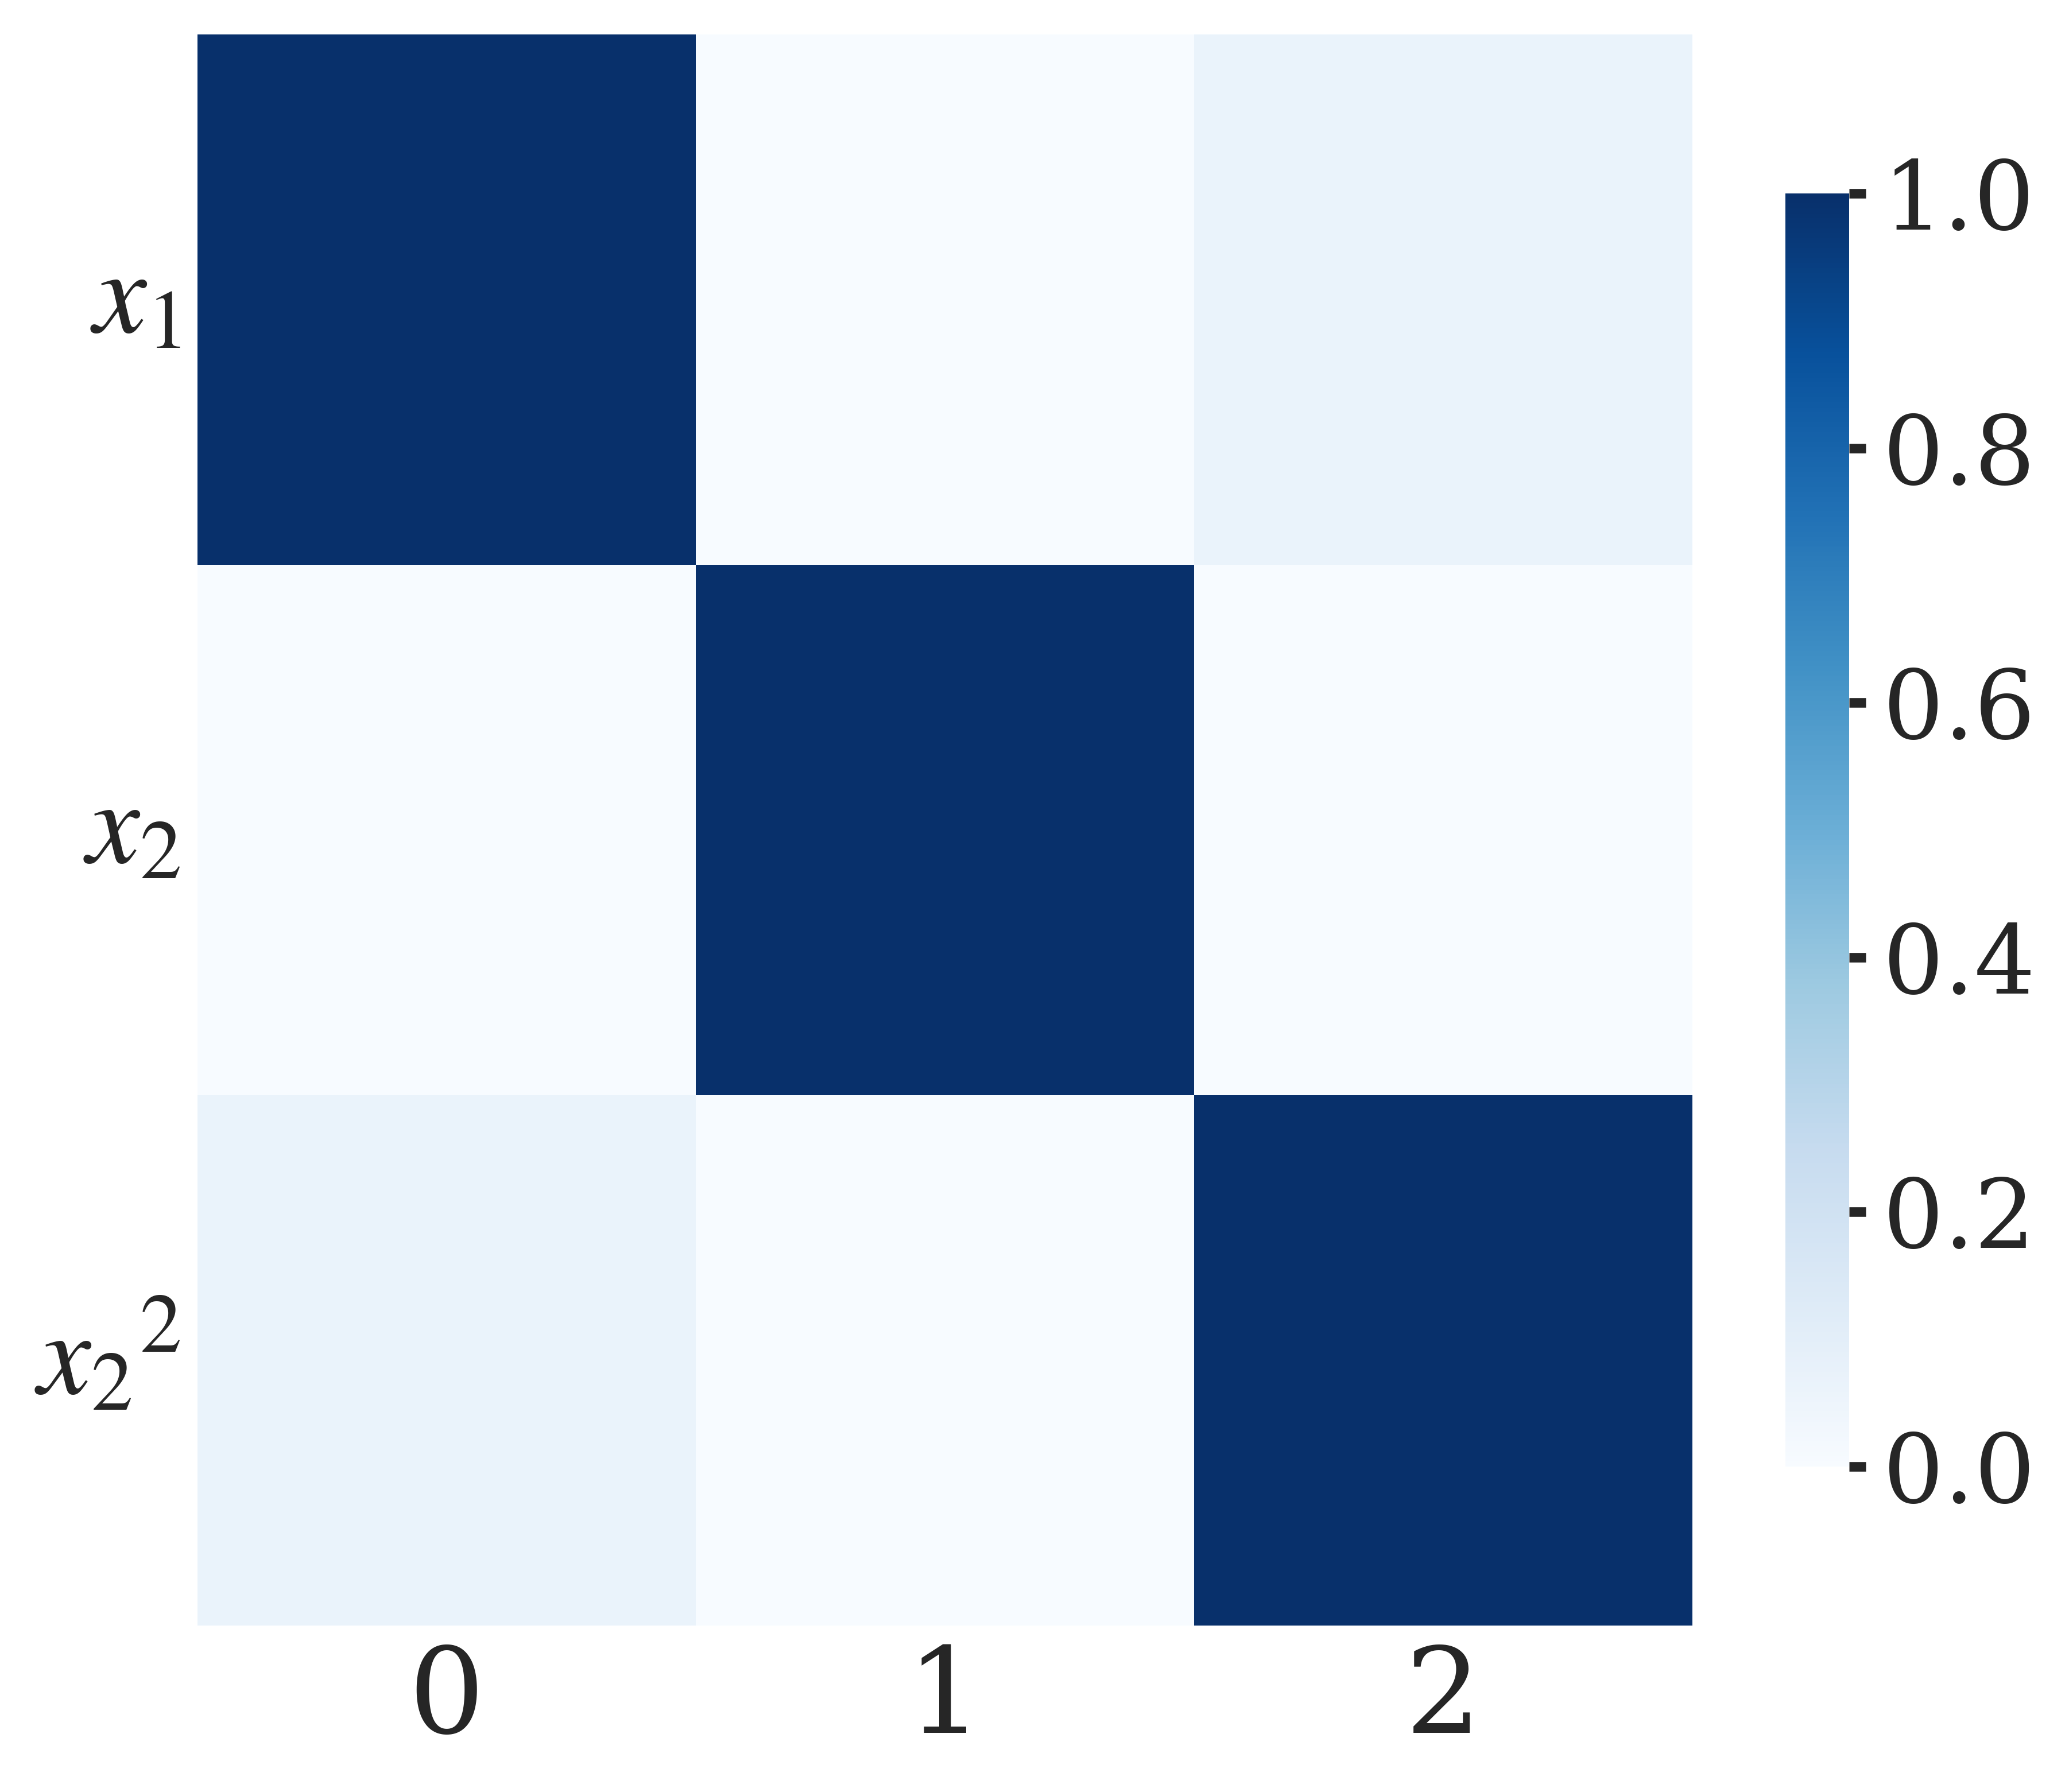

In [60]:
plt.figure(figsize=(7, 6),dpi=600) 
plt.tick_params(axis='both', which='both', length=0, labelsize=25)
heatmap = sns.heatmap(U_abs, yticklabels=names1,cmap=cmap,cbar_kws={'shrink': 0.8})
plt.xticks(fontsize=25,rotation=0)  
plt.yticks(fontsize=25,rotation=0)   
#plt.title('U', fontsize=16, fontweight='bold')
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=20, width=2) 
plt.show() 